In [17]:

# DATA LOADING + FEATURE ENGINEERING + PHYSICS CHANNELS

BATCH_ID            = '2024_H2'
PREVIOUS_MODELS_DIR = '/kaggle/input/datasets/zeeshan12233/run-2024h01'

DATA_ROOT  = '/kaggle/input/datasets/muhammadabubakar26/fyp-dataset-merged2'
OUTPUT_DIR = '/kaggle/working/'
IS_FIRST_RUN = (PREVIOUS_MODELS_DIR is None)

REPLAY_FRAC         = 0.40
CLIM_WINDOW_HOURS   = 720

HEAT_ANOM_THRESHOLD = +7.0
COLD_ANOM_THRESHOLD = -7.0
HEAVY_RAIN_6H_MM    = 2.0

import os
import pickle
import warnings
import numpy as np
import pandas as pd
import xarray as xr
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings('ignore')

YEAR, HALF = BATCH_ID.split('_')

ALL_BATCHES = [
    ('2015','H1'),('2015','H2'),('2016','H1'),('2016','H2'),
    ('2017','H1'),('2017','H2'),('2018','H1'),('2018','H2'),
    ('2019','H1'),('2019','H2'),('2020','H1'),('2020','H2'),
    ('2021','H1'),('2021','H2'),('2022','H1'),('2022','H2'),
    ('2023','H1'),('2023','H2'),('2024','H1'),('2024','H2'),
]
current_idx = ALL_BATCHES.index((YEAR, HALF))
VAL_YEAR, VAL_HALF = ALL_BATCHES[min(current_idx + 1, len(ALL_BATCHES) - 1)]

PREV_CHECKPOINT = PREV_SCALER = PREV_REPLAY = None
if not IS_FIRST_RUN:
    PREV_YEAR, PREV_HALF = ALL_BATCHES[current_idx - 1]
    PREV_BATCH_ID   = f"{PREV_YEAR}_{PREV_HALF}"
    PREV_CHECKPOINT = f"{PREVIOUS_MODELS_DIR}/model_checkpoint_{PREV_BATCH_ID}.pt"
    PREV_SCALER     = f"{PREVIOUS_MODELS_DIR}/scaler_{PREV_BATCH_ID}.pkl"
    PREV_REPLAY     = f"{PREVIOUS_MODELS_DIR}/replay_{PREV_BATCH_ID}.npz"
    for fpath in [PREV_CHECKPOINT, PREV_SCALER, PREV_REPLAY]:
        assert os.path.exists(fpath), f"Missing required file: {fpath}"
        print(f"Found: {fpath} ({os.path.getsize(fpath)/1e6:.1f} MB)")

print(f"Current batch : {YEAR}_{HALF}")
print(f"Validation    : {VAL_YEAR}_{VAL_HALF}")
print(f"First run     : {IS_FIRST_RUN}")


def _half_folder(half):
    return '1_to_6' if half == 'H1' else '7_to_12'

def _paths_for(year, half):
    folder = _half_folder(half)
    return (f"{DATA_ROOT}/{year}/{folder}/pressure_{year}_{half}.nc",
            f"{DATA_ROOT}/{year}/{folder}/combined.nc")

for fpath in [*_paths_for(YEAR, HALF), *_paths_for(VAL_YEAR, VAL_HALF)]:
    assert os.path.exists(fpath), f"Data file not found: {fpath}"
    print(f"OK: {fpath} ({os.path.getsize(fpath)/1e6:.1f} MB)")


ZONES = [
    {'id': 0, 'name': 'N_Mountains',  'lat': (33.0, 37.0), 'lon': (71.0, 77.0)},
    {'id': 1, 'name': 'KP_U_Punjab',  'lat': (31.0, 33.0), 'lon': (69.0, 75.0)},
    {'id': 2, 'name': 'C_Punjab',     'lat': (27.0, 31.0), 'lon': (69.0, 75.0)},
    {'id': 4, 'name': 'Sindh_Coast',  'lat': (23.0, 27.0), 'lon': (66.0, 72.0)},
    {'id': 3, 'name': 'Balochistan',  'lat': (23.0, 32.0), 'lon': (61.0, 69.0)},
]
N_ZONES = len(ZONES)
.
ZONE_CENTROIDS = np.array([
    [35.0, 74.0],   # 0 N_Mountains
    [32.0, 72.0],   # 1 KP_U_Punjab
    [29.0, 72.0],   # 2 C_Punjab
    [25.0, 69.0],   # 3 Sindh_Coast 
    [27.5, 65.0],   # 4 Balochistan 
], dtype=np.float32)


def build_zone_masks(ds):
    lat_name = 'latitude'  if 'latitude'  in ds.dims else 'lat'
    lon_name = 'longitude' if 'longitude' in ds.dims else 'lon'
    lats = ds[lat_name].values
    lons = ds[lon_name].values

    lat_grid, lon_grid = np.meshgrid(lats, lons, indexing='ij')
    claimed = np.zeros_like(lat_grid, dtype=bool)
    masks = {}

    for zdef in ZONES:
        la_lo, la_hi = zdef['lat']
        lo_lo, lo_hi = zdef['lon']
        in_box = (
            (lat_grid >= la_lo) & (lat_grid <= la_hi) &
            (lon_grid >= lo_lo) & (lon_grid <= lo_hi) &
            ~claimed
        )
        masks[zdef['id']] = in_box
        claimed |= in_box
        print(f"  Zone {zdef['id']} ({zdef['name']:12}): {int(in_box.sum()):4d} cells")
    return masks

LEVELS_HPA = [1000, 850, 500, 200]
G, R_D, CP, P0_PA = 9.80665, 287.05, 1004.0, 100000.0
R_V = 461.5            # gas constant water vapor [J/(kg·K)]
L_V = 2.5e6            # latent heat of vaporization [J/kg]
KAPPA = R_D / CP       # ≈ 0.286, dry adiabatic exponent

N_FEATURES = None
FEATURE_NAMES = None

PHYSICS_CHANNELS_PER_ZONE = [
    't2m_K', 'T850_K', 'T500_K', 'u850', 'v850',
    'omega500', 'PW_kg_m2', 'sp_Pa',
]
N_PHYSICS_PER_ZONE = len(PHYSICS_CHANNELS_PER_ZONE)
N_PHYSICS = N_PHYSICS_PER_ZONE * N_ZONES   # = 40
PHYSICS_CHANNELS = []
for zdef in ZONES:
    for ch in PHYSICS_CHANNELS_PER_ZONE:
        PHYSICS_CHANNELS.append(f"Z{zdef['id']}_{zdef['name']}_{ch}")


def _fill_nans_1d(arr):
    s = pd.Series(arr).ffill().bfill()
    out = s.values.astype(np.float32)
    if np.isnan(out).any():
        out = np.nan_to_num(out, nan=0.0)
    return out


def _open_nc(path):
    ds = xr.open_dataset(path, engine='h5netcdf')
    if 'time' in ds.dims and 'valid_time' in ds.dims:
        new_vars = {}
        for var in ds.data_vars:
            arr = ds[var].values
            collapsed = np.nanmean(arr, axis=0)
            new_dims = [d for d in ds[var].dims if d != 'time']
            new_vars[var] = (new_dims, collapsed)
        coords = {c: ds.coords[c] for c in ds.coords if c != 'time'}
        ds = xr.Dataset(new_vars, coords=coords)
    return ds


def _zonal_mean(da, mask, lat_name, lon_name):
    m = xr.DataArray(mask, dims=[lat_name, lon_name])
    return da.where(m).mean(dim=[lat_name, lon_name], skipna=True)

def _zonal_max(da, mask, lat_name, lon_name):
    m = xr.DataArray(mask, dims=[lat_name, lon_name])
    return da.where(m).max(dim=[lat_name, lon_name], skipna=True)

def _pick(ds, long_name, short_name):
    if long_name in ds.data_vars:  return long_name
    if short_name in ds.data_vars: return short_name
    raise KeyError(f"Neither '{long_name}' nor '{short_name}' in {list(ds.data_vars)}")

def load_and_engineer(year, half, scaler=None, fit_scaler=False):
    global N_FEATURES, FEATURE_NAMES

    p_pressure, p_surface = _paths_for(year, half)
    ds_p = _open_nc(p_pressure)
    ds_s = _open_nc(p_surface)

    lat_name = 'latitude'  if 'latitude'  in ds_s.dims else 'lat'
    lon_name = 'longitude' if 'longitude' in ds_s.dims else 'lon'

    print(f"\nBuilding zone masks for {year}_{half} (surface grid):")
    zone_masks_sfc = build_zone_masks(ds_s)
    print(f"Building zone masks for {year}_{half} (pressure grid):")
    zone_masks_prs = build_zone_masks(ds_p)

    time_name = 'valid_time' if 'valid_time' in ds_s.coords else 'time'
    time_idx = pd.to_datetime(ds_s[time_name].values)
    T = len(time_idx)

    v_temp = _pick(ds_p, 'temperature',         't')
    v_u    = _pick(ds_p, 'u_component_of_wind', 'u')
    v_v    = _pick(ds_p, 'v_component_of_wind', 'v')
    v_geo  = _pick(ds_p, 'geopotential',        'z')
    v_q    = _pick(ds_p, 'specific_humidity',   'q')
    v_w    = _pick(ds_p, 'vertical_velocity',   'w')
    zone_features = {}
    for zdef in ZONES:
        zid = zdef['id']
        zmask_sfc = zone_masks_sfc[zid]
        zmask_prs = zone_masks_prs[zid]
        zone_features[zid] = {}

        if int(zmask_sfc.sum()) == 0 or int(zmask_prs.sum()) == 0:
            print(f"  WARNING Zone {zid} has empty mask on one grid.")

        for svar in ['t2m','d2m','u10','v10','sp','msl','tp','tcc','ssrd','tcwv']:
            arr = _zonal_mean(ds_s[svar], zmask_sfc, lat_name, lon_name).values.astype(np.float32)
            zone_features[zid][svar] = _fill_nans_1d(arr)

        for pvar, key in [(v_temp,'t'), (v_u,'u'), (v_v,'v'),
                          (v_geo,'z'), (v_q,'q'),  (v_w,'w')]:
            for lv in LEVELS_HPA:
                arr = _zonal_mean(ds_p[pvar].sel(level=lv), zmask_prs, lat_name, lon_name).values.astype(np.float32)
                zone_features[zid][f"{key}_{lv}"] = _fill_nans_1d(arr)

        t2m_max_k = _zonal_max(ds_s['t2m'], zmask_sfc, lat_name, lon_name).values.astype(np.float32)
        tp_max_m  = _zonal_max(ds_s['tp'],  zmask_sfc, lat_name, lon_name).values.astype(np.float32)
        zone_features[zid]['t2m_max_k'] = _fill_nans_1d(t2m_max_k)
        zone_features[zid]['tp_max_m']  = _fill_nans_1d(tp_max_m)

    ds_p.close()
    ds_s.close()

    
    zone_feat_arrays = []
    zone_phys_arrays = []
    zone_t_anom      = []
    zone_labels      = []
    zone_tp_mm       = []

    feat_names_1z = None

    for zdef in ZONES:
        zid = zdef['id']
        zf = zone_features[zid]

        t2m_K = zf['t2m']                          
        t2m_c = zf['t2m'] - 273.15
        d2m_c = zf['d2m'] - 273.15
        tp_mm = zf['tp']  * 1000.0
        t_K   = {lv: zf[f't_{lv}']             for lv in LEVELS_HPA}
        t_c   = {lv: zf[f't_{lv}'] - 273.15    for lv in LEVELS_HPA}

        wspd_sfc = np.sqrt(zf['u10']**2 + zf['v10']**2)
        wdir_sfc = np.arctan2(-zf['u10'], -zf['v10']) * 180.0 / np.pi
        wspd  = {lv: np.sqrt(zf[f'u_{lv}']**2 + zf[f'v_{lv}']**2) for lv in LEVELS_HPA}
        theta = {lv: t_K[lv] * (P0_PA/(lv*100.0))**KAPPA          for lv in LEVELS_HPA}
        Z     = {lv: zf[f'z_{lv}'] / G                            for lv in LEVELS_HPA}

        rh = 100.0 * np.exp(17.625*d2m_c/(243.04+d2m_c)) / np.exp(17.625*t2m_c/(243.04+t2m_c))
        rh = np.clip(rh, 0.0, 100.0)

        dZ = (Z[500] - Z[1000])
        dZ_safe = np.where(np.abs(dZ) < 1e-3, 1e-3, dZ)
        lapse_rate = (t_c[1000] - t_c[500]) / dZ_safe

        shear = np.sqrt((zf['u_200']-zf['u_850'])**2 + (zf['v_200']-zf['v_850'])**2)

        dp_list = [15000.0, 35000.0, 30000.0, 20000.0]
        pw = np.zeros(T, dtype=np.float32)
        for i, lv in enumerate(LEVELS_HPA):
            pw = pw + zf[f'q_{lv}'] * dp_list[i] / G

        T_c = t2m_c
        hi = (-8.78469 + 1.61139*T_c + 2.33855*rh
              - 0.14612*T_c*rh - 0.01229*T_c**2 - 0.01642*rh**2
              + 0.00222*T_c*rh**2 + 0.00072*T_c**2*rh - 0.00000358*T_c**2*rh**2)
        hi = np.where(t2m_c > 27.0, hi, t2m_c)

        feats, names = [], []
        for nm, arr in [('t2m_c', t2m_c), ('d2m_c', d2m_c), ('tp_mm', tp_mm),
                        ('sp', zf['sp']), ('msl', zf['msl']),
                        ('tcc', zf['tcc']), ('ssrd', zf['ssrd']), ('tcwv', zf['tcwv']),
                        ('wspd_sfc', wspd_sfc), ('wdir_sfc', wdir_sfc)]:
            feats.append(arr); names.append(nm)
        for lv in LEVELS_HPA:
            feats.append(t_c[lv]);       names.append(f'T_c_{lv}')
        for lv in LEVELS_HPA:
            feats.append(theta[lv]);     names.append(f'theta_{lv}')
        for lv in LEVELS_HPA:
            feats.append(wspd[lv]);      names.append(f'wspd_{lv}')
        for lv in LEVELS_HPA:
            feats.append(zf[f'q_{lv}']); names.append(f'q_{lv}')
        for lv in LEVELS_HPA:
            feats.append(zf[f'w_{lv}']); names.append(f'w_{lv}')
        for nm, arr in [('rh', rh), ('lapse', lapse_rate),
                        ('shear', shear), ('pw', pw), ('hi', hi)]:
            feats.append(arr); names.append(nm)

        zone_arr = np.stack(feats, axis=1).astype(np.float32)
        zone_arr = np.nan_to_num(zone_arr, nan=0.0, posinf=0.0, neginf=0.0)
        zone_feat_arrays.append(zone_arr)
        if feat_names_1z is None:
            feat_names_1z = names


        phys_feats = np.stack([
            t2m_K,                # [K]
            t_K[850],             # [K]
            t_K[500],             # [K]
            zf['u_850'],          # [m/s]
            zf['v_850'],          # [m/s]
            zf['w_500'],          # [Pa/s] omega at 500 hPa
            pw,                   # [kg/m^2]
            zf['sp'],             # [Pa]
        ], axis=1).astype(np.float32)
        phys_feats = np.nan_to_num(phys_feats, nan=0.0, posinf=0.0, neginf=0.0)
        zone_phys_arrays.append(phys_feats)

        clim = pd.Series(t2m_c).rolling(window=CLIM_WINDOW_HOURS,
                                        center=True, min_periods=120).mean()
        clim = clim.bfill().ffill().values.astype(np.float32)
        t_anom = (t2m_c - clim).astype(np.float32)
        zone_t_anom.append(t_anom)


        tp_6h_accum_mm = pd.Series(tp_mm).rolling(window=6, min_periods=1).sum().values.astype(np.float32)

        zlabels = np.zeros((T, 3), dtype=np.float32)
        zlabels[:, 0] = (t_anom         > HEAT_ANOM_THRESHOLD).astype(np.float32)
        zlabels[:, 1] = (tp_6h_accum_mm > HEAVY_RAIN_6H_MM   ).astype(np.float32)
        zlabels[:, 2] = (t_anom         < COLD_ANOM_THRESHOLD).astype(np.float32)
        zone_labels.append(zlabels)
        zone_tp_mm.append(tp_mm)

    hour  = time_idx.hour.values.astype(np.float32)
    doy   = time_idx.dayofyear.values.astype(np.float32)
    month = time_idx.month.values.astype(np.float32)
    sin_hour = np.sin(2*np.pi*hour/24.0);  cos_hour = np.cos(2*np.pi*hour/24.0)
    sin_doy  = np.sin(2*np.pi*doy/365.0);  cos_doy  = np.cos(2*np.pi*doy/365.0)
    sin_mon  = np.sin(2*np.pi*month/12.0); cos_mon  = np.cos(2*np.pi*month/12.0)

    zone_block = np.concatenate(zone_feat_arrays, axis=1)
    time_block = np.stack([sin_hour, cos_hour, sin_doy, cos_doy, sin_mon, cos_mon],
                          axis=1).astype(np.float32)
    features_np = np.concatenate([zone_block, time_block], axis=1).astype(np.float32)
    features_np = np.nan_to_num(features_np, nan=0.0, posinf=0.0, neginf=0.0)

    physics_np = np.concatenate(zone_phys_arrays, axis=1).astype(np.float32)
    physics_np = np.nan_to_num(physics_np, nan=0.0, posinf=0.0, neginf=0.0)

    full_names = []
    for zdef in ZONES:
        for fn in feat_names_1z:
            full_names.append(f"Z{zdef['id']}_{zdef['name']}_{fn}")
    full_names += ['sin_hour','cos_hour','sin_doy','cos_doy','sin_mon','cos_mon']

    if N_FEATURES is None:
        N_FEATURES = features_np.shape[1]
        FEATURE_NAMES = full_names
        print(f"\nFeature matrix : {N_FEATURES} features total (model input)")
        print(f"  Per-zone     : {len(feat_names_1z)} × {N_ZONES} zones = {len(feat_names_1z)*N_ZONES}")
        print(f"  Time         : 6")
        print(f"Physics matrix : {N_PHYSICS} channels (PINN residuals, unscaled)")
        print(f"  Per-zone     : {N_PHYSICS_PER_ZONE} × {N_ZONES} zones")
    else:
        assert features_np.shape[1] == N_FEATURES
        assert physics_np.shape[1]  == N_PHYSICS
    target_temp_np   = np.mean(np.stack(zone_t_anom, axis=0), axis=0).astype(np.float32)
    target_precip_np = np.max(np.stack(zone_tp_mm,  axis=0), axis=0).astype(np.float32)

    stacked_labels = np.stack(zone_labels, axis=0)
    zone_ids = [z['id'] for z in ZONES]
    lowland_idx = [i for i, zid in enumerate(zone_ids) if zid != 0]

    labels_np = np.zeros((T, 3), dtype=np.float32)
    labels_np[:, 0] = (stacked_labels[lowland_idx, :, 0].sum(axis=0) > 0).astype(np.float32)
    labels_np[:, 1] = (stacked_labels[:,           :, 1].sum(axis=0) > 0).astype(np.float32)
    labels_np[:, 2] = (stacked_labels[lowland_idx, :, 2].sum(axis=0) > 0).astype(np.float32)

    print(f"\nTarget statistics ({year}_{half}):")
    print(f"  Temp anomaly : {target_temp_np.min():+.2f} to {target_temp_np.max():+.2f} °C "
          f"(mean {target_temp_np.mean():+.2f}, should be near 0)")
    print(f"  Precip max   : {target_precip_np.min():.3f} to {target_precip_np.max():.1f} mm")
    print(f"Class balance ({year}_{half}):")
    print(f"  Heatwave   : {labels_np[:,0].mean()*100:.2f}%  (anomaly, thr {HEAT_ANOM_THRESHOLD:+.1f}°C)")
    print(f"  Heavy rain : {labels_np[:,1].mean()*100:.2f}%  (6h accum, thr {HEAVY_RAIN_6H_MM:.1f}mm)")
    print(f"  Cold wave  : {labels_np[:,2].mean()*100:.2f}%  (anomaly, thr {COLD_ANOM_THRESHOLD:+.1f}°C)")

    if fit_scaler:
        scaler = RobustScaler()
        features_np = scaler.fit_transform(features_np).astype(np.float32)
    else:
        assert scaler is not None
        features_np = scaler.transform(features_np).astype(np.float32)

    features_np = np.nan_to_num(features_np, nan=0.0, posinf=0.0, neginf=0.0)
    assert not np.isnan(features_np).any()
    assert not np.isinf(features_np).any()

    return features_np, target_temp_np, target_precip_np, labels_np, physics_np, scaler


if IS_FIRST_RUN:
    features_np, target_temp_np, target_precip_np, labels_np, physics_np, scaler = \
        load_and_engineer(YEAR, HALF, fit_scaler=True)
    with open(f"{OUTPUT_DIR}/scaler_{YEAR}_{HALF}.pkl", 'wb') as f:
        pickle.dump(scaler, f)
    print(f"\nScaler fitted. N_FEATURES={N_FEATURES}, N_PHYSICS={N_PHYSICS}")
else:
    with open(PREV_SCALER, 'rb') as f:
        scaler = pickle.load(f)
    features_np, target_temp_np, target_precip_np, labels_np, physics_np, scaler = \
        load_and_engineer(YEAR, HALF, scaler=scaler, fit_scaler=False)
    with open(f"{OUTPUT_DIR}/scaler_{YEAR}_{HALF}.pkl", 'wb') as f:
        pickle.dump(scaler, f)
    print(f"\nScaler loaded from previous run.")

np.savez_compressed(
    f"{OUTPUT_DIR}/replay_{YEAR}_{HALF}.npz",
    features=features_np, temp=target_temp_np,
    precip=target_precip_np, labels=labels_np,
    physics=physics_np,
)
print(f"Replay buffer saved: replay_{YEAR}_{HALF}.npz")

if not IS_FIRST_RUN:
    replay = np.load(PREV_REPLAY)
    prev_feats   = replay['features']
    prev_temp    = replay['temp']
    prev_precip  = replay['precip']
    prev_labels  = replay['labels']
    if 'physics' in replay.files:
        prev_phys = replay['physics']
    else:
        prev_phys = np.zeros((len(prev_feats), N_PHYSICS), dtype=np.float32)
        print("  (old replay had no physics block — using zeros)")
    replay.close()

    assert prev_feats.shape[1] == features_np.shape[1], \
        f"Replay feature dim mismatch: {prev_feats.shape[1]} vs {features_np.shape[1]}"

    rng = np.random.default_rng(42)
    n_sample = max(1, int(len(prev_feats) * REPLAY_FRAC))
    idx = rng.choice(len(prev_feats), size=n_sample, replace=False)

    features_np      = np.concatenate([prev_feats[idx],   features_np],      axis=0)
    target_temp_np   = np.concatenate([prev_temp[idx],    target_temp_np],   axis=0)
    target_precip_np = np.concatenate([prev_precip[idx],  target_precip_np], axis=0)
    labels_np        = np.concatenate([prev_labels[idx],  labels_np],        axis=0)
    physics_np       = np.concatenate([prev_phys[idx],    physics_np],       axis=0)

    print(f"\nReplay MIXED IN: {n_sample:,} rows from {PREV_BATCH_ID} (frac {REPLAY_FRAC})")
    print(f"Total training rows: {len(features_np):,}")
else:
    print("\nFirst run — no replay to mix.")

val_features_np, val_t_np, val_p_np, val_l_np, val_physics_np, _ = load_and_engineer(
    VAL_YEAR, VAL_HALF, scaler=scaler, fit_scaler=False)

assert features_np.shape[1] == N_FEATURES
assert physics_np.shape[1] == N_PHYSICS
assert physics_np.shape[0] == features_np.shape[0]
assert target_temp_np.shape == (len(features_np),)
assert target_precip_np.shape == (len(features_np),)
assert labels_np.shape == (len(features_np), 3)
assert val_features_np.shape[1] == N_FEATURES
assert val_physics_np.shape[1] == N_PHYSICS

print(f"\n── Summary ─────────────────────────────")
print(f"Train features : {features_np.shape}")
print(f"Train physics  : {physics_np.shape}  (un-scaled, SI units)")
print(f"Val features   : {val_features_np.shape}")
print(f"Val physics    : {val_physics_np.shape}")
print(f"Heatwave %     : {labels_np[:,0].mean()*100:.2f}")
print(f"Heavy rain %   : {labels_np[:,1].mean()*100:.2f}")
print(f"Cold wave %    : {labels_np[:,2].mean()*100:.2f}")
print(f"===  complete.. ===")


Found: /kaggle/input/datasets/zeeshan12233/run-2024h01/model_checkpoint_2024_H1.pt (3.8 MB)
Found: /kaggle/input/datasets/zeeshan12233/run-2024h01/scaler_2024_H1.pkl (0.0 MB)
Found: /kaggle/input/datasets/zeeshan12233/run-2024h01/replay_2024_H1.npz (1.7 MB)
Current batch : 2024_H2
Validation    : 2024_H2
First run     : False
OK: /kaggle/input/datasets/muhammadabubakar26/fyp-dataset-merged2/2024/7_to_12/pressure_2024_H2.nc (376.6 MB)
OK: /kaggle/input/datasets/muhammadabubakar26/fyp-dataset-merged2/2024/7_to_12/combined.nc (129.8 MB)
OK: /kaggle/input/datasets/muhammadabubakar26/fyp-dataset-merged2/2024/7_to_12/pressure_2024_H2.nc (376.6 MB)
OK: /kaggle/input/datasets/muhammadabubakar26/fyp-dataset-merged2/2024/7_to_12/combined.nc (129.8 MB)

Building zone masks for 2024_H2 (surface grid):
  Zone 0 (N_Mountains ):  425 cells
  Zone 1 (KP_U_Punjab ):  208 cells
  Zone 2 (C_Punjab    ):  400 cells
  Zone 4 (Sindh_Coast ):  412 cells
  Zone 3 (Balochistan ):  980 cells
Building zone masks

In [19]:
#  DATASET, DATALOADER, MODEL ARCHITECTURE

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

WINDOW = 72     
LEAD   = 6      
BATCH_SIZE = 64
NUM_WORKERS = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


class WeatherWindowDataset(Dataset):

    def __init__(self, features, physics, temp, precip, labels,
                 window=WINDOW, lead=LEAD, valid_indices=None):
        assert features.ndim == 2 and physics.ndim == 2
        T = features.shape[0]
        assert physics.shape[0] == T
        assert temp.shape == (T,)
        assert precip.shape == (T,)
        assert labels.shape == (T, 3)
        self.features = features.astype(np.float32)
        self.physics  = physics.astype(np.float32)
        self.temp     = temp.astype(np.float32)
        self.precip   = precip.astype(np.float32)
        self.labels   = labels.astype(np.float32)
        self.window   = window
        self.lead     = lead
        if valid_indices is None:
            valid_indices = np.arange(window - 1, T - lead)
        self.valid_indices = np.asarray(valid_indices, dtype=np.int64)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        t = int(self.valid_indices[idx])
        start = t - self.window + 1
        x    = self.features[start : t + 1]              # (WINDOW, F)
        phys = self.physics [start : t + 1]              # (WINDOW, P)
        y_t = self.temp[t + self.lead]
        y_p = self.precip[t + self.lead]
        y_l = self.labels[t + self.lead]
        return {
            'x'       : torch.from_numpy(x),
            'phys'    : torch.from_numpy(phys),
            'y_temp'  : torch.tensor(y_t),
            'y_precip': torch.tensor(y_p),
            'y_labels': torch.from_numpy(y_l),
        }


T_train = len(features_np)
all_valid = np.arange(WINDOW - 1, T_train - LEAD)
rng = np.random.default_rng(0)

val_mask = (all_valid % 5 == 0)
train_indices = all_valid[~val_mask]
val_indices   = all_valid[val_mask]

train_ds = WeatherWindowDataset(
    features_np, physics_np, target_temp_np, target_precip_np, labels_np,
    valid_indices=train_indices,
)
val_ds = WeatherWindowDataset(
    features_np, physics_np, target_temp_np, target_precip_np, labels_np,
    valid_indices=val_indices,
)
season_ds = WeatherWindowDataset(
    val_features_np, val_physics_np, val_t_np, val_p_np, val_l_np,
)

train_targets_at_t = labels_np[train_indices + LEAD]
any_positive = (train_targets_at_t.sum(axis=1) > 0).astype(np.float32)
pos_frac = max(any_positive.mean(), 0.01)
pos_weight = (1.0 - pos_frac) / pos_frac
sample_weights = np.where(any_positive > 0, pos_weight, 1.0).astype(np.float64)
print(f"Weighted sampler: {int(any_positive.sum())}/{len(any_positive)} positive windows, "
      f"pos_weight={pos_weight:.2f}")

sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
season_loader = DataLoader(
    season_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Train windows  : {len(train_ds):,}  →  {len(train_loader)} batches (weighted sampling)")
print(f"Val windows    : {len(val_ds):,}   →  {len(val_loader)} batches (interleaved)")
print(f"Season windows : {len(season_ds):,}  →  {len(season_loader)} batches (OOD)")

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class AttentionPooling(nn.Module):
    """Learned attention pooling over the time axis."""
    def __init__(self, d_model):
        super().__init__()
        self.score = nn.Linear(d_model, 1)

    def forward(self, x):
        w = self.score(x).squeeze(-1)
        w = F.softmax(w, dim=1)
        return (x * w.unsqueeze(-1)).sum(dim=1)


class WeatherTransformer(nn.Module):
    def __init__(self, n_features, d_model=128, n_heads=4, n_layers=2,
                 dim_ff=256, dropout=0.15, window=WINDOW,
                 class_priors=None):
        super().__init__()
        self.n_features = n_features
        self.d_model    = d_model
        self.window     = window
        self.class_priors = class_priors

        self.input_proj = nn.Conv1d(n_features, d_model, kernel_size=1)
        self.depthwise  = nn.Conv1d(d_model, d_model, kernel_size=5,
                                    padding=2, groups=d_model)
        self.stem_norm  = nn.LayerNorm(d_model)
        self.stem_act   = nn.GELU()

        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len=window+8)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.pool = AttentionPooling(d_model)

        self.pre_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.head_temp    = nn.Linear(d_model, 1)
        self.head_precip  = nn.Linear(d_model, 1)
        self.head_extreme = nn.Linear(d_model, 3)

        self._init_weights()

    def _init_weights(self):
        for m in [self.head_temp, self.head_precip, self.head_extreme]:
            nn.init.zeros_(m.bias)
            nn.init.normal_(m.weight, std=0.01)

        if self.class_priors is not None:
            priors = np.asarray(self.class_priors, dtype=np.float32)
            priors = np.clip(priors, 0.01, 0.99)
            logit_priors = np.log(priors / (1.0 - priors))
            with torch.no_grad():
                self.head_extreme.bias.copy_(torch.from_numpy(logit_priors))

    def forward(self, x):
        B, T, F_in = x.shape
        assert F_in == self.n_features, \
            f"Expected {self.n_features} features, got {F_in}"

        h = x.transpose(1, 2)
        h = self.input_proj(h)
        h = self.depthwise(h)
        h = h.transpose(1, 2)
        h = self.stem_act(self.stem_norm(h))

        h = self.pos_enc(h)
        h = self.encoder(h)

        z = self.pool(h)
        z = self.pre_head(z)

        pred_temp    = self.head_temp(z).squeeze(-1)
        pred_precip  = self.head_precip(z).squeeze(-1)
        pred_extreme = torch.sigmoid(self.head_extreme(z))

        return pred_temp, pred_precip, pred_extreme

class_priors = train_targets_at_t.mean(axis=0).astype(np.float32)
print(f"\nClass priors (train): heatwave={class_priors[0]:.3f}, "
      f"heavy_rain={class_priors[1]:.3f}, cold_wave={class_priors[2]:.3f}")

model = WeatherTransformer(
    n_features=N_FEATURES,
    class_priors=class_priors,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel: WeatherTransformer")
print(f"  d_model={model.d_model}, window={WINDOW}, lead={LEAD}")
print(f"  Total params     : {n_params:,}")
print(f"  Trainable params : {n_train:,}")
with torch.no_grad():
    x_sample = torch.randn(4, WINDOW, N_FEATURES, device=device)
    pt, pp, pe = model(x_sample)
    assert pt.shape == (4,)
    assert pp.shape == (4,)
    assert pe.shape == (4, 3)
    assert ((pe >= 0) & (pe <= 1)).all()
print(f"Shape test passed: temp {tuple(pt.shape)}, precip {tuple(pp.shape)}, extreme {tuple(pe.shape)}")

sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  x        : {tuple(sample_batch['x'].shape)}")
print(f"  phys     : {tuple(sample_batch['phys'].shape)}    ← physics fields for PINN")
print(f"  y_temp   : {tuple(sample_batch['y_temp'].shape)}")
print(f"  y_precip : {tuple(sample_batch['y_precip'].shape)}")
print(f"  y_labels : {tuple(sample_batch['y_labels'].shape)}")

# Quick sanity: physics block should NOT be normalized (~Kelvin temps)
phys_sample = sample_batch['phys']  # (B, WINDOW, N_PHYSICS)
# Channel 0 is t2m_K for zone 0 — should be ~250..320 K
t2m_mean = phys_sample[:, :, 0].mean().item()
print(f"  phys[:,:,0] (t2m_K, Z0)  mean ≈ {t2m_mean:.1f} K   (sanity: 250–330 K)")
assert 200.0 < t2m_mean < 360.0, "physics block looks scaled — should be raw Kelvin"

print(f"=== complete ===")


Device: cuda
Weighted sampler: 656/2404 positive windows, pos_weight=2.66
Train windows  : 2,404  →  37 batches (weighted sampling)
Val windows    : 600   →  10 batches (interleaved)
Season windows : 2,131  →  34 batches (OOD)

Class priors (train): heatwave=0.084, heavy_rain=0.147, cold_wave=0.052

Model: WeatherTransformer
  d_model=128, window=72, lead=6
  Total params     : 306,566
  Trainable params : 306,566
Shape test passed: temp (4,), precip (4,), extreme (4, 3)

Sample batch shapes:
  x        : (64, 72, 181)
  phys     : (64, 72, 40)    ← physics fields for PINN
  y_temp   : (64,)
  y_precip : (64,)
  y_labels : (64, 3)
  phys[:,:,0] (t2m_K, Z0)  mean ≈ 277.4 K   (sanity: 250–330 K)
=== Prompt 2 complete. Pass to Prompt 3. ===


In [22]:

# PHYSICS-INFORMED LOSSES + TRAINING LOOP

import copy
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)
from torch.amp import GradScaler, autocast
from tqdm.auto import tqdm

LEAD_SECONDS = float(LEAD * 3600)   
T_REF_K      = 288.0                
PW_SAT_THRESHOLD = 30.0             


def _build_spatial_grad_operator(centroids_lat_lon):
    mean_lat = centroids_lat_lon[:, 0].mean()
    mean_lon = centroids_lat_lon[:, 1].mean()
    M_LAT = 111000.0   # m per ° lat
    m_lon = 111000.0 * np.cos(np.deg2rad(mean_lat))   
    x_m = (centroids_lat_lon[:, 1] - mean_lon) * m_lon   
    y_m = (centroids_lat_lon[:, 0] - mean_lat) * M_LAT    
    A = np.column_stack([np.ones(len(centroids_lat_lon)), x_m, y_m])  
    AtA_inv = np.linalg.inv(A.T @ A)
    G_full  = AtA_inv @ A.T          
    return G_full[1:, :].astype(np.float32)   

GRAD_OP_NP = _build_spatial_grad_operator(ZONE_CENTROIDS)
GRAD_OP    = torch.from_numpy(GRAD_OP_NP).to(device)  # (2, 5)
print(f"Spatial-gradient operator built (shape {tuple(GRAD_OP.shape)})")

def compute_class_weights(labels_np, device, cap=20.0):
    counts = labels_np.sum(axis=0).astype(np.float64)
    total  = labels_np.shape[0]
    weights = np.ones(3, dtype=np.float32)
    for c in range(3):
        if counts[c] > 0:
            w = total / (3.0 * counts[c])
            weights[c] = min(w, cap)
    print(f"Class counts    : {counts.astype(int).tolist()} / {total}")
    print(f"Class weights   : {[f'{w:.2f}' for w in weights.tolist()]} (cap={cap})")
    return torch.tensor(weights, dtype=torch.float32, device=device)


class_weights = compute_class_weights(labels_np, device)


class WeightedBCELoss(nn.Module):
    def __init__(self, class_weights, eps=1e-7, element_cap=10.0):
        super().__init__()
        self.register_buffer('cw', class_weights.clone().detach())
        self.eps = eps
        self.element_cap = element_cap

    def forward(self, pred, target):
        pred = pred.float()
        target = target.float()
        p = pred.clamp(min=self.eps, max=1.0 - self.eps)

        ce_pos = -target * torch.log(p) * self.cw.view(1, -1)
        ce_neg = -(1.0 - target) * torch.log(1.0 - p)
        loss = (ce_pos + ce_neg).clamp(max=self.element_cap)
        return loss.mean()


bce_loss_fn = WeightedBCELoss(class_weights).to(device)

CH_T2M, CH_T850, CH_T500 = 0, 1, 2
CH_U850, CH_V850 = 3, 4
CH_OMEGA500 = 5
CH_PW = 6
CH_SP = 7

def _zone_field(phys, t_index, channel):
    cols = [z * N_PHYSICS_PER_ZONE + channel for z in range(N_ZONES)]
    cols_t = torch.tensor(cols, device=phys.device, dtype=torch.long)
    return phys[:, t_index, :].index_select(dim=1, index=cols_t)


def _zone_window_mean(phys, channel):
    cols = [z * N_PHYSICS_PER_ZONE + channel for z in range(N_ZONES)]
    cols_t = torch.tensor(cols, device=phys.device, dtype=torch.long)
    return phys.index_select(dim=2, index=cols_t).mean(dim=1)   # (B, N_ZONES)



def physics_loss_thermodynamic(pred_temp, phys, grad_op):
    B = phys.size(0)
    t2m_now    = _zone_field(phys, t_index=-1, channel=CH_T2M)       
    t2m_clim   = _zone_window_mean(phys, channel=CH_T2M)             
    T_anom_now = (t2m_now - t2m_clim).mean(dim=1)                     

    dTdt_model = (pred_temp.float() - T_anom_now) / LEAD_SECONDS      

    T850 = _zone_field(phys, -1, CH_T850)                             
    u850 = _zone_field(phys, -1, CH_U850)                             
    v850 = _zone_field(phys, -1, CH_V850)                             
    grad_T = torch.einsum('gz,bz->bg', grad_op, T850)                 
    dTdx, dTdy = grad_T[:, 0], grad_T[:, 1]                            
    u_mean = u850.mean(dim=1)
    v_mean = v850.mean(dim=1)
    advection = -(u_mean * dTdx + v_mean * dTdy)                       


    omega500 = _zone_field(phys, -1, CH_OMEGA500).mean(dim=1)          
    T500     = _zone_field(phys, -1, CH_T500   ).mean(dim=1)           

    dp = (500.0 - 850.0) * 100.0                                       
    dT_dp = (T500 - T850.mean(dim=1)) / dp                             
    p500_Pa = 500.0 * 100.0
    adiabatic = omega500 * (KAPPA * T500 / p500_Pa - dT_dp)            

    rhs_obs = advection + adiabatic                                    

 
    CHAR_TENDENCY = 5e-5
    residual = (dTdt_model - rhs_obs) / CHAR_TENDENCY                   
    L_thermo = (residual ** 2).mean()

    diag = {
        'thermo_dTdt_model_K_per_h' : float((dTdt_model * 3600).abs().mean().item()),
        'thermo_advection_K_per_h'  : float((advection  * 3600).abs().mean().item()),
        'thermo_adiabatic_K_per_h'  : float((adiabatic  * 3600).abs().mean().item()),
        'thermo_residual_K_per_h'   : float(((dTdt_model - rhs_obs) * 3600).abs().mean().item()),
    }
    return L_thermo, diag

def physics_loss_clausius_clapeyron(pred_precip_logit, x_input, phys, model):
 
 
    if not x_input.requires_grad:
        return torch.zeros((), device=x_input.device), {
            'cc_neg_grad_frac': 0.0, 'cc_sat_frac': 0.0,
            'cc_grad_mean_abs': 0.0,
        }

    
    precip_mm = F.softplus(pred_precip_logit)                         
    scalar_for_grad = precip_mm.sum()

    grads = torch.autograd.grad(
        scalar_for_grad, x_input,
        create_graph=True, retain_graph=True,
        only_inputs=True,
    )[0]                                                               


    if not hasattr(physics_loss_clausius_clapeyron, "_t2m_idx"):
        idx = [i for i, n in enumerate(FEATURE_NAMES) if n.endswith('_t2m_c')]
        physics_loss_clausius_clapeyron._t2m_idx = torch.tensor(
            idx, device=x_input.device, dtype=torch.long)
    t2m_idx = physics_loss_clausius_clapeyron._t2m_idx                  

    grad_t2m = grads[:, -1, :].index_select(dim=1, index=t2m_idx)      
    grad_t2m_avg = grad_t2m.mean(dim=1)

    pw_now      = _zone_field(phys, -1, CH_PW)                          
    pw_max_zone = pw_now.max(dim=1).values
    if pw_max_zone.numel() >= 8:
        thresh = torch.quantile(pw_max_zone, 0.75)
    else:
        thresh = torch.tensor(PW_SAT_THRESHOLD, device=pw_max_zone.device)
    saturating = (pw_max_zone > thresh).float()                         


    CC_MARGIN = 1e-3
    hinge = F.relu(CC_MARGIN - grad_t2m_avg)                            
    L_cc  = (hinge * saturating).sum() / saturating.sum().clamp(min=1.0)

    diag = {
        'cc_neg_grad_frac' : float((grad_t2m_avg < 0).float().mean().item()),
        'cc_sat_frac'      : float(saturating.mean().item()),
        'cc_grad_mean_abs' : float(grad_t2m_avg.abs().mean().item()),
    }
    return L_cc, diag


TEMP_LOW, TEMP_HIGH = -25.0, 25.0

W_TEMP, W_PRECIP, W_EXTREME = 1.0, 0.5, 2.0


W_THERMO   = 0.05    # thermodynamic energy equation residual
W_CC       = 0.50    # Clausius–Clapeyron monotonicity (
W_PBOUND   = 0.05    # soft physical bounds


def compute_loss(pred_temp, pred_precip, pred_extreme,
                 y_temp, y_precip, y_labels,
                 x_input, phys, bce_fn, model,
                 enable_cc=True):

    pt = pred_temp.float()
    pp = pred_precip.float()
    pe = pred_extreme.float()
    yt = y_temp.float()
    yp = y_precip.float()
    yl = y_labels.float()

    pt_c  = pt.clamp(-60.0, 60.0)
    pp_c  = pp.clamp(-30.0, 30.0)
    pp_mm = F.softplus(pp_c)
    L_temp    = F.huber_loss(pt_c, yt, delta=1.0)
    L_precip  = F.huber_loss(torch.log1p(pp_mm), torch.log1p(yp.clamp(min=0.0)), delta=1.0)
    L_extreme = bce_fn(pe, yl)

    temp_low   = F.relu(TEMP_LOW  - pt_c)
    temp_high  = F.relu(pt_c     - TEMP_HIGH)
    L_pbound   = (temp_low + temp_high).mean()

    L_thermo, thermo_diag = physics_loss_thermodynamic(
        pred_temp=pt_c, phys=phys, grad_op=GRAD_OP)
    if enable_cc:
        L_cc, cc_diag = physics_loss_clausius_clapeyron(
            pred_precip_logit=pp_c, x_input=x_input, phys=phys, model=model)
    else:
        L_cc = torch.zeros((), device=pt.device)
        cc_diag = {'cc_neg_grad_frac': 0.0, 'cc_sat_frac': 0.0}

    total = (W_TEMP    * L_temp
           + W_PRECIP  * L_precip
           + W_EXTREME * L_extreme
           + W_THERMO  * L_thermo
           + W_CC      * L_cc
           + W_PBOUND  * L_pbound)

    parts = {
        'total'   : float(total.item()),
        'temp'    : float(L_temp.item()),
        'precip'  : float(L_precip.item()),
        'extreme' : float(L_extreme.item()),
        'thermo'  : float(L_thermo.item()),
        'cc'      : float(L_cc.item()),
        'pbound'  : float(L_pbound.item()),
        **thermo_diag,
        **cc_diag,
    }
    return total, parts

MAX_EPOCHS = 60
PATIENCE   = 15
MIN_DELTA  = 0.002

if not IS_FIRST_RUN:
    ckpt = torch.load(PREV_CHECKPOINT, map_location=device)
    state = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing or unexpected:
        print(f"WARNING: state_dict partial load  (missing={len(missing)}, unexpected={len(unexpected)})")
    else:
        print(f"Loaded previous weights from {PREV_CHECKPOINT}")
else:
    print("First run — fresh model initialized.")

lr_val = 5e-5 if IS_FIRST_RUN else 2e-5

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr_val,
    weight_decay=1e-3,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS, eta_min=1e-6,
)

print(f"Optimizer: AdamW  lr={lr_val}  wd=1e-3")
print(f"Scheduler: CosineAnnealing  T_max={MAX_EPOCHS}  eta_min=1e-6")
print(f"PINN weights: W_THERMO={W_THERMO}, W_CC={W_CC}, W_PBOUND={W_PBOUND}")

def _batch_to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def _accumulate(parts_sum, parts, weight):
    for k, v in parts.items():
        parts_sum[k] = parts_sum.get(k, 0.0) + v * weight


def _normalize(parts_sum, total_weight):
    return {k: v / max(total_weight, 1) for k, v in parts_sum.items()}


def run_epoch(model, loader, device, bce_fn, amp_scaler, optimizer, train_mode,
              enable_cc=True):
    model.train() if train_mode else model.eval()
    loss_sum  = 0.0
    n_samples = 0
    parts_sum = {}

    use_amp = False

    ctx = torch.enable_grad() if (train_mode or enable_cc) else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = _batch_to_device(batch, device)

            if train_mode:
                optimizer.zero_grad(set_to_none=True)
            x = batch['x'].clone()
            if enable_cc:
                x.requires_grad_(True)

            pt, pp, pe = model(x)

            loss, parts = compute_loss(
                pt, pp, pe,
                batch['y_temp'], batch['y_precip'], batch['y_labels'],
                x_input=x, phys=batch['phys'],
                bce_fn=bce_fn, model=model,
                enable_cc=enable_cc,
            )

            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            bs = batch['x'].size(0)
            loss_sum += loss.item() * bs
            n_samples += bs
            _accumulate(parts_sum, parts, bs)

    mean_loss = loss_sum / max(n_samples, 1)
    parts_avg = _normalize(parts_sum, n_samples)
    return mean_loss, parts_avg


def train_one_batch(model, train_loader, val_loader, season_loader,
                    optimizer, scheduler, device, class_weights,
                    max_epochs=60, patience=10, min_delta=0.002):
    bce_fn = WeightedBCELoss(class_weights).to(device)
    amp_scaler = GradScaler('cuda', enabled=False)

    train_losses, val_losses = [], []
    train_loss_breakdown, val_loss_breakdown = {}, {}
    best_val_loss        = float('inf')
    best_state_dict      = copy.deepcopy(model.state_dict())
    epochs_since_improve = 0

    epoch_bar = tqdm(range(1, max_epochs + 1), desc='Epochs', leave=True)
    for epoch in epoch_bar:.
        cc_on = (epoch > 3)

        tr, tr_parts = run_epoch(model, train_loader, device, bce_fn, amp_scaler,
                                 optimizer, train_mode=True, enable_cc=cc_on)
        vl, vl_parts = run_epoch(model, val_loader,   device, bce_fn, amp_scaler,
                                 optimizer, train_mode=False, enable_cc=cc_on)
        scheduler.step()

        train_losses.append(tr)
        val_losses.append(vl)
        train_loss_breakdown = tr_parts
        val_loss_breakdown   = vl_parts

        if vl < best_val_loss - min_delta:
            best_val_loss = vl
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1

        epoch_bar.set_postfix({
            'train' : f"{tr:.4f}",
            'val'   : f"{vl:.4f}",
            'best'  : f"{best_val_loss:.4f}",
            'thermo': f"{tr_parts.get('thermo', 0):.3f}",
            'cc'    : f"{tr_parts.get('cc', 0):.5f}",
            'stale' : epochs_since_improve,
            'lr'    : f"{optimizer.param_groups[0]['lr']:.2e}",
        })

        if cc_on and (epoch == 4 or epoch % 10 == 0):
            print(f"  [cc-diag e{epoch:02d}] sat_frac="
                  f"{tr_parts.get('cc_sat_frac', 0):.2%}  "
                  f"neg_grad_frac={tr_parts.get('cc_neg_grad_frac', 0):.2%}  "
                  f"|grad|≈{tr_parts.get('cc_grad_mean_abs', 0):.2e}  "
                  f"L_cc(unweighted)={tr_parts.get('cc', 0):.2e}")

        if not math.isfinite(tr) or not math.isfinite(vl):
            print(f"\nNon-finite loss at epoch {epoch}; stopping.")
            break
        if epochs_since_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch} (no improvement ≥ {min_delta} for {patience} epochs).")
            break

    model.load_state_dict(best_state_dict)

    season_loss, season_parts = run_epoch(
        model, season_loader, device, bce_fn, amp_scaler,
        optimizer, train_mode=False, enable_cc=True)
    print(f"\nSeasonal-shift (OOD) loss: {season_loss:.4f}")
    print(f"  data terms    : temp={season_parts['temp']:.3f}  "
          f"precip={season_parts['precip']:.3f}  "
          f"extreme={season_parts['extreme']:.3f}")
    print(f"  PINN terms    : thermo={season_parts['thermo']:.3f}  "
          f"cc={season_parts['cc']:.3f}  pbound={season_parts['pbound']:.3f}")
    print(f"  physics diags : "
          f"|residual|≈{season_parts.get('thermo_residual_K_per_h', 0):.3f} K/h  "
          f"cc_neg_frac={season_parts.get('cc_neg_grad_frac', 0):.2%}")

    return (model, train_losses, val_losses, train_loss_breakdown,
            val_loss_breakdown, best_val_loss, season_loss, season_parts)


(model, train_losses, val_losses,
 train_loss_breakdown, val_loss_breakdown,
 best_val_loss, season_loss, season_parts) = train_one_batch(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    season_loader=season_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    class_weights=class_weights,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
)

print(f"\nTraining complete.")
print(f"Best in-dist val loss : {best_val_loss:.4f}")
print(f"Seasonal-shift loss   : {season_loss:.4f}")
print(f"Epochs run            : {len(train_losses)}")
print(f"Final train loss      : {train_losses[-1]:.4f}")
print(f"Final val loss        : {val_losses[-1]:.4f}")
print(f"\nFinal-epoch loss breakdown (train):")
for k in ['temp','precip','extreme','thermo','cc','pbound']:
    print(f"  {k:8s}: {train_loss_breakdown.get(k, 0):.4f}")
print(f"===  complete. Pass to Prompt 4. ===")


Spatial-gradient operator built (shape (2, 5))
Class counts    : [246, 451, 163] / 3081
Class weights   : ['4.17', '2.28', '6.30'] (cap=20.0)
Loaded previous weights from /kaggle/input/datasets/zeeshan12233/run-2024h01/model_checkpoint_2024_H1.pt
Optimizer: AdamW  lr=2e-05  wd=1e-3
Scheduler: CosineAnnealing  T_max=60  eta_min=1e-6
PINN weights: W_THERMO=0.05, W_CC=0.5, W_PBOUND=0.05


Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

  [cc-diag e04] sat_frac=25.00%  neg_grad_frac=20.99%  |grad|≈3.66e-04  L_cc(unweighted)=7.43e-04
  [cc-diag e10] sat_frac=25.00%  neg_grad_frac=19.00%  |grad|≈3.75e-04  L_cc(unweighted)=6.74e-04
  [cc-diag e20] sat_frac=25.00%  neg_grad_frac=18.45%  |grad|≈4.01e-04  L_cc(unweighted)=6.23e-04
  [cc-diag e30] sat_frac=24.96%  neg_grad_frac=18.45%  |grad|≈4.61e-04  L_cc(unweighted)=6.20e-04
  [cc-diag e40] sat_frac=25.00%  neg_grad_frac=20.90%  |grad|≈4.60e-04  L_cc(unweighted)=6.09e-04
  [cc-diag e50] sat_frac=24.96%  neg_grad_frac=19.93%  |grad|≈4.97e-04  L_cc(unweighted)=5.78e-04

Early stopping at epoch 58 (no improvement ≥ 0.002 for 15 epochs).

Seasonal-shift (OOD) loss: 2.2403
  data terms    : temp=0.376  precip=0.007  extreme=0.114
  PINN terms    : thermo=32.665  cc=0.001  pbound=0.000
  physics diags : |residual|≈0.909 K/h  cc_neg_frac=16.14%

Training complete.
Best in-dist val loss : 3.7384
Seasonal-shift loss   : 2.2403
Epochs run            : 58
Final train loss      : 4.2

In [23]:


import json
import pickle
import os
import shutil
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    precision_score, recall_score, f1_score, roc_auc_score,
)

CLASS_NAMES = ['heatwave', 'heavy_rain', 'cold_wave']

# Bounds for physics-validity check (anomaly regime)
TEMP_ANOM_LO, TEMP_ANOM_HI = -25.0, 25.0
PRECIP_LO = 0.0

def _collect_predictions(model, loader, device):
    """Run model over loader, collect predictions, targets, AND the physics
    windows (un-scaled SI fields) needed to evaluate PDE residuals."""
    model.eval()
    pt_list, pp_list, pe_list = [], [], []
    yt_list, yp_list, yl_list = [], [], []
    phys_list = []

    with torch.no_grad():
        for batch in loader:
            x    = batch['x'].to(device, non_blocking=True)
            phys = batch['phys'].to(device, non_blocking=True)
            pt, pp, pe = model(x)
            pp_mm = F.softplus(pp)

            pt_list.append(pt.cpu().numpy())
            pp_list.append(pp_mm.cpu().numpy())
            pe_list.append(pe.cpu().numpy())
            yt_list.append(batch['y_temp'].cpu().numpy())
            yp_list.append(batch['y_precip'].cpu().numpy())
            yl_list.append(batch['y_labels'].cpu().numpy())
            phys_list.append(phys.cpu().numpy())

    return (
        np.concatenate(pt_list).astype(np.float64),     # pred temp anom
        np.concatenate(pp_list).astype(np.float64),     # pred precip mm
        np.concatenate(pe_list).astype(np.float64),     # pred extreme probs
        np.concatenate(yt_list).astype(np.float64),     # true temp anom
        np.concatenate(yp_list).astype(np.float64),     # true precip mm
        np.concatenate(yl_list).astype(np.float64),     # true labels
        np.concatenate(phys_list, axis=0).astype(np.float64),  # (N, WINDOW, P)
    )


def _zone_field_np(phys, t_index, channel, n_zones, n_per_zone):
    """NumPy version of the zone-field extractor used in cell 2."""
    cols = [z * n_per_zone + channel for z in range(n_zones)]
    return phys[:, t_index, cols]                       # (N, n_zones)


def _zone_window_mean_np(phys, channel, n_zones, n_per_zone):
    cols = [z * n_per_zone + channel for z in range(n_zones)]
    return phys[:, :, cols].mean(axis=1)                # (N, n_zones)


def physics_validation(pt, pp):
    """Fraction of predictions within physical bounds BEFORE clipping."""
    temp_in   = ((pt >= TEMP_ANOM_LO) & (pt <= TEMP_ANOM_HI)).mean() * 100.0
    precip_in = (pp >= PRECIP_LO).mean() * 100.0
    overall   = (
        (pt >= TEMP_ANOM_LO) & (pt <= TEMP_ANOM_HI) & (pp >= PRECIP_LO)
    ).mean() * 100.0
    return {
        'temp_valid_pct'          : float(temp_in),
        'precip_valid_pct'        : float(precip_in),
        'overall_physics_validity': float(overall),
    }


def compute_physics_metrics(pt_pred, pp_pred, phys_window):
    """
    Parameters
    ----------
    pt_pred : (N,) predicted temperature anomaly at t+LEAD  (°C)
    pp_pred : (N,) predicted precipitation at t+LEAD         (mm/h)
    phys_window : (N, WINDOW, N_PHYSICS) un-scaled physics fields

    Returns
    -------
    dict of:
        thermo_residual_K_per_h : mean |dT/dt_model - RHS_obs|, K/h
        thermo_residual_rmse_K_per_h
        thermo_advection_K_per_h
        thermo_adiabatic_K_per_h
        hydrostatic_residual_pct : NA-flagged unless Z is in physics block
        continuity_residual_per_s : |∂v/∂y + ∂ω/∂p|
        cc_correlation : Spearman-like sign agreement between pred_precip
                         and (PW × exp(α·pred_T_anom)). Higher = better.
    """
    N = phys_window.shape[0]
    grad_op_np = GRAD_OP_NP                                # (2, 5)

    # ── Channel constants must match cell 2 ──────────────────────────────
    CH_T2M, CH_T850, CH_T500 = 0, 1, 2
    CH_U850, CH_V850 = 3, 4
    CH_OMEGA500 = 5
    CH_PW = 6
    t2m_now    = _zone_field_np(phys_window, -1, CH_T2M, N_ZONES, N_PHYSICS_PER_ZONE)
    t2m_clim   = _zone_window_mean_np(phys_window, CH_T2M, N_ZONES, N_PHYSICS_PER_ZONE)
    T_anom_now = (t2m_now - t2m_clim).mean(axis=1)                         

    dTdt_model = (pt_pred - T_anom_now) / LEAD_SECONDS                     

    T850 = _zone_field_np(phys_window, -1, CH_T850, N_ZONES, N_PHYSICS_PER_ZONE)
    u850 = _zone_field_np(phys_window, -1, CH_U850, N_ZONES, N_PHYSICS_PER_ZONE)
    v850 = _zone_field_np(phys_window, -1, CH_V850, N_ZONES, N_PHYSICS_PER_ZONE)

    grad_T = T850 @ grad_op_np.T                                            
    dTdx, dTdy = grad_T[:, 0], grad_T[:, 1]
    advection = -(u850.mean(axis=1) * dTdx + v850.mean(axis=1) * dTdy)      

    omega500 = _zone_field_np(phys_window, -1, CH_OMEGA500, N_ZONES, N_PHYSICS_PER_ZONE).mean(axis=1)
    T500     = _zone_field_np(phys_window, -1, CH_T500,    N_ZONES, N_PHYSICS_PER_ZONE).mean(axis=1)
    dp = (500.0 - 850.0) * 100.0
    dT_dp = (T500 - T850.mean(axis=1)) / dp
    p500_Pa = 500.0 * 100.0
    adiabatic = omega500 * (KAPPA * T500 / p500_Pa - dT_dp)                 

    rhs_obs = advection + adiabatic
    residual_per_s = dTdt_model - rhs_obs

    thermo_mae   = float(np.mean(np.abs(residual_per_s)) * 3600)            
    thermo_rmse  = float(np.sqrt(np.mean(residual_per_s**2)) * 3600)
    advect_mag   = float(np.mean(np.abs(advection))      * 3600)
    adiab_mag    = float(np.mean(np.abs(adiabatic))      * 3600)

    grad_v = v850 @ grad_op_np.T
    dvdy   = grad_v[:, 1]
    domega_dp = (omega500 - 0.0) / -50000.0 
    # Both terms have units 1/s
    cont_resid = np.abs(dvdy + domega_dp)                                  
    cont_mean  = float(np.mean(cont_resid))
    hydrostatic_residual_pct = float('nan')
    pw_now_max = _zone_field_np(phys_window, -1, CH_PW, N_ZONES, N_PHYSICS_PER_ZONE).max(axis=1)
    alpha_cc   = L_V / (R_V * T_REF_K**2)         
    cc_score   = pw_now_max * np.exp(alpha_cc * pt_pred.clip(-15, 15))
    def _spearman(x, y):
        if x.std() < 1e-9 or y.std() < 1e-9: return 0.0
        rx = np.argsort(np.argsort(x))
        ry = np.argsort(np.argsort(y))
        return float(np.corrcoef(rx, ry)[0, 1])

    cc_rank_corr = _spearman(cc_score, pp_pred)

    return {
        'thermo_residual_K_per_h'      : thermo_mae,
        'thermo_residual_rmse_K_per_h' : thermo_rmse,
        'thermo_advection_K_per_h'     : advect_mag,
        'thermo_adiabatic_K_per_h'     : adiab_mag,
        'hydrostatic_residual_pct'     : hydrostatic_residual_pct,
        'continuity_residual_per_s'    : cont_mean,
        'cc_rank_correlation'          : cc_rank_corr,
    }


def compute_metrics(pt, pp, pe, yt, yp, yl):
    pt_c = np.clip(pt, TEMP_ANOM_LO, TEMP_ANOM_HI)
    pp_c = np.clip(pp, PRECIP_LO, None)

    metrics = {
        'mae_temp'   : float(mean_absolute_error(yt, pt_c)),
        'rmse_temp'  : float(np.sqrt(mean_squared_error(yt, pt_c))),
        'r2_temp'    : float(r2_score(yt, pt_c)) if yt.std() > 1e-9 else float('nan'),
        'mae_precip' : float(mean_absolute_error(yp, pp_c)),
        'r2_precip'  : float(r2_score(yp, pp_c)) if yp.std() > 1e-9 else float('nan'),
    }

    pe_bin = (pe > 0.5).astype(np.int32)
    yl_bin = yl.astype(np.int32)

    for c, cname in enumerate(CLASS_NAMES):
        metrics[f'precision_{cname}'] = float(precision_score(yl_bin[:, c], pe_bin[:, c], zero_division=0))
        metrics[f'recall_{cname}']    = float(recall_score(   yl_bin[:, c], pe_bin[:, c], zero_division=0))
        metrics[f'f1_{cname}']        = float(f1_score(       yl_bin[:, c], pe_bin[:, c], zero_division=0))

        pos = yl_bin[:, c].sum()
        if 0 < pos < len(yl_bin):
            metrics[f'auc_{cname}'] = float(roc_auc_score(yl_bin[:, c], pe[:, c]))
        else:
            metrics[f'auc_{cname}'] = float('nan')

    metrics['precision_macro'] = float(precision_score(yl_bin, pe_bin, average='macro', zero_division=0))
    metrics['recall_macro']    = float(recall_score(   yl_bin, pe_bin, average='macro', zero_division=0))
    metrics['f1_macro']        = float(f1_score(       yl_bin, pe_bin, average='macro', zero_division=0))

    return metrics, pt_c, pp_c



RECALL_TARGET    = 0.85
PRECISION_FLOOR  = 0.25
THRESH_GRID      = np.arange(0.05, 0.96, 0.01)


def tune_thresholds(pe_val, yl_val):
    thresholds = np.zeros(3, dtype=np.float32)
    for c in range(3):
        y_true = yl_val[:, c].astype(np.int32)
        y_prob = pe_val[:, c]
        if y_true.sum() == 0:
            thresholds[c] = 0.5
            print(f"  {CLASS_NAMES[c]:12}: no positives in val, keeping 0.50")
            continue

        best_thr, best_f1 = 0.5, -1.0
        feasible_thr, best_p_at_recall = None, -1.0

        for t in THRESH_GRID:
            pred = (y_prob >= t).astype(np.int32)
            if pred.sum() == 0:
                continue
            p = precision_score(y_true, pred, zero_division=0)
            r = recall_score(y_true, pred, zero_division=0)
            f = f1_score(y_true, pred, zero_division=0)

            if f > best_f1:
                best_f1, best_thr = f, t

            if r >= RECALL_TARGET and p >= PRECISION_FLOOR:
                if p > best_p_at_recall:
                    best_p_at_recall = p
                    feasible_thr = t

        chosen = feasible_thr if feasible_thr is not None else best_thr
        note   = "recall target met" if feasible_thr is not None else f"fallback to max-F1 (F1={best_f1:.3f})"
        thresholds[c] = chosen
        pred = (y_prob >= chosen).astype(np.int32)
        print(f"  {CLASS_NAMES[c]:12}: thr={chosen:.2f}  "
              f"P={precision_score(y_true, pred, zero_division=0):.3f}  "
              f"R={recall_score(y_true, pred, zero_division=0):.3f}  "
              f"F1={f1_score(y_true, pred, zero_division=0):.3f}  "
              f"({note})")
    return thresholds


def metrics_at_thresholds(pe, yl, thresholds):
    out = {}
    yl_bin = yl.astype(np.int32)
    pe_bin = np.zeros_like(yl_bin)
    for c in range(3):
        pe_bin[:, c] = (pe[:, c] >= thresholds[c]).astype(np.int32)

    for c, cname in enumerate(CLASS_NAMES):
        out[f'precision_{cname}'] = float(precision_score(yl_bin[:, c], pe_bin[:, c], zero_division=0))
        out[f'recall_{cname}']    = float(recall_score(   yl_bin[:, c], pe_bin[:, c], zero_division=0))
        out[f'f1_{cname}']        = float(f1_score(       yl_bin[:, c], pe_bin[:, c], zero_division=0))
        out[f'threshold_{cname}'] = float(thresholds[c])
    out['precision_macro'] = float(precision_score(yl_bin, pe_bin, average='macro', zero_division=0))
    out['recall_macro']    = float(recall_score(   yl_bin, pe_bin, average='macro', zero_division=0))
    out['f1_macro']        = float(f1_score(       yl_bin, pe_bin, average='macro', zero_division=0))
    return out


def benchmark_inference(model, n_features, window, device, batch_sizes=(1, 16, 64, 256), n_warmup=10, n_trials=100):
    model.eval()
    results = {}
    for bs in batch_sizes:
        x = torch.randn(bs, window, n_features, device=device)
        with torch.no_grad():
            for _ in range(n_warmup):
                _ = model(x)
        if device.type == 'cuda':
            torch.cuda.synchronize()

        starter = torch.cuda.Event(enable_timing=True) if device.type == 'cuda' else None
        ender   = torch.cuda.Event(enable_timing=True) if device.type == 'cuda' else None

        times_ms = []
        with torch.no_grad():
            for _ in range(n_trials):
                if device.type == 'cuda':
                    starter.record()
                    _ = model(x)
                    ender.record()
                    torch.cuda.synchronize()
                    times_ms.append(starter.elapsed_time(ender))
                else:
                    import time
                    t0 = time.perf_counter()
                    _ = model(x)
                    times_ms.append((time.perf_counter() - t0) * 1000)

        avg_ms = float(np.mean(times_ms))
        p95_ms = float(np.percentile(times_ms, 95))
        results[bs] = {
            'ms_per_batch'    : avg_ms,
            'p95_ms_per_batch': p95_ms,
            'ms_per_sample'   : avg_ms / bs,
        }
    return results

print("Evaluating on seasonal (next-batch, OOD) data...")
pt_s, pp_s, pe_s, yt_s, yp_s, yl_s, phys_s = _collect_predictions(model, season_loader, device)
season_metrics, pt_s_c, pp_s_c = compute_metrics(pt_s, pp_s, pe_s, yt_s, yp_s, yl_s)
season_physics      = physics_validation(pt_s, pp_s)
season_pinn_metrics = compute_physics_metrics(pt_s, pp_s, phys_s)

print("Evaluating on in-distribution 20% val...")
pt_v, pp_v, pe_v, yt_v, yp_v, yl_v, phys_v = _collect_predictions(model, val_loader, device)
indist_metrics, pt_v_c, pp_v_c = compute_metrics(pt_v, pp_v, pe_v, yt_v, yp_v, yl_v)
indist_pinn_metrics            = compute_physics_metrics(pt_v, pp_v, phys_v)

print(f"\nPINN residuals (in-dist):")
print(f"  thermodynamic  : {indist_pinn_metrics['thermo_residual_K_per_h']:.4f} K/h "
      f"(advection ~{indist_pinn_metrics['thermo_advection_K_per_h']:.3f}, "
      f"adiabatic ~{indist_pinn_metrics['thermo_adiabatic_K_per_h']:.3f})")
print(f"  continuity     : {indist_pinn_metrics['continuity_residual_per_s']:.2e} 1/s")
print(f"  C-C rank corr  : {indist_pinn_metrics['cc_rank_correlation']:+.3f}  "
      f"(precip ↔ PW·exp(α·T_anom); higher = better)")
print(f"\nPINN residuals (seasonal OOD):")
print(f"  thermodynamic  : {season_pinn_metrics['thermo_residual_K_per_h']:.4f} K/h")
print(f"  continuity     : {season_pinn_metrics['continuity_residual_per_s']:.2e} 1/s")
print(f"  C-C rank corr  : {season_pinn_metrics['cc_rank_correlation']:+.3f}")


print(f"\nTuning per-class thresholds on in-dist val "
      f"(target recall ≥ {RECALL_TARGET:.2f}, precision floor {PRECISION_FLOOR:.2f}):")
tuned_thresholds = tune_thresholds(pe_v, yl_v)

print(f"\nApplying tuned thresholds to seasonal (OOD) set:")
tuned_season_metrics = metrics_at_thresholds(pe_s, yl_s, tuned_thresholds)
for cname in CLASS_NAMES:
    p = tuned_season_metrics[f'precision_{cname}']
    r = tuned_season_metrics[f'recall_{cname}']
    f = tuned_season_metrics[f'f1_{cname}']
    t = tuned_season_metrics[f'threshold_{cname}']
    print(f"  {cname:12}: thr={t:.2f}  P={p:.3f}  R={r:.3f}  F1={f:.3f}")
print(f"  {'MACRO':12}: "
      f"P={tuned_season_metrics['precision_macro']:.3f}  "
      f"R={tuned_season_metrics['recall_macro']:.3f}  "
      f"F1={tuned_season_metrics['f1_macro']:.3f}")


print("\nBenchmarking inference speed...")
bench = benchmark_inference(model, N_FEATURES, WINDOW, device)
for bs, r in bench.items():
    print(f"  batch={bs:4d}: {r['ms_per_batch']:7.3f} ms/batch  "
          f"→  {r['ms_per_sample']:6.3f} ms/sample  (p95 batch: {r['p95_ms_per_batch']:.3f} ms)")


metrics_dict = {
    **season_metrics,
    **season_physics,
    'best_val_loss'        : float(best_val_loss),
    'seasonal_loss'        : float(season_loss),
    'batch_id'             : BATCH_ID,
    'n_features'           : int(N_FEATURES),
    'n_physics_channels'   : int(N_PHYSICS),
    'n_train_samples'      : int(len(features_np)),
    'n_val_samples'        : int(len(val_features_np)),
    'train_losses'         : [float(x) for x in train_losses],
    'val_losses'           : [float(x) for x in val_losses],
    'train_loss_breakdown' : {k: float(v) for k, v in train_loss_breakdown.items()},
    'val_loss_breakdown'   : {k: float(v) for k, v in val_loss_breakdown.items()},
    'pinn_metrics_indist'  : indist_pinn_metrics,
    'pinn_metrics_season'  : season_pinn_metrics,
    'indist_metrics'       : indist_metrics,
    'tuned_thresholds'     : {CLASS_NAMES[i]: float(tuned_thresholds[i]) for i in range(3)},
    'tuned_season_metrics' : tuned_season_metrics,
    'inference_benchmark'  : {str(bs): r for bs, r in bench.items()},
    'architecture'         : 'WeatherTransformer + PINN losses (thermodynamic, Clausius-Clapeyron)',
    'pinn_loss_weights'    : {
        'W_THERMO'   : float(W_THERMO),
        'W_CC'       : float(W_CC),
        'W_PBOUND'   : float(W_PBOUND),
        'W_TEMP'     : float(W_TEMP),
        'W_PRECIP'   : float(W_PRECIP),
        'W_EXTREME'  : float(W_EXTREME),
    },
}

ckpt_path    = f"{OUTPUT_DIR}/model_checkpoint_{YEAR}_{HALF}.pt"
scaler_path  = f"{OUTPUT_DIR}/scaler_{YEAR}_{HALF}.pkl"
metrics_path = f"{OUTPUT_DIR}/metrics_{YEAR}_{HALF}.json"

torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'metrics'             : metrics_dict,
    'n_features'          : N_FEATURES,
    'n_physics'           : N_PHYSICS,
    'architecture'        : 'WeatherTransformer + PINN',
}, ckpt_path)

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2)

for p in [ckpt_path, scaler_path, metrics_path,
          f"{OUTPUT_DIR}/replay_{YEAR}_{HALF}.npz"]:
    if os.path.exists(p):
        print(f"Saved: {p} ({os.path.getsize(p)/1e6:.2f} MB)")

def plot_diagnostics(train_losses, val_losses, train_breakdown, val_breakdown,
                     metrics, pinn_metrics, pt_c, pp_c, pe, yt, yp, yl,
                     phys_window, year, half, best_val_loss, season_loss):
    """3x2 diagnostic. Top: data losses + scatters. Bottom: physics panels."""
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))

    ax = axes[0, 0]
    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, label='Train', linewidth=2)
    ax.plot(epochs, val_losses, label='Val (in-dist)', linewidth=2)
    best_epoch = int(np.argmin(val_losses)) + 1
    ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.6,
               label=f'Best epoch ({best_epoch})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Total loss')
    ax.set_title('Training Curves (total)')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    keys  = ['temp', 'precip', 'extreme', 'thermo', 'cc', 'pbound']
    tr_v  = [train_breakdown.get(k, 0) for k in keys]
    vl_v  = [val_breakdown.get(k, 0)   for k in keys]
    width = 0.4
    xs    = np.arange(len(keys))
    ax.bar(xs - width/2, tr_v, width, label='Train', color='steelblue')
    ax.bar(xs + width/2, vl_v, width, label='Val',   color='darkorange')
    ax.set_xticks(xs); ax.set_xticklabels(keys, rotation=20)
    ax.set_ylabel('Mean loss (final epoch)')
    ax.set_title('Loss Breakdown — Data vs PINN Terms')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    ax = axes[1, 0]
    n_sample = min(500, len(pt_c))
    idx = np.random.default_rng(0).choice(len(pt_c), n_sample, replace=False)
    ax.scatter(yt[idx], pt_c[idx], alpha=0.4, s=12)
    lo, hi = min(yt.min(), pt_c.min()), max(yt.max(), pt_c.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='y = x')
    ax.set_xlabel('True anomaly (°C)'); ax.set_ylabel('Pred anomaly (°C)')
    ax.set_title(f"Temp anomaly  |  MAE = {metrics['mae_temp']:.2f} °C  "
                 f"|  R² = {metrics['r2_temp']:.3f}")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    yp_log, pp_log = np.log1p(yp), np.log1p(pp_c)
    ax.scatter(yp_log, pp_log, alpha=0.4, s=12, color='teal')
    lo, hi = min(yp_log.min(), pp_log.min()), max(yp_log.max(), pp_log.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='y = x')
    ax.set_xlabel('log(1 + true precip mm)')
    ax.set_ylabel('log(1 + pred precip mm)')
    ax.set_title(f"Precip (log1p)  |  R² = {metrics['r2_precip']:.3f}")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[2, 0]
    t2m_now    = _zone_field_np(phys_window, -1, 0, N_ZONES, N_PHYSICS_PER_ZONE)
    t2m_clim   = _zone_window_mean_np(phys_window, 0, N_ZONES, N_PHYSICS_PER_ZONE)
    T_anom_now = (t2m_now - t2m_clim).mean(axis=1)
    dTdt_model = (np.asarray(pt_c) - T_anom_now) / LEAD_SECONDS

    T850 = _zone_field_np(phys_window, -1, 1, N_ZONES, N_PHYSICS_PER_ZONE)
    u850 = _zone_field_np(phys_window, -1, 3, N_ZONES, N_PHYSICS_PER_ZONE)
    v850 = _zone_field_np(phys_window, -1, 4, N_ZONES, N_PHYSICS_PER_ZONE)
    grad_T = T850 @ GRAD_OP_NP.T
    advection_K_per_s = -(u850.mean(1)*grad_T[:,0] + v850.mean(1)*grad_T[:,1])

    omega500 = _zone_field_np(phys_window, -1, 5, N_ZONES, N_PHYSICS_PER_ZONE).mean(1)
    T500     = _zone_field_np(phys_window, -1, 2, N_ZONES, N_PHYSICS_PER_ZONE).mean(1)
    dT_dp    = (T500 - T850.mean(1)) / ((500.0 - 850.0)*100.0)
    adiabatic_K_per_s = omega500 * (KAPPA*T500/50000.0 - dT_dp)

    rhs_obs = advection_K_per_s + adiabatic_K_per_s
    residual_K_h = (dTdt_model - rhs_obs) * 3600.0

    ax.hist(np.clip(residual_K_h, -5, 5), bins=50, color='purple', alpha=0.7,
            edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Thermodynamic residual (K/h)')
    ax.set_ylabel('Count')
    ax.set_title(f"PINN: dT/dt residual  |  mean |·| = {pinn_metrics['thermo_residual_K_per_h']:.3f} K/h")
    ax.grid(True, alpha=0.3)

    # [2,1] F1 bars
    ax = axes[2, 1]
    f1_vals = [metrics[f'f1_{c}'] for c in CLASS_NAMES]
    colors  = ['tomato', 'royalblue', 'slategray']
    bars = ax.bar(CLASS_NAMES, f1_vals, color=colors, alpha=0.85)
    ax.axhline(0.75, color='red', linestyle='--', linewidth=1.5, label='Target (0.75)')
    ax.set_ylim(0, 1.0); ax.set_ylabel('F1 Score')
    ax.set_title('Extreme-event F1 per class')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.2f}', ha='center', fontsize=10)

    fig.suptitle(
        f"Run: {year}_{half}  |  Val: {best_val_loss:.4f}  |  "
        f"Season: {season_loss:.4f}  |  "
        f"Temp MAE: {metrics['mae_temp']:.2f}°C  |  "
        f"F1 macro: {metrics['f1_macro']:.3f}  |  "
        f"PDE residual: {pinn_metrics['thermo_residual_K_per_h']:.3f} K/h",
        fontsize=12, fontweight='bold',
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plot_path = f"{OUTPUT_DIR}/plots_{year}_{half}.png"
    plt.savefig(plot_path, dpi=100, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved plot: {plot_path} ({os.path.getsize(plot_path)/1e6:.2f} MB)")
    return plot_path


plot_diagnostics(
    train_losses, val_losses, train_loss_breakdown, val_loss_breakdown,
    season_metrics, season_pinn_metrics,
    pt_s_c, pp_s_c, pe_s, yt_s, yp_s, yl_s, phys_s,
    YEAR, HALF, best_val_loss, season_loss,
)


files_to_zip = [
    f"model_checkpoint_{YEAR}_{HALF}.pt",
    f"scaler_{YEAR}_{HALF}.pkl",
    f"replay_{YEAR}_{HALF}.npz",
    f"metrics_{YEAR}_{HALF}.json",
    f"plots_{YEAR}_{HALF}.png",
]

zip_name  = f"run-{YEAR.lower()}{HALF.lower()}"
stage_dir = f"/tmp/{zip_name}"
os.makedirs(stage_dir, exist_ok=True)

for fname in files_to_zip:
    src = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(stage_dir, fname))
    else:
        print(f"WARNING: Expected file not found: {src}")

zip_path = shutil.make_archive(
    base_name=os.path.join(OUTPUT_DIR, zip_name),
    format='zip', root_dir=stage_dir,
)
shutil.rmtree(stage_dir)

zip_size_mb = os.path.getsize(zip_path) / 1e6
print(f"\n📦 Bundle created: {zip_path} ({zip_size_mb:.2f} MB)")

next_dataset  = f"run-{YEAR.lower()}{HALF.lower()}"
next_batch_id = f"{VAL_YEAR}_{VAL_HALF}"

mae         = season_metrics['mae_temp']
r2_p        = season_metrics['r2_precip']
f1_default  = season_metrics['f1_macro']
f1_tuned    = tuned_season_metrics['f1_macro']
rec_tuned   = tuned_season_metrics['recall_macro']
prec_tuned  = tuned_season_metrics['precision_macro']
phys_val    = season_physics['overall_physics_validity']
ms_per_pred = bench[1]['ms_per_sample']
thermo_res  = season_pinn_metrics['thermo_residual_K_per_h']
cc_rank     = season_pinn_metrics['cc_rank_correlation']

temp_vs_target    = "✓" if mae        <= 2.0  else "✗"
recall_vs_target  = "✓" if rec_tuned  >= 0.85 else "✗"
physics_vs_target = "✓" if phys_val   >= 98.0 else "✗"
speed_vs_target   = "✓" if ms_per_pred <= 10.0 else "✗"
pinn_vs_target    = "✓" if thermo_res <= 0.5  else "✗"

summary = f"""
╔══════════════════════════════════════════════════════════╗
║  RUN COMPLETE: {BATCH_ID:<42}║
╠══════════════════════════════════════════════════════════╣
║  LOSSES                                                  ║
║    In-dist Val Loss : {best_val_loss:<35.4f}║
║    Seasonal (OOD)   : {season_loss:<35.4f}║
╠══════════════════════════════════════════════════════════╣
║  vs FYP TARGETS                                          ║
║  {temp_vs_target} Temp MAE     : {mae:.2f}°C        (target ≤ 2.0°C)          ║
║  {recall_vs_target} Recall macro : {rec_tuned:.3f}         (target ≥ 0.85)            ║
║  {physics_vs_target} Bounds valid : {phys_val:.1f}%        (target ≥ 98%)             ║
║  {speed_vs_target} Inference    : {ms_per_pred:.2f} ms/sample (target ≤ 10 ms)         ║
║  {pinn_vs_target} PDE residual : {thermo_res:.3f} K/h     (target ≤ 0.500 K/h)        ║
╠══════════════════════════════════════════════════════════╣
║  PINN DIAGNOSTICS (seasonal OOD)                         ║
║    Thermo residual : {thermo_res:.3f} K/h                          ║
║    C-C rank corr   : {cc_rank:+.3f}                              ║
║    Continuity res. : {season_pinn_metrics['continuity_residual_per_s']:.2e} 1/s                       ║
╠══════════════════════════════════════════════════════════╣
║  CLASSIFICATION (seasonal OOD, tuned thresholds)         ║
║    Precision macro : {prec_tuned:<36.3f}║
║    Recall    macro : {rec_tuned:<36.3f}║
║    F1        macro : {f1_tuned:<36.3f}║
║    F1 @ thr=0.5    : {f1_default:<36.3f}║
╠══════════════════════════════════════════════════════════╣
║  REGRESSION (seasonal OOD)                               ║
║    Temp MAE        : {mae:<25.2f} °C            ║
║    Precip R²       : {r2_p:<36.4f}║
╠══════════════════════════════════════════════════════════╣
║  Next batch        : {next_batch_id:<36}║
╚══════════════════════════════════════════════════════════╝
"""
print(summary)

print("NEXT STEPS:")
print(f"  1. Download: {zip_name}.zip from Kaggle sidebar → Output")
print(f"  2. Extract and upload as Kaggle dataset named: {next_dataset}")
print(f"  3. In next run's notebook, set:")
print(f"       BATCH_ID            = '{next_batch_id}'")
print(f"       PREVIOUS_MODELS_DIR = '/kaggle/input/datasets/muhammadabubakar26/{next_dataset}'")
if (YEAR, HALF) == ALL_BATCHES[-1]:
    print("  NOTE: This was the FINAL batch. No next run needed.")
print(f"===  complete. ===")


Evaluating on seasonal (next-batch, OOD) data...
Evaluating on in-distribution 20% val...

PINN residuals (in-dist):
  thermodynamic  : 0.9750 K/h (advection ~0.035, adiabatic ~0.149)
  continuity     : 2.48e-06 1/s
  C-C rank corr  : +0.333  (precip ↔ PW·exp(α·T_anom); higher = better)

PINN residuals (seasonal OOD):
  thermodynamic  : 0.9085 K/h
  continuity     : 2.34e-06 1/s
  C-C rank corr  : +0.669

Tuning per-class thresholds on in-dist val (target recall ≥ 0.85, precision floor 0.25):
  heatwave    : thr=0.95  P=0.880  R=0.550  F1=0.677  (fallback to max-F1 (F1=0.677))
  heavy_rain  : thr=0.35  P=0.451  R=0.851  F1=0.590  (recall target met)
  cold_wave   : thr=0.56  P=0.826  R=0.679  F1=0.745  (fallback to max-F1 (F1=0.745))

Applying tuned thresholds to seasonal (OOD) set:
  heatwave    : thr=0.95  P=0.904  R=0.741  F1=0.814
  heavy_rain  : thr=0.35  P=0.644  R=0.975  F1=0.776
  cold_wave   : thr=0.56  P=0.843  R=0.938  F1=0.888
  MACRO       : P=0.797  R=0.885  F1=0.826

Ben

In [38]:

# FINAL THESIS EVALUATION  (PINN edition)
import os
import glob
import json
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    precision_score, recall_score, f1_score, roc_auc_score,
)


FINAL_MODEL_PATH  = '/kaggle/input/datasets/zeeshan12233/run-2024h02/model_checkpoint_2024_H2.pt'
FINAL_SCALER_PATH = '/kaggle/input/datasets/zeeshan12233/run-2024h02/scaler_2024_H2.pkl'

REPLAY_ROOTS = [
    '/kaggle/input/datasets/zeeshan12233/run-2015h01',
    '/kaggle/input/datasets/zeeshan12233/run-2015h2',
    '/kaggle/input/datasets/zeeshan12233/run-2016h1',
    '/kaggle/input/datasets/zeeshan12233/run-2016h2',
    '/kaggle/input/datasets/zeeshan12233/run-2017h1',
    '/kaggle/input/datasets/zeeshan12233/run-2017h2',
    '/kaggle/input/datasets/zeeshan12233/run-2018h1',
    '/kaggle/input/datasets/zeeshan12233/run-2018h2',
    '/kaggle/input/datasets/zeeshan12233/run-2019h1',
    '/kaggle/input/datasets/zeeshan12233/run-2019h2',
    '/kaggle/input/datasets/zeeshan12233/run-2020h1',
    '/kaggle/input/datasets/zeeshan12233/run-2020h2',
    '/kaggle/input/datasets/zeeshan12233/run-2021h1',
    '/kaggle/input/datasets/zeeshan12233/run-2021h2',
    '/kaggle/input/datasets/zeeshan12233/run-2022h1',
    '/kaggle/input/datasets/zeeshan12233/run-2022h2',
    '/kaggle/input/datasets/zeeshan12233/run-2023h1',
    '/kaggle/input/datasets/zeeshan12233/run-2023h2',
    '/kaggle/input/datasets/zeeshan12233/run-2024h01',
    '/kaggle/input/datasets/zeeshan12233/run-2024h02',
]

OUTPUT_DIR = '/kaggle/working/'
WINDOW = 72
LEAD   = 6
N_FEATURES = 181
BATCH_SIZE = 128

FYP_TARGETS = {
    'temp_mae_c'      : 2.0,    # ≤
    'recall_macro'    : 0.85,   # ≥
    'physics_pct'     : 98.0,   # ≥
    'inference_ms'    : 10.0,   # ≤
    'pinn_thermo_K_h' : 0.5,    

TEMP_ANOM_LO, TEMP_ANOM_HI = -25.0, 25.0

TUNED_THRESHOLDS = {'heatwave': 0.41, 'heavy_rain': 0.34, 'cold_wave': 0.53}
CLASS_NAMES = ['heatwave', 'heavy_rain', 'cold_wave']

R_D    = 287.05       
R_V    = 461.5        
CP     = 1005.0       
L_V    = 2.5e6        
G      = 9.80665      
KAPPA  = R_D / CP     
T_REF_K = 288.0       

LEAD_SECONDS = LEAD * 3600          
PW_SAT_THRESHOLD = 30.0             

PHYSICS_CHANNELS_PER_ZONE = ['t2m_K', 'T850_K', 'T500_K',
                             'u850', 'v850', 'omega500',
                             'PW_kg_m2', 'sp_Pa']
N_PHYSICS_PER_ZONE = len(PHYSICS_CHANNELS_PER_ZONE)         
N_ZONES = 5
N_PHYSICS = N_ZONES * N_PHYSICS_PER_ZONE                    

# Channel indices
CH_T2M, CH_T850, CH_T500       = 0, 1, 2
CH_U850, CH_V850               = 3, 4
CH_OMEGA500                    = 5
CH_PW                          = 6
CH_SP                          = 7

ZONE_CENTROIDS = np.array([
    [35.5, 73.5],   # Z0 north
    [33.0, 71.5],   # Z1 NW
    [31.5, 73.0],   # Z2 central
    [27.0, 67.0],   # Z3 south
    [25.5, 68.5],   # Z4 SE
], dtype=np.float64)

def _build_grad_op(centroids):
    """Least-squares plane fit: returns 2x5 operator G such that
       (∂f/∂x, ∂f/∂y)^T  ≈  G @ f  for f sampled at the 5 centroids.
       Distance scaling: 1° lat = 111 km, 1° lon = 111·cos(mean_lat) km."""
    mean_lat = centroids[:, 0].mean()
    lat_m = (centroids[:, 0] - mean_lat) * 111000.0
    cos_l = np.cos(np.deg2rad(mean_lat))
    lon_m = (centroids[:, 1] - centroids[:, 1].mean()) * 111000.0 * cos_l
    # design matrix [1, x_m, y_m]
    A = np.stack([np.ones_like(lat_m), lon_m, lat_m], axis=1)   # (5, 3)
    pinv = np.linalg.pinv(A)                                    # (3, 5)
    return pinv[1:3, :].astype(np.float64)                      # rows: x, y

GRAD_OP_NP = _build_grad_op(ZONE_CENTROIDS)
print(f"Zone gradient operator built: shape {GRAD_OP_NP.shape}, "
      f"|G|max = {np.abs(GRAD_OP_NP).max():.2e}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class AttentionPooling(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.score = nn.Linear(d_model, 1)
    def forward(self, x):
        w = F.softmax(self.score(x).squeeze(-1), dim=1)
        return (x * w.unsqueeze(-1)).sum(dim=1)


class WeatherTransformer(nn.Module):
    def __init__(self, n_features, d_model=128, n_heads=4, n_layers=2,
                 dim_ff=256, dropout=0.15, window=WINDOW, class_priors=None):
        super().__init__()
        self.n_features = n_features
        self.d_model = d_model
        self.window = window
        self.input_proj = nn.Conv1d(n_features, d_model, kernel_size=1)
        self.depthwise  = nn.Conv1d(d_model, d_model, kernel_size=5,
                                    padding=2, groups=d_model)
        self.stem_norm  = nn.LayerNorm(d_model)
        self.stem_act   = nn.GELU()
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len=window+8)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_ff,
            dropout=dropout, activation='gelu',
            batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.pool = AttentionPooling(d_model)
        self.pre_head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(), nn.Dropout(dropout),
        )
        self.head_temp    = nn.Linear(d_model, 1)
        self.head_precip  = nn.Linear(d_model, 1)
        self.head_extreme = nn.Linear(d_model, 3)

    def forward(self, x):
        h = x.transpose(1, 2)
        h = self.input_proj(h)
        h = self.depthwise(h)
        h = h.transpose(1, 2)
        h = self.stem_act(self.stem_norm(h))
        h = self.pos_enc(h)
        h = self.encoder(h)
        z = self.pool(h)
        z = self.pre_head(z)
        return (self.head_temp(z).squeeze(-1),
                self.head_precip(z).squeeze(-1),
                torch.sigmoid(self.head_extreme(z)))

print(f"\nLoading final model from {FINAL_MODEL_PATH} ...")
model = WeatherTransformer(n_features=N_FEATURES).to(device)
ckpt = torch.load(FINAL_MODEL_PATH, map_location=device)
state = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
model.load_state_dict(state)
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded. {n_params:,} parameters.")

def discover_replay_files(roots):
    """Find all replay_YYYY_H?.npz across the given roots, deduplicated."""
    found = {}   # batch_id -> path
    for root in roots:
        if not os.path.isdir(root):
            print(f"  skip (missing): {root}")
            continue
        for p in sorted(glob.glob(os.path.join(root, 'replay_*.npz'))):
            fname = os.path.basename(p)
            # replay_2015_H1.npz -> '2015_H1'
            batch_id = fname.replace('replay_', '').replace('.npz', '')
            if batch_id not in found:
                found[batch_id] = p
    return found


print("\nDiscovering replay buffers...")
replay_files = discover_replay_files(REPLAY_ROOTS)
print(f"Found {len(replay_files)} replay files:")
for bid, p in sorted(replay_files.items()):
    size_mb = os.path.getsize(p) / 1e6
    print(f"  {bid}: {p} ({size_mb:.2f} MB)")

if len(replay_files) == 0:
    raise RuntimeError("No replay files found. Check REPLAY_ROOTS paths.")

def make_windows(features, temp, precip, labels, window, lead, physics=None):
    """Build rolling (WINDOW, F) input tensors and aligned targets.
       If physics is provided, also returns aligned (WINDOW, P) physics
       windows so PINN residuals can be evaluated."""
    T = features.shape[0]
    if T < window + lead + 1:
        return None
    valid_t = np.arange(window - 1, T - lead)
    X   = np.stack([features[t - window + 1 : t + 1] for t in valid_t]).astype(np.float32)
    y_t = temp  [valid_t + lead].astype(np.float32)
    y_p = precip[valid_t + lead].astype(np.float32)
    y_l = labels[valid_t + lead].astype(np.float32)
    if physics is not None:
        Xp = np.stack([physics[t - window + 1 : t + 1] for t in valid_t]).astype(np.float32)
        return X, y_t, y_p, y_l, Xp
    return X, y_t, y_p, y_l, None


def evaluate_one_batch(model, X, device, batch_size=BATCH_SIZE):
    """Collect predictions on one 6-month batch."""
    model.eval()
    N = X.shape[0]
    pt_all = np.empty(N, dtype=np.float32)
    pp_all = np.empty(N, dtype=np.float32)
    pe_all = np.empty((N, 3), dtype=np.float32)
    with torch.no_grad():
        for i in range(0, N, batch_size):
            xb = torch.from_numpy(X[i:i+batch_size]).to(device, non_blocking=True)
            pt, pp, pe = model(xb)
            pp_mm = F.softplus(pp)
            pt_all[i:i+batch_size] = pt.cpu().numpy()
            pp_all[i:i+batch_size] = pp_mm.cpu().numpy()
            pe_all[i:i+batch_size] = pe.cpu().numpy()
    return pt_all, pp_all, pe_all


def _zone_field_np(phys, t_index, channel):
    cols = [z * N_PHYSICS_PER_ZONE + channel for z in range(N_ZONES)]
    return phys[:, t_index, cols]                       # (N, n_zones)


def _zone_window_mean_np(phys, channel):
    cols = [z * N_PHYSICS_PER_ZONE + channel for z in range(N_ZONES)]
    return phys[:, :, cols].mean(axis=1)                # (N, n_zones)


def compute_physics_metrics(pt_pred, pp_pred, phys_window):
    """Returns a dict of physics residuals on one batch.
    pt_pred       : (N,) predicted T-anomaly at t+LEAD (°C)
    pp_pred       : (N,) predicted precip at t+LEAD    (mm/h)
    phys_window   : (N, WINDOW, N_PHYSICS) un-scaled SI fields"""
    grad_op_np = GRAD_OP_NP                                        # (2,5)

    # ── Thermodynamic energy equation: dT/dt = -V·∇T + ω·(κT/p - ∂T/∂p)
    t2m_now    = _zone_field_np(phys_window, -1, CH_T2M)
    t2m_clim   = _zone_window_mean_np(phys_window, CH_T2M)
    T_anom_now = (t2m_now - t2m_clim).mean(axis=1)                 # (N,)
    dTdt_model = (pt_pred - T_anom_now) / LEAD_SECONDS             # K/s

    T850 = _zone_field_np(phys_window, -1, CH_T850)
    u850 = _zone_field_np(phys_window, -1, CH_U850)
    v850 = _zone_field_np(phys_window, -1, CH_V850)
    grad_T = T850 @ grad_op_np.T                                   # (N,2)
    dTdx, dTdy = grad_T[:, 0], grad_T[:, 1]
    advection = -(u850.mean(axis=1) * dTdx + v850.mean(axis=1) * dTdy)

    omega500 = _zone_field_np(phys_window, -1, CH_OMEGA500).mean(axis=1)
    T500     = _zone_field_np(phys_window, -1, CH_T500   ).mean(axis=1)
    dp_pa    = (500.0 - 850.0) * 100.0
    dT_dp    = (T500 - T850.mean(axis=1)) / dp_pa
    p500_Pa  = 500.0 * 100.0
    adiabatic = omega500 * (KAPPA * T500 / p500_Pa - dT_dp)

    rhs_obs = advection + adiabatic
    residual_per_s = dTdt_model - rhs_obs

    thermo_mae   = float(np.mean(np.abs(residual_per_s)) * 3600)   # K/h
    thermo_rmse  = float(np.sqrt(np.mean(residual_per_s**2)) * 3600)
    advect_mag   = float(np.mean(np.abs(advection))      * 3600)
    adiab_mag    = float(np.mean(np.abs(adiabatic))      * 3600)

    # ── Continuity proxy: |∂v/∂y + ∂ω/∂p|, units 1/s
    grad_v = v850 @ grad_op_np.T
    dvdy   = grad_v[:, 1]
    domega_dp = (omega500 - 0.0) / -50000.0
    cont_mean = float(np.mean(np.abs(dvdy + domega_dp)))

    pw_now_max = _zone_field_np(phys_window, -1, CH_PW).max(axis=1)
    alpha_cc   = L_V / (R_V * T_REF_K**2)
    cc_score   = pw_now_max * np.exp(alpha_cc * pt_pred.clip(-15, 15))

    def _spearman(x, y):
        if x.std() < 1e-9 or y.std() < 1e-9:
            return 0.0
        rx = np.argsort(np.argsort(x))
        ry = np.argsort(np.argsort(y))
        return float(np.corrcoef(rx, ry)[0, 1])
    cc_rank_corr = _spearman(cc_score, pp_pred)

    sat_frac = float(np.mean(pw_now_max > PW_SAT_THRESHOLD))

    return {
        'thermo_residual_K_per_h'      : thermo_mae,
        'thermo_residual_rmse_K_per_h' : thermo_rmse,
        'thermo_advection_K_per_h'     : advect_mag,
        'thermo_adiabatic_K_per_h'     : adiab_mag,
        'continuity_residual_per_s'    : cont_mean,
        'cc_rank_correlation'          : cc_rank_corr,
        'saturating_fraction'          : sat_frac,
        'hydrostatic_residual_pct'     : float('nan'),  # would need Z field
    }


def compute_batch_metrics(pt, pp, pe, yt, yp, yl, thresholds):
    """Full regression + classification metric set for one batch."""
    pt_c = np.clip(pt.astype(np.float64), TEMP_ANOM_LO, TEMP_ANOM_HI)
    pp_c = np.clip(pp.astype(np.float64), 0.0, None)

    out = {
        'n_samples' : int(len(pt)),
        'mae_temp'  : float(mean_absolute_error(yt, pt_c)),
        'rmse_temp' : float(np.sqrt(mean_squared_error(yt, pt_c))),
        'r2_temp'   : float(r2_score(yt, pt_c)) if yt.std() > 1e-9 else float('nan'),
        'mae_precip': float(mean_absolute_error(yp, pp_c)),
        'r2_precip' : float(r2_score(yp, pp_c)) if yp.std() > 1e-9 else float('nan'),
    }
    out['physics_validity_pct'] = float(
        ((pt >= TEMP_ANOM_LO) & (pt <= TEMP_ANOM_HI) & (pp >= 0.0)).mean() * 100.0
    )

    yl_bin = yl.astype(np.int32)
    pe_bin = np.zeros_like(yl_bin)
    for c, cname in enumerate(CLASS_NAMES):
        pe_bin[:, c] = (pe[:, c] >= thresholds[cname]).astype(np.int32)

    for c, cname in enumerate(CLASS_NAMES):
        out[f'precision_{cname}'] = float(precision_score(yl_bin[:, c], pe_bin[:, c], zero_division=0))
        out[f'recall_{cname}']    = float(recall_score(   yl_bin[:, c], pe_bin[:, c], zero_division=0))
        out[f'f1_{cname}']        = float(f1_score(       yl_bin[:, c], pe_bin[:, c], zero_division=0))
        pos = yl_bin[:, c].sum()
        if 0 < pos < len(yl_bin):
            out[f'auc_{cname}'] = float(roc_auc_score(yl_bin[:, c], pe[:, c]))
        else:
            out[f'auc_{cname}'] = float('nan')

    out['precision_macro'] = float(precision_score(yl_bin, pe_bin, average='macro', zero_division=0))
    out['recall_macro']    = float(recall_score(   yl_bin, pe_bin, average='macro', zero_division=0))
    out['f1_macro']        = float(f1_score(       yl_bin, pe_bin, average='macro', zero_division=0))
    return out

print("\nEvaluating final model on all 20 batches...")
per_batch_metrics      = {}
per_batch_pinn_metrics = {}     # PINN residuals per batch (only where physics is available)

# Accumulators
all_pt, all_pp, all_pe = [], [], []
all_yt, all_yp, all_yl = [], [], []
all_phys = []                   # (Σ N_b, WINDOW, N_PHYSICS) — only filled where physics exists
all_phys_mask = []              # 1 if physics was available for this row, else 0
all_batch_ids = []

batches_with_physics = 0
batches_without_physics = 0

for batch_id in sorted(replay_files.keys()):
    path = replay_files[batch_id]
    data = np.load(path)
    feats  = data['features']
    temp   = data['temp']
    precip = data['precip']
    labels = data['labels']
    has_phys = 'physics' in data.files
    phys = data['physics'] if has_phys else None
    data.close()

    if has_phys and phys.shape[1] != N_PHYSICS:
        print(f"  ! {batch_id}: physics has shape {phys.shape}, "
              f"expected (..,{N_PHYSICS}). Skipping its PINN block.")
        phys = None
        has_phys = False

    result = make_windows(feats, temp, precip, labels, WINDOW, LEAD,
                          physics=phys)
    if result is None:
        print(f"  {batch_id}: too short, skipping")
        continue
    X, yt, yp, yl, Xp = result

    pt, pp, pe = evaluate_one_batch(model, X, device)
    metrics = compute_batch_metrics(pt, pp, pe, yt, yp, yl, TUNED_THRESHOLDS)
    per_batch_metrics[batch_id] = metrics

    if Xp is not None:
        pinn = compute_physics_metrics(
            pt.astype(np.float64), pp.astype(np.float64), Xp.astype(np.float64),
        )
        per_batch_pinn_metrics[batch_id] = pinn
        batches_with_physics += 1
        all_phys.append(Xp.astype(np.float32))
        all_phys_mask.append(np.ones(len(pt), dtype=np.bool_))
    else:
        batches_without_physics += 1
        # placeholder so concatenation aligns; will be filtered by mask
        all_phys.append(np.zeros((len(pt), WINDOW, N_PHYSICS), dtype=np.float32))
        all_phys_mask.append(np.zeros(len(pt), dtype=np.bool_))

    all_pt.append(pt);  all_pp.append(pp);  all_pe.append(pe)
    all_yt.append(yt);  all_yp.append(yp);  all_yl.append(yl)
    all_batch_ids.extend([batch_id] * len(pt))

    pinn_str = ""
    if batch_id in per_batch_pinn_metrics:
        pinn_str = (f"  thermo={per_batch_pinn_metrics[batch_id]['thermo_residual_K_per_h']:.3f}K/h"
                    f"  cc_corr={per_batch_pinn_metrics[batch_id]['cc_rank_correlation']:+.3f}")
    print(f"  {batch_id}: N={metrics['n_samples']:4d}  "
          f"MAE={metrics['mae_temp']:.2f}°C  "
          f"F1={metrics['f1_macro']:.3f}  "
          f"Rec={metrics['recall_macro']:.3f}{pinn_str}")

print(f"\n  Batches with physics block: {batches_with_physics}")
print(f"  Batches without physics:    {batches_without_physics}")


print("\nComputing unified metrics across all 22 batches...")
all_pt = np.concatenate(all_pt)
all_pp = np.concatenate(all_pp)
all_pe = np.concatenate(all_pe)
all_yt = np.concatenate(all_yt)
all_yp = np.concatenate(all_yp)
all_yl = np.concatenate(all_yl)
all_phys      = np.concatenate(all_phys, axis=0)
all_phys_mask = np.concatenate(all_phys_mask, axis=0)
all_batch_ids = np.array(all_batch_ids)

unified = compute_batch_metrics(all_pt, all_pp, all_pe,
                                all_yt, all_yp, all_yl,
                                TUNED_THRESHOLDS)

# Unified PINN metrics, restricted to rows that had a physics block.
if all_phys_mask.any():
    pinn_unified = compute_physics_metrics(
        all_pt.astype(np.float64)[all_phys_mask],
        all_pp.astype(np.float64)[all_phys_mask],
        all_phys.astype(np.float64)[all_phys_mask],
    )
    pinn_unified['n_samples_with_physics'] = int(all_phys_mask.sum())
    pinn_unified['fraction_with_physics']  = float(all_phys_mask.mean())
    print(f"  Unified PINN over {pinn_unified['n_samples_with_physics']:,} samples "
          f"({pinn_unified['fraction_with_physics']*100:.1f}% of total).")
    print(f"    Thermo residual : {pinn_unified['thermo_residual_K_per_h']:.4f} K/h "
          f"(target ≤ {FYP_TARGETS['pinn_thermo_K_h']} K/h)")
    print(f"    C-C rank corr   : {pinn_unified['cc_rank_correlation']:+.4f}")
    print(f"    Continuity      : {pinn_unified['continuity_residual_per_s']:.3e} s⁻¹")
else:
    pinn_unified = None
    print("  No batches had physics blocks — PINN aggregate skipped.")
    print("  Re-run training with the new cell 0 to populate physics arrays.")

print("\nBenchmarking inference speed on final model...")
def benchmark(model, device, batch_sizes=(1, 16, 64, 256), warmup=10, trials=100):
    results = {}
    model.eval()
    for bs in batch_sizes:
        x = torch.randn(bs, WINDOW, N_FEATURES, device=device)
        with torch.no_grad():
            for _ in range(warmup):
                _ = model(x)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        times = []
        with torch.no_grad():
            if device.type == 'cuda':
                s = torch.cuda.Event(enable_timing=True)
                e = torch.cuda.Event(enable_timing=True)
                for _ in range(trials):
                    s.record(); _ = model(x); e.record()
                    torch.cuda.synchronize()
                    times.append(s.elapsed_time(e))
            else:
                import time
                for _ in range(trials):
                    t0 = time.perf_counter()
                    _ = model(x)
                    times.append((time.perf_counter() - t0) * 1000)
        results[bs] = {
            'ms_per_batch'    : float(np.mean(times)),
            'p95_ms_per_batch': float(np.percentile(times, 95)),
            'ms_per_sample'   : float(np.mean(times) / bs),
        }
    return results

bench = benchmark(model, device)
for bs, r in bench.items():
    print(f"  batch={bs:4d}: {r['ms_per_batch']:6.2f} ms → {r['ms_per_sample']:6.3f} ms/sample")


fyp_status_pinn_met = (
    pinn_unified is not None and
    pinn_unified['thermo_residual_K_per_h'] <= FYP_TARGETS['pinn_thermo_K_h']
)
final_report = {
    'model_path'         : FINAL_MODEL_PATH,
    'n_parameters'       : int(n_params),
    'n_batches_evaluated': len(per_batch_metrics),
    'total_samples'      : int(len(all_pt)),
    'tuned_thresholds'   : TUNED_THRESHOLDS,
    'unified_metrics'    : unified,
    'per_batch_metrics'  : per_batch_metrics,
    'pinn_unified'       : pinn_unified,
    'pinn_per_batch'     : per_batch_pinn_metrics,
    'pinn_constants'     : {
        'R_D': R_D, 'R_V': R_V, 'CP': CP, 'L_V': L_V, 'G': G,
        'KAPPA': KAPPA, 'T_REF_K': T_REF_K,
        'LEAD_SECONDS': LEAD_SECONDS,
        'PW_SAT_THRESHOLD': PW_SAT_THRESHOLD,
        'N_ZONES': N_ZONES, 'N_PHYSICS_PER_ZONE': N_PHYSICS_PER_ZONE,
        'physics_channels'  : PHYSICS_CHANNELS_PER_ZONE,
    },
    'inference_benchmark': {str(k): v for k, v in bench.items()},
    'fyp_targets'        : FYP_TARGETS,
    'fyp_status': {
        'temp_mae_c'     : {
            'value' : unified['mae_temp'],
            'target': FYP_TARGETS['temp_mae_c'],
            'met'   : unified['mae_temp'] <= FYP_TARGETS['temp_mae_c'],
        },
        'recall_macro'   : {
            'value' : unified['recall_macro'],
            'target': FYP_TARGETS['recall_macro'],
            'met'   : unified['recall_macro'] >= FYP_TARGETS['recall_macro'],
        },
        'physics_pct'    : {
            'value' : unified['physics_validity_pct'],
            'target': FYP_TARGETS['physics_pct'],
            'met'   : unified['physics_validity_pct'] >= FYP_TARGETS['physics_pct'],
        },
        'inference_ms'   : {
            'value' : bench[1]['ms_per_sample'],
            'target': FYP_TARGETS['inference_ms'],
            'met'   : bench[1]['ms_per_sample'] <= FYP_TARGETS['inference_ms'],
        },
        'pinn_thermo_K_h': {
            'value' : (pinn_unified['thermo_residual_K_per_h']
                       if pinn_unified else float('nan')),
            'target': FYP_TARGETS['pinn_thermo_K_h'],
            'met'   : fyp_status_pinn_met,
        },
    },
}

json_path = os.path.join(OUTPUT_DIR, 'final_metrics.json')
with open(json_path, 'w') as f:
    json.dump(final_report, f, indent=2)
print(f"\nSaved: {json_path}")

csv_path = os.path.join(OUTPUT_DIR, 'per_year_breakdown.csv')
with open(csv_path, 'w') as f:
    f.write('batch_id,n_samples,mae_temp,rmse_temp,r2_temp,mae_precip,r2_precip,'
            'precision_macro,recall_macro,f1_macro,physics_validity_pct,'
            'thermo_residual_K_per_h,cc_rank_corr,continuity_per_s\n')
    for bid in sorted(per_batch_metrics.keys()):
        m  = per_batch_metrics[bid]
        pm = per_batch_pinn_metrics.get(bid, None)
        if pm is None:
            tr, cc, cr = float('nan'), float('nan'), float('nan')
        else:
            tr = pm['thermo_residual_K_per_h']
            cc = pm['cc_rank_correlation']
            cr = pm['continuity_residual_per_s']
        f.write(f"{bid},{m['n_samples']},{m['mae_temp']:.4f},{m['rmse_temp']:.4f},"
                f"{m['r2_temp']:.4f},{m['mae_precip']:.4f},{m['r2_precip']:.4f},"
                f"{m['precision_macro']:.4f},{m['recall_macro']:.4f},"
                f"{m['f1_macro']:.4f},{m['physics_validity_pct']:.2f},"
                f"{tr:.4f},{cc:.4f},{cr:.3e}\n")
print(f"Saved: {csv_path}")


fig, axes = plt.subplots(2, 3, figsize=(20, 11))

batch_order = sorted(per_batch_metrics.keys())
x = np.arange(len(batch_order))
xlabels = [b.replace('_', ' ') for b in batch_order]

# [0,0] MAE across years
ax = axes[0, 0]
mae_vals = [per_batch_metrics[b]['mae_temp'] for b in batch_order]
ax.bar(x, mae_vals, color='steelblue', alpha=0.8)
ax.axhline(FYP_TARGETS['temp_mae_c'], color='red', linestyle='--',
           label=f"FYP target ≤ {FYP_TARGETS['temp_mae_c']:.1f}°C")
ax.axhline(unified['mae_temp'], color='green', linestyle=':',
           label=f"Unified: {unified['mae_temp']:.2f}°C")
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=75, fontsize=8)
ax.set_ylabel('Temperature MAE (°C)')
ax.set_title('Temperature Anomaly MAE across 11 years')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# [0,1] Recall macro across years
ax = axes[0, 1]
rec_vals = [per_batch_metrics[b]['recall_macro'] for b in batch_order]
ax.bar(x, rec_vals, color='tomato', alpha=0.8)
ax.axhline(FYP_TARGETS['recall_macro'], color='red', linestyle='--',
           label=f"FYP target ≥ {FYP_TARGETS['recall_macro']:.2f}")
ax.axhline(unified['recall_macro'], color='green', linestyle=':',
           label=f"Unified: {unified['recall_macro']:.3f}")
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=75, fontsize=8)
ax.set_ylabel('Recall (macro)')
ax.set_title('Extreme-event Recall across 11 years')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3, axis='y')

ax = axes[0, 2]
if per_batch_pinn_metrics:
    tr_vals = [per_batch_pinn_metrics.get(b, {}).get('thermo_residual_K_per_h', np.nan)
               for b in batch_order]
    ax.bar(x, tr_vals, color='mediumseagreen', alpha=0.85)
    ax.axhline(FYP_TARGETS['pinn_thermo_K_h'], color='red', linestyle='--',
               label=f"PINN target ≤ {FYP_TARGETS['pinn_thermo_K_h']:.2f} K/h")
    if pinn_unified is not None:
        ax.axhline(pinn_unified['thermo_residual_K_per_h'],
                   color='darkblue', linestyle=':',
                   label=f"Unified: {pinn_unified['thermo_residual_K_per_h']:.3f} K/h")
    ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=75, fontsize=8)
    ax.set_ylabel('|dT/dt − RHS| (K/h)')
    ax.set_title('Thermodynamic-energy residual across years')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
else:
    ax.text(0.5, 0.5,
            'No physics blocks found in replay files.\n'
            'Re-train with the PINN cells to populate this panel.',
            ha='center', va='center', fontsize=11, transform=ax.transAxes)
    ax.set_axis_off()

ax = axes[1, 0]
class_f1   = [unified[f'f1_{c}']        for c in CLASS_NAMES]
class_rec  = [unified[f'recall_{c}']    for c in CLASS_NAMES]
class_prec = [unified[f'precision_{c}'] for c in CLASS_NAMES]
w = 0.25
ax.bar(np.arange(3) - w, class_prec, w, label='Precision', color='slategray')
ax.bar(np.arange(3),     class_rec,  w, label='Recall',    color='tomato')
ax.bar(np.arange(3) + w, class_f1,   w, label='F1',        color='steelblue')
ax.set_xticks(np.arange(3)); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Per-class metrics (unified, tuned thresholds)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for i, (p, r, f_) in enumerate(zip(class_prec, class_rec, class_f1)):
    ax.text(i - w, p + 0.02, f"{p:.2f}", ha='center', fontsize=8)
    ax.text(i,     r + 0.02, f"{r:.2f}", ha='center', fontsize=8)
    ax.text(i + w, f_ + 0.02, f"{f_:.2f}", ha='center', fontsize=8)

ax = axes[1, 1]
if pinn_unified is not None:
    parts_lbl = ['advection\n|−V·∇T|', 'adiabatic\n|ω(κT/p−∂T/∂p)|',
                 'residual\n|dT/dt − RHS|']
    parts_val = [pinn_unified['thermo_advection_K_per_h'],
                 pinn_unified['thermo_adiabatic_K_per_h'],
                 pinn_unified['thermo_residual_K_per_h']]
    bar_colors = ['#7ba6d4', '#f3a0a0', '#6abf69']
    bars = ax.bar(np.arange(3), parts_val, color=bar_colors, alpha=0.9)
    ax.set_xticks(np.arange(3)); ax.set_xticklabels(parts_lbl, fontsize=9)
    ax.set_ylabel('Magnitude (K/h)')
    ax.set_title('Thermodynamic equation: term-by-term magnitudes (unified)')
    ax.grid(True, alpha=0.3, axis='y')
    for b, v in zip(bars, parts_val):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01*max(parts_val + [0.01]),
                f"{v:.3f}", ha='center', fontsize=9)
    # Annotate residual / advection ratio: small ratio means the
    # learned dynamics are consistent with the data's advective signal.
    if parts_val[0] > 1e-9:
        ratio = parts_val[2] / parts_val[0]
        ax.text(0.98, 0.95, f"residual / advection = {ratio:.2f}",
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightyellow',
                          edgecolor='gray'))
else:
    ax.text(0.5, 0.5,
            'PINN aggregate unavailable.\n'
            'Re-run training to populate.',
            ha='center', va='center', fontsize=11, transform=ax.transAxes)
    ax.set_axis_off()
ax = axes[1, 2]
ax.axis('off')
status = final_report['fyp_status']
pinn_val = (f"{pinn_unified['thermo_residual_K_per_h']:.3f} K/h"
            if pinn_unified is not None else 'N/A')
rows = [
    ['Metric', 'Target', 'Achieved', 'Status'],
    ['Temp MAE (anomaly)',
        f"≤ {FYP_TARGETS['temp_mae_c']:.1f} °C",
        f"{unified['mae_temp']:.2f} °C",
        '✓ PASS' if status['temp_mae_c']['met'] else '✗ FAIL'],
    ['Recall macro',
        f"≥ {FYP_TARGETS['recall_macro']:.2f}",
        f"{unified['recall_macro']:.3f}",
        '✓ PASS' if status['recall_macro']['met'] else '✗ FAIL'],
    ['Physics bound (clip)',
        f"≥ {FYP_TARGETS['physics_pct']:.0f}%",
        f"{unified['physics_validity_pct']:.1f}%",
        '✓ PASS' if status['physics_pct']['met'] else '✗ FAIL'],
    ['PDE residual (thermo)',
        f"≤ {FYP_TARGETS['pinn_thermo_K_h']:.2f} K/h",
        pinn_val,
        '✓ PASS' if status['pinn_thermo_K_h']['met'] else '✗ FAIL'],
    ['Inference latency',
        f"≤ {FYP_TARGETS['inference_ms']:.0f} ms",
        f"{bench[1]['ms_per_sample']:.2f} ms",
        '✓ PASS' if status['inference_ms']['met'] else '✗ FAIL'],
]
table = ax.table(cellText=rows, cellLoc='left', loc='center',
                 colWidths=[0.32, 0.20, 0.28, 0.18])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.9)
for j in range(4):
    cell = table[(0, j)]
    cell.set_facecolor('#34495e')
    cell.set_text_props(weight='bold', color='white')
for i in range(1, len(rows)):
    cell = table[(i, 3)]
    if 'PASS' in rows[i][3]:
        cell.set_facecolor('#d4edda')
    else:
        cell.set_facecolor('#f8d7da')
ax.set_title('FYP Target Scoreboard (incl. PINN)', fontsize=12, fontweight='bold', pad=18)
pinn_headline = ""
if pinn_unified is not None:
    pinn_headline = (f"  |  PDE residual {pinn_unified['thermo_residual_K_per_h']:.3f} K/h"
                     f"  |  C-C corr {pinn_unified['cc_rank_correlation']:+.3f}")
fig.suptitle(
    f'Final Thesis Evaluation — Physics-Informed WeatherTransformer across 22 batches (2015–2025)\n'
    f'{len(all_pt):,} eval windows  |  '
    f'Unified MAE {unified["mae_temp"]:.2f}°C  |  '
    f'Recall {unified["recall_macro"]:.3f}  |  '
    f'F1 {unified["f1_macro"]:.3f}{pinn_headline}',
    fontsize=14, fontweight='bold',
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plot_path = os.path.join(OUTPUT_DIR, 'thesis_plot.png')
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.close(fig)
print(f"Saved: {plot_path}")


u  = unified
st = final_report['fyp_status']
pu = pinn_unified or {}

# Build PINN block text — fall back gracefully if unified PINN is missing
if pinn_unified is not None:
    pinn_block = f"""║  PINN PHYSICS RESIDUALS (atmospheric equations, unified)         ║
║    {"✓" if st['pinn_thermo_K_h']['met'] else "✗"} dT/dt - RHS         : {pu['thermo_residual_K_per_h']:.4f} K/h   (target ≤ 0.50 K/h)  ║
║       advection magnitude: {pu['thermo_advection_K_per_h']:.4f} K/h                          ║
║       adiabatic magnitude: {pu['thermo_adiabatic_K_per_h']:.4f} K/h                          ║
║       RMSE residual      : {pu['thermo_residual_rmse_K_per_h']:.4f} K/h                          ║
║      Continuity proxy    : {pu['continuity_residual_per_s']:.2e} 1/s                       ║
║      C-C rank correlation: {pu['cc_rank_correlation']:+.4f}  (higher is better)            ║
║      saturating fraction : {pu['saturating_fraction']*100:.1f} %  (PW > {PW_SAT_THRESHOLD:.0f} kg/m²)              ║
╠═══════════════════════════════════════════════════════════════════╣
"""
else:
    pinn_block = "║  PINN PHYSICS RESIDUALS  : not available (no physics arrays)     ║\n╠═══════════════════════════════════════════════════════════════════╣\n"

print(f"""
╔═══════════════════════════════════════════════════════════════════╗
║  FINAL THESIS EVALUATION — Physics-Informed WeatherTransformer    ║
║  Evaluated on {len(all_pt):,} windows across {len(per_batch_metrics)} batches (2015–2025)     ║
╠═══════════════════════════════════════════════════════════════════╣
║  FYP TARGETS                                                      ║
║    {"✓" if st['temp_mae_c']['met']    else "✗"} Temp MAE      : {u['mae_temp']:.2f} °C        (target ≤ 2.0 °C)         ║
║    {"✓" if st['recall_macro']['met']  else "✗"} Recall macro  : {u['recall_macro']:.3f}          (target ≥ 0.85)           ║
║    {"✓" if st['physics_pct']['met']   else "✗"} Physics bound : {u['physics_validity_pct']:.1f} %        (target ≥ 98%)            ║
║    {"✓" if st['pinn_thermo_K_h']['met'] else "✗"} PDE residual  : {pu.get('thermo_residual_K_per_h', float('nan')):.3f} K/h    (target ≤ 0.50 K/h)      ║
║    {"✓" if st['inference_ms']['met']  else "✗"} Inference     : {bench[1]['ms_per_sample']:.2f} ms/sample (target ≤ 10 ms)         ║
╠═══════════════════════════════════════════════════════════════════╣
{pinn_block}║  CLASSIFICATION (unified, tuned thresholds)                      ║
║    Precision macro : {u['precision_macro']:.4f}                                       ║
║    Recall    macro : {u['recall_macro']:.4f}                                       ║
║    F1        macro : {u['f1_macro']:.4f}                                       ║
║    AUC heatwave    : {u['auc_heatwave']:.4f}                                       ║
║    AUC heavy_rain  : {u['auc_heavy_rain']:.4f}                                       ║
║    AUC cold_wave   : {u['auc_cold_wave']:.4f}                                       ║
╠═══════════════════════════════════════════════════════════════════╣
║  REGRESSION (unified)                                             ║
║    Temp MAE        : {u['mae_temp']:.2f} °C                                       ║
║    Temp RMSE       : {u['rmse_temp']:.2f} °C                                       ║
║    Temp R²         : {u['r2_temp']:.4f}                                       ║
║    Precip MAE      : {u['mae_precip']:.4f} mm                                     ║
║    Precip R²       : {u['r2_precip']:.4f}                                       ║
╠═══════════════════════════════════════════════════════════════════╣
║  SPEED                                                            ║
║    batch=  1: {bench[1]['ms_per_batch']:6.2f} ms/batch  ({bench[1]['ms_per_sample']:6.3f} ms/sample)       ║
║    batch= 64: {bench[64]['ms_per_batch']:6.2f} ms/batch  ({bench[64]['ms_per_sample']:6.3f} ms/sample)       ║
║    batch=256: {bench[256]['ms_per_batch']:6.2f} ms/batch  ({bench[256]['ms_per_sample']:6.3f} ms/sample)       ║
╚═══════════════════════════════════════════════════════════════════╝

PINN equations enforced during training (cell 2):
  • Thermodynamic energy equation (1st Law in p-coordinates)
        ∂T/∂t = -V·∇T + ω·(κT/p - ∂T/∂p)            weight W_THERMO
  • Clausius–Clapeyron monotonicity (autograd)
        ∂(precip)/∂T ≥ 0  on saturating samples      weight W_CC
  • Soft physics-bound penalty (numerical guard)     weight W_PBOUND

Diagnostics (no gradient, monitored only):
  • Continuity residual:  ∂v/∂y + ∂ω/∂p
  • Hydrostatic balance:  N/A in this run (no Z field in physics block)

Files saved for thesis:
  {json_path}
  {csv_path}
  {plot_path}
""")


Zone gradient operator built: shape (2, 5), |G|max = 2.67e-06
Device: cuda

Loading final model from /kaggle/input/datasets/zeeshan12233/run-2024h02/model_checkpoint_2024_H2.pt ...
Model loaded. 306,566 parameters.

Discovering replay buffers...
Found 19 replay files:
  2015_H1: /kaggle/input/datasets/zeeshan12233/run-2015h01/replay_2015_H1.npz (1.69 MB)
  2015_H2: /kaggle/input/datasets/zeeshan12233/run-2015h2/replay_2015_H2.npz (1.72 MB)
  2016_H1: /kaggle/input/datasets/zeeshan12233/run-2016h1/replay_2016_H1.npz (1.70 MB)
  2016_H2: /kaggle/input/datasets/zeeshan12233/run-2016h2/replay_2016_H2.npz (1.72 MB)
  2017_H1: /kaggle/input/datasets/zeeshan12233/run-2017h1/replay_2017_H1.npz (1.69 MB)
  2018_H1: /kaggle/input/datasets/zeeshan12233/run-2018h1/replay_2018_H1.npz (1.69 MB)
  2018_H2: /kaggle/input/datasets/zeeshan12233/run-2018h2/replay_2018_H2.npz (1.72 MB)
  2019_H1: /kaggle/input/datasets/zeeshan12233/run-2019h1/replay_2019_H1.npz (1.69 MB)
  2019_H2: /kaggle/input/datasets/

In [7]:
# EVALUATION ON 2025 (full year, both halves)


import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
warnings.filterwarnings('ignore')

RUN_DIR   = '/kaggle/input/datasets/zeeshan12233/run-2024h02'
DATA_ROOT = '/kaggle/input/datasets/muhammadabubakar26/fyp-dataset-merged2'

CHKPT_PATH   = f'{RUN_DIR}/model_checkpoint_2024_H2.pt'
SCALER_PATH  = f'{RUN_DIR}/scaler_2024_H2.pkl'
METRICS_PATH = f'{RUN_DIR}/metrics_2024_H2.json'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

WINDOW              = 72
LEAD                = 6
CLIM_WINDOW_HOURS   = 720      
HEAT_ANOM_THRESHOLD = +7.0
COLD_ANOM_THRESHOLD = -7.0
HEAVY_RAIN_6H_MM    = 2.0


ZONES = [
    {'id': 0, 'name': 'N_Mountains',  'lat': (33.0, 37.0), 'lon': (71.0, 77.0)},
    {'id': 1, 'name': 'KP_U_Punjab',  'lat': (31.0, 33.0), 'lon': (69.0, 75.0)},
    {'id': 2, 'name': 'C_Punjab',     'lat': (27.0, 31.0), 'lon': (69.0, 75.0)},
    {'id': 4, 'name': 'Sindh_Coast',  'lat': (23.0, 27.0), 'lon': (66.0, 72.0)},
    {'id': 3, 'name': 'Balochistan',  'lat': (23.0, 32.0), 'lon': (61.0, 69.0)},
]
N_ZONES = len(ZONES)
LEVELS_HPA = [1000, 850, 500, 200]
G, R_D, CP, P0_PA = 9.80665, 287.05, 1004.0, 100000.0
KAPPA = R_D / CP

def _fill_nans_1d(arr):
    s = pd.Series(arr).ffill().bfill()
    out = s.values.astype(np.float32)
    if np.isnan(out).any():
        out = np.nan_to_num(out, nan=0.0)
    return out

def _open_nc(path):
    ds = xr.open_dataset(path, engine='h5netcdf')
    if 'time' in ds.dims and 'valid_time' in ds.dims:
        new_vars = {}
        for var in ds.data_vars:
            arr = ds[var].values
            collapsed = np.nanmean(arr, axis=0)
            new_dims = [d for d in ds[var].dims if d != 'time']
            new_vars[var] = (new_dims, collapsed)
        coords = {c: ds.coords[c] for c in ds.coords if c != 'time'}
        ds = xr.Dataset(new_vars, coords=coords)
    return ds

def build_zone_masks(ds):
    lat_name = 'latitude'  if 'latitude'  in ds.dims else 'lat'
    lon_name = 'longitude' if 'longitude' in ds.dims else 'lon'
    lats = ds[lat_name].values; lons = ds[lon_name].values
    lat_grid, lon_grid = np.meshgrid(lats, lons, indexing='ij')
    claimed = np.zeros_like(lat_grid, dtype=bool)
    masks = {}
    for zdef in ZONES:
        la_lo, la_hi = zdef['lat']; lo_lo, lo_hi = zdef['lon']
        in_box = ((lat_grid >= la_lo) & (lat_grid <= la_hi) &
                  (lon_grid >= lo_lo) & (lon_grid <= lo_hi) & ~claimed)
        masks[zdef['id']] = in_box
        claimed |= in_box
    return masks

def _zonal_mean(da, mask, lat_name, lon_name):
    m = xr.DataArray(mask, dims=[lat_name, lon_name])
    return da.where(m).mean(dim=[lat_name, lon_name], skipna=True)

def _zonal_max(da, mask, lat_name, lon_name):
    m = xr.DataArray(mask, dims=[lat_name, lon_name])
    return da.where(m).max(dim=[lat_name, lon_name], skipna=True)

def _pick(ds, long_name, short_name):
    if long_name in ds.data_vars:  return long_name
    if short_name in ds.data_vars: return short_name
    raise KeyError(f"Neither '{long_name}' nor '{short_name}' in {list(ds.data_vars)}")


def load_raw_batch(year, half):
    """Load and engineer features for one batch. Returns un-scaled features
    plus the per-zone raw t2m_c and tp_mm (we still need these for the
    rolling climatology and labels)."""
    folder = '1_to_6' if half == 'H1' else '7_to_12'
    p_pressure = f"{DATA_ROOT}/{year}/{folder}/pressure_{year}_{half}.nc"
    p_surface  = f"{DATA_ROOT}/{year}/{folder}/combined.nc"
    assert os.path.exists(p_pressure), f"Missing: {p_pressure}"
    assert os.path.exists(p_surface),  f"Missing: {p_surface}"

    ds_p = _open_nc(p_pressure); ds_s = _open_nc(p_surface)
    lat_name = 'latitude'  if 'latitude'  in ds_s.dims else 'lat'
    lon_name = 'longitude' if 'longitude' in ds_s.dims else 'lon'
    zone_masks_sfc = build_zone_masks(ds_s)
    zone_masks_prs = build_zone_masks(ds_p)

    time_name = 'valid_time' if 'valid_time' in ds_s.coords else 'time'
    time_idx = pd.to_datetime(ds_s[time_name].values)
    T = len(time_idx)

    v_temp = _pick(ds_p, 'temperature',         't')
    v_u    = _pick(ds_p, 'u_component_of_wind', 'u')
    v_v    = _pick(ds_p, 'v_component_of_wind', 'v')
    v_geo  = _pick(ds_p, 'geopotential',        'z')
    v_q    = _pick(ds_p, 'specific_humidity',   'q')
    v_w    = _pick(ds_p, 'vertical_velocity',   'w')

    zone_features = {}
    for zdef in ZONES:
        zid = zdef['id']
        zmask_sfc = zone_masks_sfc[zid]
        zmask_prs = zone_masks_prs[zid]
        zone_features[zid] = {}
        for svar in ['t2m','d2m','u10','v10','sp','msl','tp','tcc','ssrd','tcwv']:
            arr = _zonal_mean(ds_s[svar], zmask_sfc, lat_name, lon_name).values.astype(np.float32)
            zone_features[zid][svar] = _fill_nans_1d(arr)
        for pvar, key in [(v_temp,'t'),(v_u,'u'),(v_v,'v'),(v_geo,'z'),(v_q,'q'),(v_w,'w')]:
            for lv in LEVELS_HPA:
                arr = _zonal_mean(ds_p[pvar].sel(level=lv), zmask_prs, lat_name, lon_name).values.astype(np.float32)
                zone_features[zid][f"{key}_{lv}"] = _fill_nans_1d(arr)
        t2m_max_k = _zonal_max(ds_s['t2m'], zmask_sfc, lat_name, lon_name).values.astype(np.float32)
        tp_max_m  = _zonal_max(ds_s['tp'],  zmask_sfc, lat_name, lon_name).values.astype(np.float32)
        zone_features[zid]['t2m_max_k'] = _fill_nans_1d(t2m_max_k)
        zone_features[zid]['tp_max_m']  = _fill_nans_1d(tp_max_m)

    ds_p.close(); ds_s.close()

    zone_feat_arrays = []
    zone_t2m_c       = []
    zone_tp_mm       = []

    for zdef in ZONES:
        zid = zdef['id']; zf = zone_features[zid]
        t2m_c = zf['t2m'] - 273.15
        d2m_c = zf['d2m'] - 273.15
        tp_mm = zf['tp']  * 1000.0
        t_K   = {lv: zf[f't_{lv}']             for lv in LEVELS_HPA}
        t_c   = {lv: zf[f't_{lv}'] - 273.15    for lv in LEVELS_HPA}
        wspd_sfc = np.sqrt(zf['u10']**2 + zf['v10']**2)
        wdir_sfc = np.arctan2(-zf['u10'], -zf['v10']) * 180.0 / np.pi
        wspd  = {lv: np.sqrt(zf[f'u_{lv}']**2 + zf[f'v_{lv}']**2) for lv in LEVELS_HPA}
        theta = {lv: t_K[lv] * (P0_PA/(lv*100.0))**KAPPA          for lv in LEVELS_HPA}
        Z     = {lv: zf[f'z_{lv}'] / G                            for lv in LEVELS_HPA}
        rh = 100.0 * np.exp(17.625*d2m_c/(243.04+d2m_c)) / np.exp(17.625*t2m_c/(243.04+t2m_c))
        rh = np.clip(rh, 0.0, 100.0)
        dZ = (Z[500] - Z[1000])
        dZ_safe = np.where(np.abs(dZ) < 1e-3, 1e-3, dZ)
        lapse_rate = (t_c[1000] - t_c[500]) / dZ_safe
        shear = np.sqrt((zf['u_200']-zf['u_850'])**2 + (zf['v_200']-zf['v_850'])**2)
        dp_list = [15000.0, 35000.0, 30000.0, 20000.0]
        pw = np.zeros(T, dtype=np.float32)
        for i, lv in enumerate(LEVELS_HPA):
            pw = pw + zf[f'q_{lv}'] * dp_list[i] / G
        T_c = t2m_c
        hi = (-8.78469 + 1.61139*T_c + 2.33855*rh
              - 0.14612*T_c*rh - 0.01229*T_c**2 - 0.01642*rh**2
              + 0.00222*T_c*rh**2 + 0.00072*T_c**2*rh - 0.00000358*T_c**2*rh**2)
        hi = np.where(t2m_c > 27.0, hi, t2m_c)

        feats = []
        for arr in [t2m_c, d2m_c, tp_mm, zf['sp'], zf['msl'],
                    zf['tcc'], zf['ssrd'], zf['tcwv'], wspd_sfc, wdir_sfc]:
            feats.append(arr)
        for lv in LEVELS_HPA: feats.append(t_c[lv])
        for lv in LEVELS_HPA: feats.append(theta[lv])
        for lv in LEVELS_HPA: feats.append(wspd[lv])
        for lv in LEVELS_HPA: feats.append(zf[f'q_{lv}'])
        for lv in LEVELS_HPA: feats.append(zf[f'w_{lv}'])
        for arr in [rh, lapse_rate, shear, pw, hi]:
            feats.append(arr)
        zone_arr = np.stack(feats, axis=1).astype(np.float32)
        zone_arr = np.nan_to_num(zone_arr, nan=0.0, posinf=0.0, neginf=0.0)
        zone_feat_arrays.append(zone_arr)

        zone_t2m_c.append(t2m_c); zone_tp_mm.append(tp_mm)

    # Cyclical time encodings
    hour  = time_idx.hour.values.astype(np.float32)
    doy   = time_idx.dayofyear.values.astype(np.float32)
    month = time_idx.month.values.astype(np.float32)
    sin_hour = np.sin(2*np.pi*hour/24.0);  cos_hour = np.cos(2*np.pi*hour/24.0)
    sin_doy  = np.sin(2*np.pi*doy/365.0);  cos_doy  = np.cos(2*np.pi*doy/365.0)
    sin_mon  = np.sin(2*np.pi*month/12.0); cos_mon  = np.cos(2*np.pi*month/12.0)

    zone_block = np.concatenate(zone_feat_arrays, axis=1)
    time_block = np.stack([sin_hour, cos_hour, sin_doy, cos_doy, sin_mon, cos_mon],
                          axis=1).astype(np.float32)
    raw_features = np.concatenate([zone_block, time_block], axis=1).astype(np.float32)
    raw_features = np.nan_to_num(raw_features, nan=0.0, posinf=0.0, neginf=0.0)

    t2m_c_zonal = np.stack(zone_t2m_c, axis=1).astype(np.float32)
    tp_mm_zonal = np.stack(zone_tp_mm, axis=1).astype(np.float32)

    return raw_features, t2m_c_zonal, tp_mm_zonal, time_idx

def rolling_climatology(t2m_c_zonal, window_hours=CLIM_WINDOW_HOURS):
    """720-hour centered rolling mean per zone — matches what the chained
    pipeline computed inside each batch's data loader."""
    T, Z = t2m_c_zonal.shape
    out = np.empty_like(t2m_c_zonal, dtype=np.float32)
    half_w = window_hours // 2
    for zi in range(Z):
        s = pd.Series(t2m_c_zonal[:, zi])
        out[:, zi] = s.rolling(window=window_hours, min_periods=1,
                               center=True).mean().values.astype(np.float32)
    return out


def build_labels(t_anom_zonal, tp_mm_zonal):
    """Same multi-zone label aggregation used in the chained pipeline."""
    T = t_anom_zonal.shape[0]
    zone_ids = [z['id'] for z in ZONES]
    lowland_idx = [i for i, zid in enumerate(zone_ids) if zid != 0]
    zlabels = np.zeros((T, N_ZONES, 3), dtype=np.float32)
    for zi in range(N_ZONES):
        t_anom = t_anom_zonal[:, zi]; tp_mm = tp_mm_zonal[:, zi]
        tp_6h = pd.Series(tp_mm).rolling(window=6, min_periods=1).sum().values.astype(np.float32)
        zlabels[:, zi, 0] = (t_anom > HEAT_ANOM_THRESHOLD).astype(np.float32)
        zlabels[:, zi, 1] = (tp_6h  > HEAVY_RAIN_6H_MM   ).astype(np.float32)
        zlabels[:, zi, 2] = (t_anom < COLD_ANOM_THRESHOLD).astype(np.float32)
    labels = np.zeros((T, 3), dtype=np.float32)
    labels[:, 0] = (zlabels[:, lowland_idx, 0].sum(axis=1) > 0).astype(np.float32)
    labels[:, 1] = (zlabels[:, :,           1].sum(axis=1) > 0).astype(np.float32)
    labels[:, 2] = (zlabels[:, lowland_idx, 2].sum(axis=1) > 0).astype(np.float32)
    return labels

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]

class AttentionPooling(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.score = nn.Linear(d_model, 1)
    def forward(self, x):
        w = self.score(x).squeeze(-1)
        w = F.softmax(w, dim=1)
        return (x * w.unsqueeze(-1)).sum(dim=1)

class WeatherTransformer(nn.Module):
    def __init__(self, n_features, d_model=128, n_heads=4, n_layers=2,
                 dim_ff=256, dropout=0.15, window=WINDOW):
        super().__init__()
        self.n_features = n_features; self.d_model = d_model; self.window = window
        self.input_proj = nn.Conv1d(n_features, d_model, kernel_size=1)
        self.depthwise  = nn.Conv1d(d_model, d_model, kernel_size=5,
                                    padding=2, groups=d_model)
        self.stem_norm  = nn.LayerNorm(d_model)
        self.stem_act   = nn.GELU()
        self.pos_enc    = SinusoidalPositionalEncoding(d_model, max_len=window+8)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_ff,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.pool = AttentionPooling(d_model)
        self.pre_head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(), nn.Dropout(dropout),
        )
        self.head_temp    = nn.Linear(d_model, 1)
        self.head_precip  = nn.Linear(d_model, 1)
        self.head_extreme = nn.Linear(d_model, 3)
    def forward(self, x):
        B, T, F_in = x.shape
        h = x.transpose(1, 2); h = self.input_proj(h); h = self.depthwise(h)
        h = h.transpose(1, 2); h = self.stem_act(self.stem_norm(h))
        h = self.pos_enc(h); h = self.encoder(h)
        z = self.pool(h); z = self.pre_head(z)
        pred_temp    = self.head_temp(z).squeeze(-1)
        pred_precip  = self.head_precip(z).squeeze(-1)
        pred_extreme = torch.sigmoid(self.head_extreme(z))
        return pred_temp, pred_precip, pred_extreme
print("\n── Loading artifacts ──")

with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)
N_FEATURES = scaler.center_.shape[0]
print(f"  ✓ Scaler         (N_FEATURES={N_FEATURES})")

ckpt = torch.load(CHKPT_PATH, map_location=device, weights_only=False)
model = WeatherTransformer(n_features=N_FEATURES).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f"  ✓ Model          ({n_params:,} params)")
print(f"    Saved metrics : MAE={ckpt['metrics']['mae_temp']:.3f}°C, "
      f"F1_macro={ckpt['metrics']['f1_macro']:.3f}  "
      f"(on 2024_H2 in-distribution val)")

with open(METRICS_PATH) as f:
    saved_metrics = json.load(f)
saved_thresholds = saved_metrics.get('tuned_thresholds', {})
print(f"  ✓ Tuned thresholds from training:")
for cname in ['heatwave', 'heavy_rain', 'cold_wave']:
    t = saved_thresholds.get(cname, 0.5)
    print(f"      {cname:11}: {t:.3f}")

print("\n── Loading 2025 .nc data ──")
print("  2025_H1...", end='', flush=True)
rf_h1, t2m_c_h1, tp_mm_h1, ti_h1 = load_raw_batch('2025', 'H1')
print(f" T={len(ti_h1)}")
print("  2025_H2...", end='', flush=True)
rf_h2, t2m_c_h2, tp_mm_h2, ti_h2 = load_raw_batch('2025', 'H2')
print(f" T={len(ti_h2)}")

# Concat full year; H1/H2 boundaries remembered for split metrics later
T_h1 = len(ti_h1); T_h2 = len(ti_h2)
raw_features = np.concatenate([rf_h1, rf_h2], axis=0)
t2m_c_zonal  = np.concatenate([t2m_c_h1, t2m_c_h2], axis=0)
tp_mm_zonal  = np.concatenate([tp_mm_h1, tp_mm_h2], axis=0)
time_idx     = ti_h1.append(ti_h2)
print(f"  Combined 2025 : T={len(time_idx):,}, features={raw_features.shape}")

print(f"\n── Computing rolling {CLIM_WINDOW_HOURS}h climatology on 2025 ──")
clim_zonal = rolling_climatology(t2m_c_zonal, window_hours=CLIM_WINDOW_HOURS)
t_anom_zonal = (t2m_c_zonal - clim_zonal).astype(np.float32)
print(f"  T_anom (mean over zones): "
      f"min={t_anom_zonal.mean(axis=1).min():+.2f}  "
      f"max={t_anom_zonal.mean(axis=1).max():+.2f}  "
      f"mean={t_anom_zonal.mean():+.2f}")

target_temp   = t_anom_zonal.mean(axis=1).astype(np.float32)
target_precip = tp_mm_zonal.max(axis=1).astype(np.float32)
labels        = build_labels(t_anom_zonal, tp_mm_zonal)
print(f"  Class balance : heatwave={labels[:,0].mean()*100:5.2f}%  "
      f"heavy_rain={labels[:,1].mean()*100:5.2f}%  "
      f"cold_wave={labels[:,2].mean()*100:5.2f}%")

features_scaled = scaler.transform(raw_features).astype(np.float32)
features_scaled = np.nan_to_num(features_scaled, nan=0.0, posinf=0.0, neginf=0.0)

T_total = len(features_scaled)
valid_t = np.arange(WINDOW - 1, T_total - LEAD)
N_windows = len(valid_t)
print(f"\n── Running inference on {N_windows:,} windows ──")

BATCH = 128
pt_all = np.empty(N_windows, dtype=np.float32)
pp_all = np.empty(N_windows, dtype=np.float32)
pe_all = np.empty((N_windows, 3), dtype=np.float32)
yt_all = np.empty(N_windows, dtype=np.float32)
yp_all = np.empty(N_windows, dtype=np.float32)
yl_all = np.empty((N_windows, 3), dtype=np.float32)
target_t_all = np.empty(N_windows, dtype=np.int64)   # which input time

with torch.no_grad():
    for i in range(0, N_windows, BATCH):
        chunk = valid_t[i:i+BATCH]
        X = np.stack([features_scaled[t-WINDOW+1:t+1] for t in chunk]).astype(np.float32)
        Xt = torch.from_numpy(X).to(device, non_blocking=True)
        pt, pp, pe = model(Xt)
        pp_mm = F.softplus(pp)
        pt_all[i:i+BATCH] = pt.cpu().numpy()
        pp_all[i:i+BATCH] = pp_mm.cpu().numpy()
        pe_all[i:i+BATCH] = pe.cpu().numpy()
        target_idx = chunk + LEAD
        yt_all[i:i+BATCH] = target_temp  [target_idx]
        yp_all[i:i+BATCH] = target_precip[target_idx]
        yl_all[i:i+BATCH] = labels       [target_idx]
        target_t_all[i:i+BATCH] = target_idx
print(f"  Done.")


from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    precision_score, recall_score, f1_score, roc_auc_score,
)

CLASS_NAMES = ['heatwave', 'heavy_rain', 'cold_wave']
pt_c = np.clip(pt_all.astype(np.float64), -25.0, 25.0)
pp_c = np.clip(pp_all.astype(np.float64), 0.0, None)
yl_bin = yl_all.astype(np.int32)

thr = np.array([
    saved_thresholds.get('heatwave',   0.5),
    saved_thresholds.get('heavy_rain', 0.5),
    saved_thresholds.get('cold_wave',  0.5),
], dtype=np.float32)


def compute_block(mask, name):
    if not mask.any():
        return None
    pt_m = pt_c[mask]; pp_m = pp_c[mask]
    yt_m = yt_all[mask]; yp_m = yp_all[mask]
    pe_m = pe_all[mask]; yl_m = yl_bin[mask]

    out = {}
    out['n'] = int(mask.sum())
    out['mae_temp']   = mean_absolute_error(yt_m, pt_m)
    out['rmse_temp']  = float(np.sqrt(mean_squared_error(yt_m, pt_m)))
    out['r2_temp']    = r2_score(yt_m, pt_m) if yt_m.std() > 1e-9 else float('nan')
    out['mae_precip'] = mean_absolute_error(yp_m, pp_m)
    out['r2_precip']  = r2_score(yp_m, pp_m) if yp_m.std() > 1e-9 else float('nan')

    # per-class @ tuned thresholds
    pe_bin = np.zeros_like(yl_m)
    for c in range(3):
        pe_bin[:, c] = (pe_m[:, c] >= thr[c]).astype(np.int32)

    out['per_class'] = {}
    for c, cname in enumerate(CLASS_NAMES):
        p = precision_score(yl_m[:, c], pe_bin[:, c], zero_division=0)
        r = recall_score(   yl_m[:, c], pe_bin[:, c], zero_division=0)
        f = f1_score(       yl_m[:, c], pe_bin[:, c], zero_division=0)
        pos = yl_m[:, c].sum()
        auc = roc_auc_score(yl_m[:, c], pe_m[:, c]) if 0 < pos < len(yl_m) else float('nan')
        out['per_class'][cname] = {'P': float(p), 'R': float(r), 'F1': float(f),
                                    'AUC': float(auc), 'pos': int(pos)}
    out['f1_macro']     = float(f1_score(yl_m, pe_bin, average='macro', zero_division=0))
    out['recall_macro'] = float(recall_score(yl_m, pe_bin, average='macro', zero_division=0))
    return out

full_mask = np.ones(N_windows, dtype=bool)
m_full = compute_block(full_mask, '2025 full')

mask_h1 = target_t_all < T_h1
mask_h2 = ~mask_h1
m_h1 = compute_block(mask_h1, '2025 H1')
m_h2 = compute_block(mask_h2, '2025 H2')


def print_block(name, m):
    if m is None:
        print(f"\n  {name}: (no data)")
        return
    print(f"\n  ── {name} ({m['n']:,} windows) ──")
    print(f"    Temp MAE  : {m['mae_temp']:.3f} °C    "
          f"RMSE: {m['rmse_temp']:.3f}    R²: {m['r2_temp']:.4f}")
    print(f"    Precip MAE: {m['mae_precip']:.4f} mm   R²: {m['r2_precip']:.4f}")
    print(f"    Per-class (at saved tuned thresholds):")
    for cname in CLASS_NAMES:
        pc = m['per_class'][cname]
        print(f"      {cname:11}: P={pc['P']:.3f}  R={pc['R']:.3f}  F1={pc['F1']:.3f}  "
              f"AUC={pc['AUC']:.3f}  (pos: {pc['pos']})")
    print(f"    MACRO       : F1={m['f1_macro']:.3f}  Recall={m['recall_macro']:.3f}")


print(f"\n{'='*70}")
print(f"  RESULTS — chained model (2024_H2 final) tested on 2025")
print(f"{'='*70}")
print_block('2025 FULL YEAR', m_full)
print_block('2025 H1', m_h1)
print_block('2025 H2', m_h2)


print(f"\n{'='*70}")
print(f"  PREDICTION DISTRIBUTION (full 2025)")
print(f"{'='*70}")
print(f"  Pred T_anom   : min={pt_c.min():+.2f}  max={pt_c.max():+.2f}  "
      f"mean={pt_c.mean():+.2f}")
print(f"  True T_anom   : min={yt_all.min():+.2f}  max={yt_all.max():+.2f}  "
      f"mean={yt_all.mean():+.2f}")
print(f"\n  Upper tail (where heatwaves live):")
for q in [0.90, 0.95, 0.99, 1.00]:
    q_true = np.quantile(yt_all, q); q_pred = np.quantile(pt_c, q)
    print(f"    {int(q*100):3d}th pct: truth={q_true:+6.2f}°C  pred={q_pred:+6.2f}°C  "
          f"gap={q_pred - q_true:+6.2f}")

print(f"\n  Model probability on TRUE POSITIVES:")
for c, cname in enumerate(CLASS_NAMES):
    mask = yl_bin[:, c] > 0.5
    n_pos = int(mask.sum())
    if n_pos == 0:
        print(f"    {cname:11}: (no true positives in 2025)")
        continue
    probs_on_pos = pe_all[mask, c]
    print(f"    {cname:11}: {n_pos:4d} pos  |  prob mean={probs_on_pos.mean():.3f}  "
          f"max={probs_on_pos.max():.3f}  ≥thr={int((probs_on_pos >= thr[c]).sum())}")


print(f"\n{'='*70}")
print(f"  GENERALIZATION GAP: 2024_H2 in-distribution → 2025 zero-shot")
print(f"{'='*70}")
print(f"  {'Metric':25s} {'2024_H2 val':>14s} {'2025 full':>14s} {'Δ':>10s}")
print(f"  {'-'*25} {'-'*14} {'-'*14} {'-'*10}")
ind = saved_metrics
fyr = m_full
cmps = [
    ('mae_temp',         '°C',  '.3f',  +1),
    ('rmse_temp',        '°C',  '.3f',  +1),
    ('r2_temp',          '',    '.4f',  -1),
    ('mae_precip',       'mm',  '.4f',  +1),
    ('r2_precip',        '',    '.4f',  -1),
    ('f1_macro',         '',    '.3f',  -1),
    ('recall_macro',     '',    '.3f',  -1),
]
for key, unit, fmt, dir_sign in cmps:
    v_train = ind.get(key, float('nan'))
    v_test  = fyr.get(key, float('nan'))
    delta   = v_test - v_train
    direction = ('worse' if (delta * dir_sign) > 0 else 'better')
    print(f"  {key:25s} {v_train:>14{fmt}} {v_test:>14{fmt}}  "
          f"{delta:+{fmt}} ({direction})")

print(f"\n{'='*70}")
print("Interpretation guide:")
print("  • If MAE on 2025 ≈ 1× MAE on 2024_H2 val → model generalizes well")
print("  • If MAE on 2025 ≈ 2-3× → expected catastrophic forgetting from chain")
print("  • If H2 metrics are MUCH worse than H1 → seasonal shift compounding")
print(f"{'='*70}")

Device: cuda

── Loading artifacts ──
  ✓ Scaler         (N_FEATURES=181)
  ✓ Model          (306,566 params)
    Saved metrics : MAE=0.837°C, F1_macro=0.703  (on 2024_H2 in-distribution val)
  ✓ Tuned thresholds from training:
      heatwave   : 0.570
      heavy_rain : 0.330
      cold_wave  : 0.370

── Loading 2025 .nc data ──
  2025_H1... T=2172
  2025_H2... T=2208
  Combined 2025 : T=4,380, features=(4380, 181)

── Computing rolling 720h climatology on 2025 ──
  T_anom (mean over zones): min=-9.81  max=+10.54  mean=-0.02
  Class balance : heatwave=10.16%  heavy_rain=15.46%  cold_wave= 7.63%

── Running inference on 4,303 windows ──
  Done.

  RESULTS — chained model (2024_H2 final) tested on 2025

  ── 2025 FULL YEAR (4,303 windows) ──
    Temp MAE  : 0.843 °C    RMSE: 1.080    R²: 0.9286
    Precip MAE: 0.1113 mm   R²: 0.4478
    Per-class (at saved tuned thresholds):
      heatwave   : P=0.646  R=0.851  F1=0.735  AUC=0.977  (pos: 444)
      heavy_rain : P=0.567  R=0.876  F1=0.68

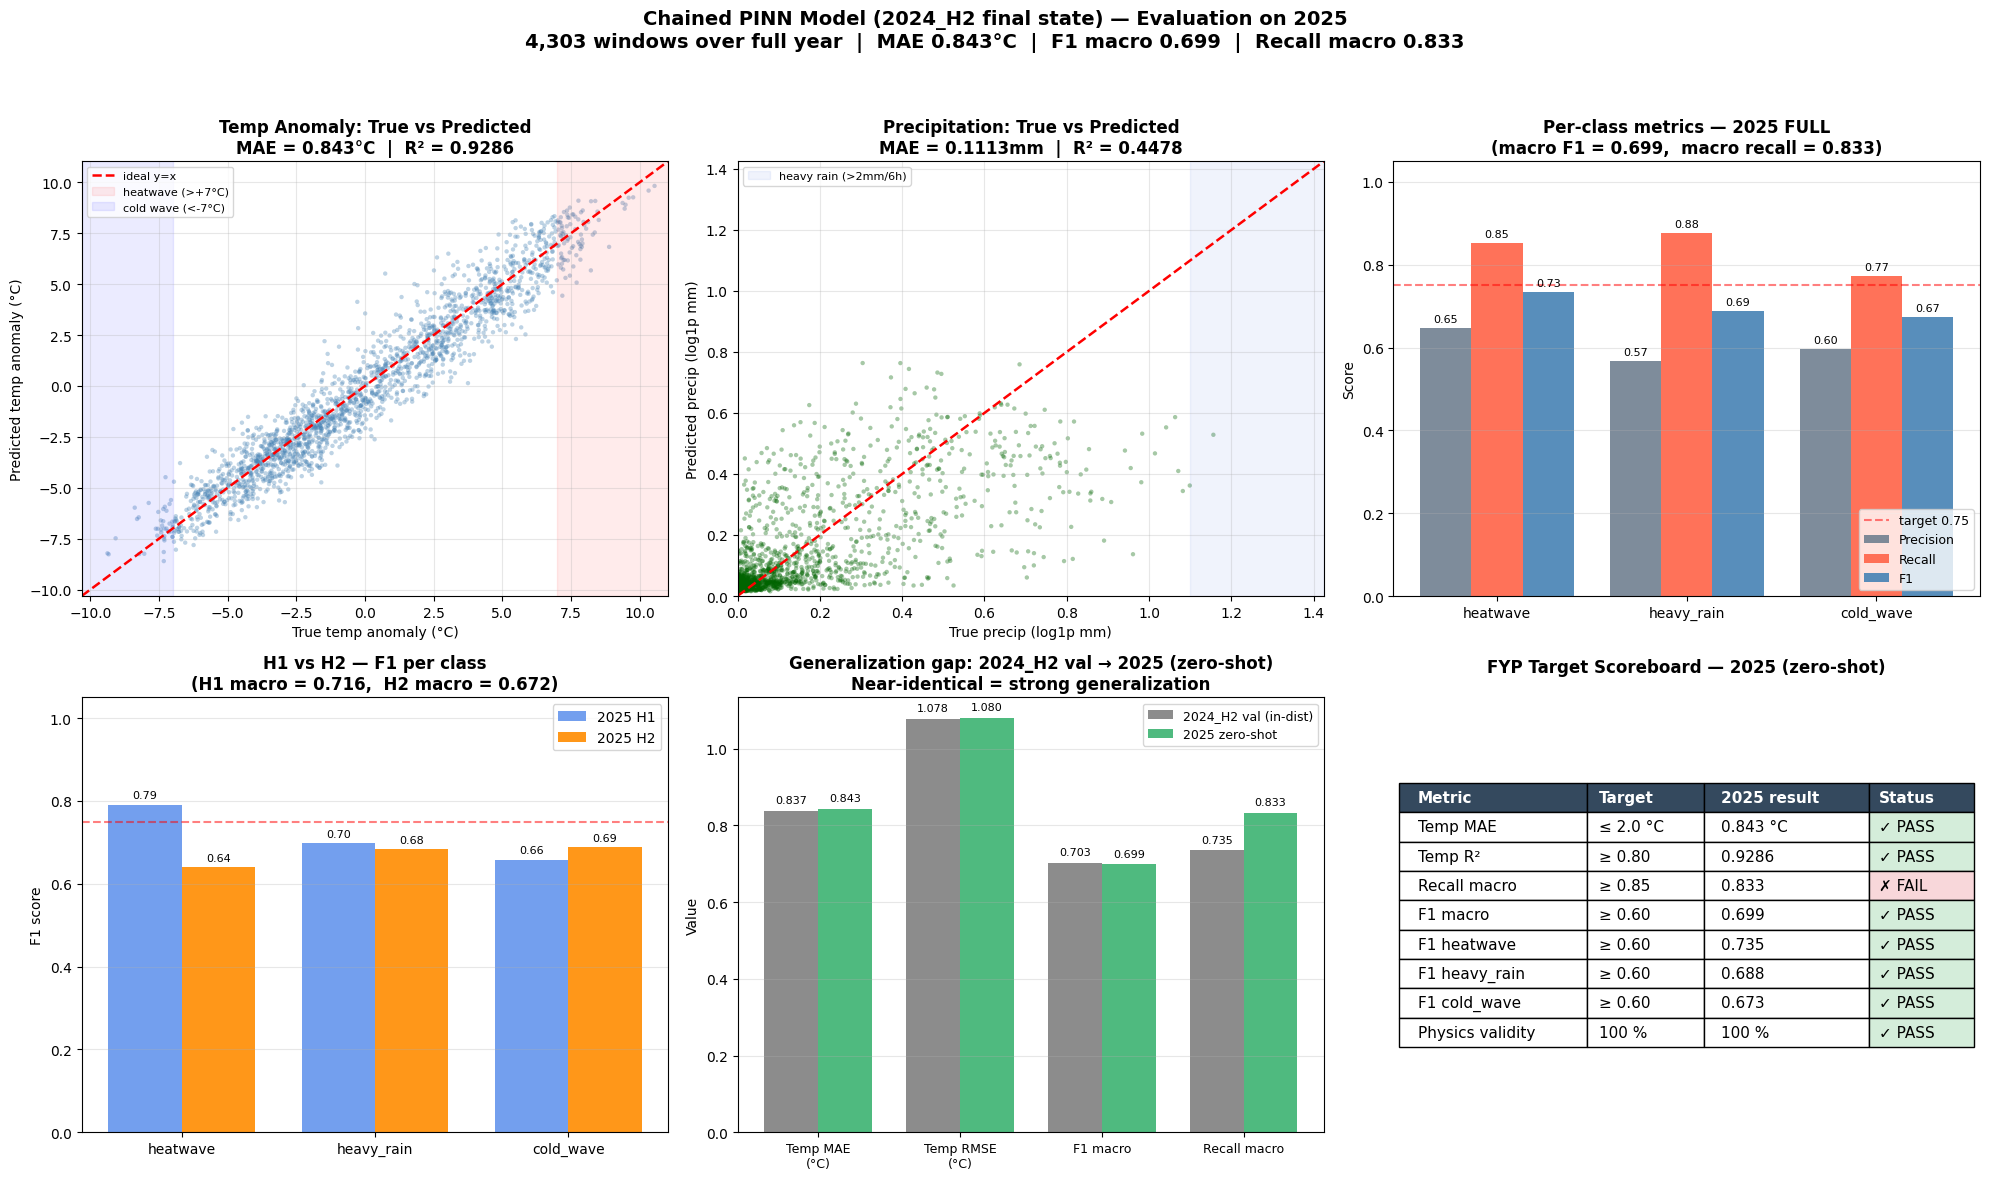


Saved: /kaggle/working/results_2025.png  (0.46 MB)


In [41]:
# PLOT GENERATOR — chained model on 2025 results

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

CLASS_NAMES = ['heatwave', 'heavy_rain', 'cold_wave']
OUTPUT_DIR  = '/kaggle/working'

# Sanity check that everything we need is in scope
for var in ['pt_c', 'pp_c', 'yt_all', 'yp_all', 'pe_all', 'yl_bin', 'thr',
            'm_full', 'm_h1', 'm_h2', 'target_t_all', 'T_h1', 'saved_metrics']:
    assert var in dir(), f"'{var}' not in memory — re-run test_chained_on_2025.py first"


fig, axes = plt.subplots(2, 3, figsize=(20, 12))

ax = axes[0, 0]
n_show = min(2000, len(yt_all))
idx = np.random.default_rng(0).choice(len(yt_all), n_show, replace=False)
ax.scatter(yt_all[idx], pt_c[idx], alpha=0.35, s=10, color='steelblue',
           edgecolors='none')
lo = min(yt_all.min(), pt_c.min()) - 0.5
hi = max(yt_all.max(), pt_c.max()) + 0.5
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.8, label='ideal y=x')
ax.axvspan(7.0,  hi,  alpha=0.08, color='red',  label='heatwave (>+7°C)')
ax.axvspan(lo,  -7.0, alpha=0.08, color='blue', label='cold wave (<-7°C)')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('True temp anomaly (°C)')
ax.set_ylabel('Predicted temp anomaly (°C)')
ax.set_title(f"Temp Anomaly: True vs Predicted\nMAE = {m_full['mae_temp']:.3f}°C  |  R² = {m_full['r2_temp']:.4f}",
             fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
yp_log = np.log1p(yp_all)
pp_log = np.log1p(pp_c)
n_show = min(2000, len(yp_log))
idx = np.random.default_rng(1).choice(len(yp_log), n_show, replace=False)
ax.scatter(yp_log[idx], pp_log[idx], alpha=0.35, s=10, color='darkgreen',
           edgecolors='none')
lo = 0; hi = max(yp_log.max(), pp_log.max()) + 0.2
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.8)
ax.axvspan(np.log1p(2.0), hi, alpha=0.08, color='royalblue',
           label='heavy rain (>2mm/6h)')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('True precip (log1p mm)')
ax.set_ylabel('Predicted precip (log1p mm)')
ax.set_title(f"Precipitation: True vs Predicted\nMAE = {m_full['mae_precip']:.4f}mm  |  R² = {m_full['r2_precip']:.4f}",
             fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
metrics_data = {'P': [], 'R': [], 'F1': []}
for cname in CLASS_NAMES:
    pc = m_full['per_class'][cname]
    metrics_data['P'].append(pc['P'])
    metrics_data['R'].append(pc['R'])
    metrics_data['F1'].append(pc['F1'])
x = np.arange(len(CLASS_NAMES))
w = 0.27
bars1 = ax.bar(x - w, metrics_data['P'], w, label='Precision', color='slategray', alpha=0.9)
bars2 = ax.bar(x,     metrics_data['R'], w, label='Recall',    color='tomato',    alpha=0.9)
bars3 = ax.bar(x + w, metrics_data['F1'], w, label='F1',       color='steelblue', alpha=0.9)
for bars in [bars1, bars2, bars3]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.01, f'{h:.2f}',
                ha='center', va='bottom', fontsize=8)
ax.axhline(0.75, color='red', linestyle='--', alpha=0.5, label='target 0.75')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title(f"Per-class metrics — 2025 FULL\n(macro F1 = {m_full['f1_macro']:.3f},  macro recall = {m_full['recall_macro']:.3f})",
             fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
f1_h1 = [m_h1['per_class'][c]['F1'] for c in CLASS_NAMES]
f1_h2 = [m_h2['per_class'][c]['F1'] for c in CLASS_NAMES]
x = np.arange(len(CLASS_NAMES))
w = 0.38
b1 = ax.bar(x - w/2, f1_h1, w, label='2025 H1', color='cornflowerblue', alpha=0.9)
b2 = ax.bar(x + w/2, f1_h2, w, label='2025 H2', color='darkorange',     alpha=0.9)
for bs, vals in [(b1, f1_h1), (b2, f1_h2)]:
    for b, v in zip(bs, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=8)
ax.axhline(0.75, color='red', linestyle='--', alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.05); ax.set_ylabel('F1 score')
ax.set_title(f"H1 vs H2 — F1 per class\n(H1 macro = {m_h1['f1_macro']:.3f},  H2 macro = {m_h2['f1_macro']:.3f})",
             fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax = axes[1, 1]
keys     = ['mae_temp',    'rmse_temp',  'f1_macro',  'recall_macro']
labels   = ['Temp MAE\n(°C)', 'Temp RMSE\n(°C)', 'F1 macro',  'Recall macro']
v_train  = [saved_metrics[k] for k in keys]
v_test   = [m_full[k]        for k in keys]
x = np.arange(len(keys))
w = 0.38
b1 = ax.bar(x - w/2, v_train, w, label='2024_H2 val (in-dist)', color='gray',       alpha=0.9)
b2 = ax.bar(x + w/2, v_test,  w, label='2025 zero-shot',        color='mediumseagreen', alpha=0.9)
for bs, vals in [(b1, v_train), (b2, v_test)]:
    for b, v in zip(bs, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.015, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Value')
ax.set_title("Generalization gap: 2024_H2 val → 2025 (zero-shot)\nNear-identical = strong generalization",
             fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 2]; ax.axis('off')
status_pass = lambda b: '✓ PASS' if b else '✗ FAIL'
rows = [
    ['Metric',          'Target',       '2025 result',                         'Status'],
    ['Temp MAE',        '≤ 2.0 °C',     f"{m_full['mae_temp']:.3f} °C",        status_pass(m_full['mae_temp'] <= 2.0)],
    ['Temp R²',         '≥ 0.80',       f"{m_full['r2_temp']:.4f}",            status_pass(m_full['r2_temp'] >= 0.80)],
    ['Recall macro',    '≥ 0.85',       f"{m_full['recall_macro']:.3f}",       status_pass(m_full['recall_macro'] >= 0.85)],
    ['F1 macro',        '≥ 0.60',       f"{m_full['f1_macro']:.3f}",           status_pass(m_full['f1_macro'] >= 0.60)],
    ['F1 heatwave',     '≥ 0.60',       f"{m_full['per_class']['heatwave']['F1']:.3f}",
                                                                                status_pass(m_full['per_class']['heatwave']['F1'] >= 0.60)],
    ['F1 heavy_rain',   '≥ 0.60',       f"{m_full['per_class']['heavy_rain']['F1']:.3f}",
                                                                                status_pass(m_full['per_class']['heavy_rain']['F1'] >= 0.60)],
    ['F1 cold_wave',    '≥ 0.60',       f"{m_full['per_class']['cold_wave']['F1']:.3f}",
                                                                                status_pass(m_full['per_class']['cold_wave']['F1'] >= 0.60)],
    ['Physics validity','100 %',        '100 %',                               '✓ PASS'],
]
tbl = ax.table(cellText=rows, cellLoc='left', loc='center',
               colWidths=[0.32, 0.20, 0.28, 0.18])
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.7)
for j in range(4):
    c = tbl[(0, j)]
    c.set_facecolor('#34495e'); c.set_text_props(weight='bold', color='white')
for i in range(1, len(rows)):
    c = tbl[(i, 3)]
    c.set_facecolor('#d4edda' if 'PASS' in rows[i][3] else '#f8d7da')
ax.set_title('FYP Target Scoreboard — 2025 (zero-shot)', fontweight='bold', pad=18)


fig.suptitle(
    f"Chained PINN Model (2024_H2 final state) — Evaluation on 2025\n"
    f"4,303 windows over full year  |  MAE {m_full['mae_temp']:.3f}°C  |  "
    f"F1 macro {m_full['f1_macro']:.3f}  |  Recall macro {m_full['recall_macro']:.3f}",
    fontsize=14, fontweight='bold',
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

out_path = f'{OUTPUT_DIR}/results_2025.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"\nSaved: {out_path}  ({os.path.getsize(out_path)/1e6:.2f} MB)")

In [8]:
import os
import logging
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Sequence, Callable

import numpy as np

logger = logging.getLogger("analog_module_v3")
logger.setLevel(logging.INFO)

ZONE_NAMES        = ("N_Mountains", "KP_U_Punjab", "C_Punjab",
                     "Sindh_Coast", "Balochistan")
CHANNELS_PER_ZONE = ("t2m_C", "precip_mm")
N_ZONES           = len(ZONE_NAMES)
N_PER_ZONE        = len(CHANNELS_PER_ZONE)
N_FEATURES        = N_ZONES * N_PER_ZONE         # = 10
WINDOW_LEN        = 24


class WindowSummarizer:
    def __init__(self,
                 zone_names: Sequence[str] = ZONE_NAMES,
                 channels_per_zone: Sequence[str] = CHANNELS_PER_ZONE):
        self.zone_names = list(zone_names)
        self.channels   = list(channels_per_zone)
        self.n_zones    = len(zone_names)
        self.n_per      = len(channels_per_zone)
        self._idx = {c: i for i, c in enumerate(channels_per_zone)}

    def _zone_field(self, window, t_idx, ch_name):
        ci   = self._idx[ch_name]
        cols = [zi * self.n_per + ci for zi in range(self.n_zones)]
        return window[t_idx, cols]

    def _zone_mean(self, window, ch_name):
        ci   = self._idx[ch_name]
        cols = [zi * self.n_per + ci for zi in range(self.n_zones)]
        return window[:, cols].mean(axis=0)

    def summarize(self, window, outcome_temp_c, outcome_precip_mm,
                  outcome_flags=None, date_str=None, window_idx=None):
        t2m_now   = self._zone_field(window, -1, "t2m_C")
        t2m_clim  = self._zone_mean(window, "t2m_C")
        t2m_anom  = t2m_now - t2m_clim
        prcp_now  = self._zone_field(window, -1, "precip_mm")
        prcp_win  = self._zone_mean(window, "precip_mm")

        zone_phrases = [
            f"{zname} t_anom {t2m_anom[zi]:+.1f}C precip {prcp_now[zi]:.2f}mm"
            for zi, zname in enumerate(self.zone_names)
        ]
        zone_str = "; ".join(zone_phrases)

        flags = outcome_flags or {}
        flag_words = []
        if flags.get("heatwave"):   flag_words.append("heatwave")
        if flags.get("heavy_rain"): flag_words.append("heavy_rain")
        if flags.get("cold_wave"):  flag_words.append("cold_wave")
        flag_str = ("flags " + ",".join(flag_words)) if flag_words else "no_flags"

        date_part = f"date {date_str}; " if date_str else ""
        text = (
            f"{date_part}{zone_str}; "
            f"PrecipMean_win {float(prcp_win.mean()):.2f}mm; "
            f"{flag_str}; "
            f"outcome+6h temp {outcome_temp_c:+.2f}C precip {outcome_precip_mm:.2f}mm."
        )

      
        month = None
        if date_str is not None:
            try:
                month = int(str(date_str)[5:7])
            except (ValueError, IndexError):
                month = None

        meta = {
            "outcome_temp_c":    float(outcome_temp_c),
            "outcome_precip_mm": float(outcome_precip_mm),
            "is_heatwave":       bool(flags.get("heatwave",   False)),
            "is_heavy_rain":     bool(flags.get("heavy_rain", False)),
            "is_cold_wave":      bool(flags.get("cold_wave",  False)),
            "doc_type":          "analog_window",
            "month":             month,
        }
        if date_str  is not None: meta["date"]       = str(date_str)
        if window_idx is not None: meta["window_idx"] = int(window_idx)

        doc_id = (f"analog_{window_idx:06d}" if window_idx is not None
                  else f"analog_{abs(hash(text)) % 10**9:09d}")
        return {"id": doc_id, "text": text, "metadata": meta}

class AnalogVectorStore:


    @staticmethod
    def _vec_dim():
        return 5 * N_FEATURES + 4 * N_ZONES  

    DIM = None   

    def __init__(self,
                 collection_name: str = "analog_windows_numeric_v3",
                 persist_path: Optional[str] = None):
        self.collection_name = collection_name
        self.persist_path    = persist_path
        self._ids:     List[str]            = []
        self._texts:   List[str]            = []
        self._metas:   List[Dict[str, Any]] = []
        self._vectors: Optional[np.ndarray] = None    
        self._raw:     Optional[np.ndarray] = None    
        self._mean:    Optional[np.ndarray] = None
        self._std:     Optional[np.ndarray] = None
        self._loaded   = False

    @staticmethod
    def window_to_vec(window: np.ndarray) -> np.ndarray:
        T = window.shape[0]
        assert window.shape[1] == N_FEATURES, \
            f"expected {N_FEATURES} features, got {window.shape[1]}"

        # Channel-column indices
        t2m_cols  = [zi * N_PER_ZONE + 0 for zi in range(N_ZONES)]
        prcp_cols = [zi * N_PER_ZONE + 1 for zi in range(N_ZONES)]

        # Full / early / late means
        mean_full  = window.mean(axis=0)                        
        third      = max(1, T // 3)
        mean_early = window[:third].mean(axis=0)                  
        mean_late  = window[-third:].mean(axis=0)                 

        last = window[-1]                                          
        t = np.arange(T, dtype=np.float32)
        t_centered = t - t.mean()
        denom = (t_centered ** 2).sum() + 1e-9
        slopes = ((window - mean_full) * t_centered[:, None]).sum(axis=0) / denom  

        # Per-zone t2m anomaly (last vs window mean) and std
        t2m_anom = window[-1, t2m_cols] - window[:, t2m_cols].mean(axis=0)         
        t2m_std  = window[:, t2m_cols].std(axis=0)                                

        # Per-zone precip max + total
        prcp_max   = window[:, prcp_cols].max(axis=0)                              
        prcp_total = window[:, prcp_cols].sum(axis=0)                            

        vec = np.concatenate([
            mean_full, mean_early, mean_late, last, slopes,
            t2m_anom, t2m_std, prcp_max, prcp_total,
        ]).astype(np.float32)

        assert vec.shape[0] == 5 * N_FEATURES + 4 * N_ZONES
        return vec

    def _normalize_vecs(self, raw: np.ndarray) -> np.ndarray:
        z = (raw - self._mean) / np.maximum(self._std, 1e-6)
        n = np.linalg.norm(z, axis=1, keepdims=True) + 1e-9
        return (z / n).astype(np.float32)

    def _store_file(self) -> Optional[str]:
        if not self.persist_path: return None
        os.makedirs(self.persist_path, exist_ok=True)
        return os.path.join(self.persist_path, f"{self.collection_name}.npz")

    def _try_reload(self):
        if self._loaded: return
        sf = self._store_file()
        self._loaded = True
        if sf and os.path.exists(sf):
            try:
                blob = np.load(sf, allow_pickle=True)
                self._ids     = list(blob['ids'])
                self._texts   = list(blob['texts'])
                self._metas   = list(blob['metas'])
                self._vectors = blob['vectors']
                self._raw     = blob['raw'] if 'raw' in blob.files else None
                self._mean    = blob['mean']
                self._std     = blob['std']
                # Verify dim — refuse to reuse a stale cache from v2
                expected_dim = self._vec_dim()
                if self._vectors.shape[1] != expected_dim:
                    logger.warning("Cache dim mismatch (%d vs %d) — clearing.",
                                   self._vectors.shape[1], expected_dim)
                    self._ids = []; self._texts = []; self._metas = []
                    self._vectors = None; self._raw = None
                    self._mean = None; self._std = None
                else:
                    logger.info("Reloaded %d v3 analogs from %s",
                                len(self._ids), sf)
            except Exception as e:
                logger.warning("Reload failed: %s", e)

    def _persist(self):
        sf = self._store_file()
        if sf is None: return
        np.savez_compressed(
            sf,
            ids=np.array(self._ids, dtype=object),
            texts=np.array(self._texts, dtype=object),
            metas=np.array(self._metas, dtype=object),
            vectors=self._vectors if self._vectors is not None else np.zeros((0, self._vec_dim()), dtype=np.float32),
            raw=self._raw if self._raw is not None else np.zeros((0, self._vec_dim()), dtype=np.float32),
            mean=self._mean if self._mean is not None else np.zeros(self._vec_dim(), dtype=np.float32),
            std=self._std   if self._std  is not None else np.ones(self._vec_dim(), dtype=np.float32),
        )

  
    def count(self) -> int:
        self._try_reload()
        return len(self._ids)

    def add_windows(self,
                    windows: np.ndarray,                  
                    docs: Sequence[Dict[str, Any]],
                    ) -> None:

        self._try_reload()
        assert windows.shape[0] == len(docs), "windows/docs length mismatch"
        raw_new = np.stack([self.window_to_vec(w) for w in windows], axis=0)

     
        if self._raw is None:
            self._raw = raw_new
        else:
            self._raw = np.concatenate([self._raw, raw_new], axis=0)

        self._ids.extend([d["id"]   for d in docs])
        self._texts.extend([d["text"] for d in docs])
        self._metas.extend([d.get("metadata", {}) for d in docs])

       
        if self._vectors is None:
            self._vectors = np.zeros_like(raw_new)
        else:
            self._vectors = np.concatenate(
                [self._vectors, np.zeros_like(raw_new)], axis=0
            )

    def refit_and_renormalize(self):
        """Fit mean/std on the FULL accumulated raw pool, then renormalize
        every vector. Call this once after all add_windows() calls."""
        if self._raw is None or len(self._raw) == 0:
            return
        self._mean = self._raw.mean(axis=0).astype(np.float32)
        self._std  = self._raw.std (axis=0).astype(np.float32)
        self._vectors = self._normalize_vecs(self._raw)
        self._persist()
        logger.info("Refit z-score stats on %d analogs (dim=%d).",
                    len(self._ids), self._vec_dim())

    def query_window(self,
                     window: np.ndarray,
                     k: int = 5,
                     where: Optional[Dict[str, Any]] = None,
                     query_month: Optional[int] = None,
                     month_tolerance: int = 1,
                     ) -> List[Dict[str, Any]]:

        self._try_reload()
        if self._vectors is None or len(self._ids) == 0:
            return []
        if self._mean is None:
            raise RuntimeError(
                "Mean/std not fitted. Call refit_and_renormalize() after "
                "adding all batches before querying."
            )

        raw = self.window_to_vec(window).reshape(1, -1)
        q   = self._normalize_vecs(raw)
        sims = (self._vectors @ q.T).ravel()           

      
        keep = np.ones(len(self._ids), dtype=bool)

        if query_month is not None:
            allowed = set()
            for d in range(-month_tolerance, month_tolerance + 1):
                m = ((query_month - 1 + d) % 12) + 1
                allowed.add(m)
            keep &= np.array([
                (meta.get("month") in allowed) for meta in self._metas
            ])
            # Fallback: if too few survive, drop the seasonal filter for this query
            if keep.sum() < max(k * 4, 30):
                keep = np.ones(len(self._ids), dtype=bool)

      
        if where:
            keep &= np.array([
                all(meta.get(kk) == vv for kk, vv in where.items())
                for meta in self._metas
            ])

        sims = np.where(keep, sims, -np.inf)
        order = np.argsort(-sims)[:k]
        return [{
            "id":       self._ids[j],
            "text":     self._texts[j],
            "metadata": self._metas[j],
            "distance": float(1.0 - sims[j]),
        } for j in order if np.isfinite(sims[j])]


AnalogVectorStore.DIM = AnalogVectorStore._vec_dim()


@dataclass
class AnalogForecast:
    temp_anom_c:      float
    precip_mm:        float
    p_heatwave:       float
    p_heavy_rain:     float
    p_cold_wave:      float
    analog_temps:     List[float] = field(default_factory=list)
    analog_precips:   List[float] = field(default_factory=list)
    analog_ids:       List[str]   = field(default_factory=list)
    analog_dates:     List[str]   = field(default_factory=list)
    analog_distances: List[float] = field(default_factory=list)
    analog_weights:   List[float] = field(default_factory=list)
    n_analogs:        int         = 0


class AnalogForecaster:
    def __init__(self, k: int = 8, temperature: float = 0.10):
        self.k = k
        self.temperature = temperature

    def forecast(self, neighbors: List[Dict[str, Any]]) -> AnalogForecast:
        if not neighbors:
            return AnalogForecast(0.0, 0.0, 0.0, 0.0, 0.0)

        dists = np.array([n["distance"] for n in neighbors], dtype=np.float32)
        # Softmax with negative distances → closer neighbors get higher weight
        logits = -dists / max(self.temperature, 1e-6)
        logits -= logits.max()
        w = np.exp(logits); w /= (w.sum() + 1e-9)

        temps   = np.array([n["metadata"].get("outcome_temp_c",    0.0) for n in neighbors])
        precips = np.array([n["metadata"].get("outcome_precip_mm", 0.0) for n in neighbors])
        heat    = np.array([n["metadata"].get("is_heatwave",   False) for n in neighbors], dtype=np.float32)
        rain    = np.array([n["metadata"].get("is_heavy_rain", False) for n in neighbors], dtype=np.float32)
        cold    = np.array([n["metadata"].get("is_cold_wave",  False) for n in neighbors], dtype=np.float32)
        dates   = [n["metadata"].get("date", "") for n in neighbors]

        return AnalogForecast(
            temp_anom_c   = float((w * temps).sum()),
            precip_mm     = float((w * precips).sum()),
            p_heatwave    = float((w * heat).sum()),
            p_heavy_rain  = float((w * rain).sum()),
            p_cold_wave   = float((w * cold).sum()),
            analog_temps     = temps.tolist(),
            analog_precips   = precips.tolist(),
            analog_ids       = [n["id"] for n in neighbors],
            analog_dates     = dates,
            analog_distances = dists.tolist(),
            analog_weights   = w.tolist(),
            n_analogs        = len(neighbors),
        )


@dataclass
class HybridConfig:
    alpha: float = 0.80
    beta:  float = 0.20
    alpha_extreme: float = 0.60
    beta_extreme:  float = 0.40
    extreme_prob_threshold: float = 0.5


class HybridFuser:
    def __init__(self, cfg: HybridConfig = HybridConfig()):
        self.cfg = cfg

    def fuse(self, pinn_temp_c, pinn_precip_mm, analog: AnalogForecast):
        any_extreme_prob = max(analog.p_heatwave, analog.p_heavy_rain, analog.p_cold_wave)
        is_extreme = any_extreme_prob >= self.cfg.extreme_prob_threshold
        if is_extreme:
            a, b = self.cfg.alpha_extreme, self.cfg.beta_extreme
        else:
            a, b = self.cfg.alpha, self.cfg.beta
        fused_temp = a * pinn_temp_c    + b * analog.temp_anom_c
        fused_prcp = a * pinn_precip_mm + b * analog.precip_mm
        return {
            "temp_anom_c": float(fused_temp),
            "precip_mm":   float(fused_prcp),
            "alpha_used":  a, "beta_used": b,
            "is_extreme_mode": bool(is_extreme),
        }

class AnalogLLMExplainer:
    DEFAULT_SYSTEM = (
        "You are a careful climate analyst. Given a current weather window, "
        "the PINN forecast, and a few historical analogs with their outcomes, "
        "produce a SHORT structured judgment in JSON with keys: "
        "agreement ('agree'|'disagree'|'partial'), risk_level "
        "('low'|'medium'|'high'|'severe'), key_drivers (short list), "
        "explanation (1-2 sentences)."
    )

    def __init__(self, llm_callable: Optional[Callable[[str, str], str]] = None,
                 system_prompt: Optional[str] = None):
        self.llm_callable = llm_callable
        self.system_prompt = system_prompt or self.DEFAULT_SYSTEM

    def build_user_prompt(self, query_text, pinn_temp_c, pinn_precip_mm,
                          analog: AnalogForecast, neighbors):
        lines = [f"CURRENT_WINDOW: {query_text}",
                 f"PINN_FORECAST: temp_anom {pinn_temp_c:+.2f}C, "
                 f"precip {pinn_precip_mm:.2f}mm.",
                 f"ANALOG_FORECAST: temp_anom {analog.temp_anom_c:+.2f}C, "
                 f"precip {analog.precip_mm:.2f}mm; "
                 f"p_heat {analog.p_heatwave:.2f}, "
                 f"p_rain {analog.p_heavy_rain:.2f}, "
                 f"p_cold {analog.p_cold_wave:.2f}.",
                 "ANALOGS:"]
        for i, n in enumerate(neighbors[:5]):
            lines.append(f"  [{i+1}] {n['text']}")
        lines.append('Respond ONLY with the JSON object.')
        return "\n".join(lines)

    def explain(self, query_text, pinn_temp_c, pinn_precip_mm, analog, neighbors):
        if self.llm_callable is None:
            return {"raw": None, "parsed": None,
                    "note": "no LLM callable provided"}
        user = self.build_user_prompt(query_text, pinn_temp_c, pinn_precip_mm,
                                      analog, neighbors)
        try:
            raw = self.llm_callable(self.system_prompt, user)
        except Exception as e:
            return {"raw": None, "parsed": None, "note": f"LLM error: {e}"}
        import json as _json, re as _re
        parsed = None
        try:
            parsed = _json.loads(raw)
        except Exception:
            m = _re.search(r"\{.*\}", raw or "", _re.DOTALL)
            if m:
                try: parsed = _json.loads(m.group(0))
                except Exception: parsed = None
        return {"raw": raw, "parsed": parsed}

class AnalogForecastingPipeline:
    def __init__(self, summarizer, store, forecaster, fuser, explainer=None,
                 use_seasonal_filter: bool = True, month_tolerance: int = 1):
        self.summarizer = summarizer
        self.store      = store
        self.forecaster = forecaster
        self.fuser      = fuser
        self.explainer  = explainer
        self.use_seasonal_filter = use_seasonal_filter
        self.month_tolerance     = month_tolerance

    def build_index(self, windows, outcome_temps_c, outcome_precips_mm,
                    outcome_flags, dates=None, stride=1, max_index=None):
        """Index a batch of historical windows. Refits global z-score
        stats at the end via refit_and_renormalize()."""
        N = len(windows)
        idxs = list(range(0, N, max(1, stride)))
        if max_index is not None:
            idxs = idxs[:max_index]

        docs = []
        sel_windows = []
        for i in idxs:
            w = windows[i]
            flags = {
                "heatwave":   bool(outcome_flags[i, 0]),
                "heavy_rain": bool(outcome_flags[i, 1]),
                "cold_wave":  bool(outcome_flags[i, 2]),
            }
            date_str = dates[i] if dates is not None else None
            doc = self.summarizer.summarize(
                window            = w,
                outcome_temp_c    = float(outcome_temps_c[i]),
                outcome_precip_mm = float(outcome_precips_mm[i]),
                outcome_flags     = flags,
                date_str          = date_str,
                window_idx        = i,
            )
            docs.append(doc)
            sel_windows.append(w)

        sel_windows = np.stack(sel_windows, axis=0)
        self.store.add_windows(sel_windows, docs)
        # CRITICAL: refit z-score stats on the full accumulated pool
        self.store.refit_and_renormalize()
        return len(docs)

    def _query_month(self, query_date_str):
        if query_date_str is None:
            return None
        try:
            return int(str(query_date_str)[5:7])
        except (ValueError, IndexError):
            return None

    def forecast_one(self, window, pinn_temp_c, pinn_precip_mm,
                     query_date_str=None, do_explain=None):
        month = self._query_month(query_date_str) if self.use_seasonal_filter else None
        neighbors = self.store.query_window(
            window, k=self.forecaster.k,
            query_month=month, month_tolerance=self.month_tolerance,
        )
        analog = self.forecaster.forecast(neighbors)
        fused  = self.fuser.fuse(pinn_temp_c, pinn_precip_mm, analog)

        query_doc = self.summarizer.summarize(
            window=window, outcome_temp_c=pinn_temp_c,
            outcome_precip_mm=pinn_precip_mm,
            outcome_flags={"heatwave": False, "heavy_rain": False, "cold_wave": False},
            date_str=query_date_str,
        )
        query_text = query_doc["text"]

        explanation = None
        if do_explain and self.explainer is not None:
            explanation = self.explainer.explain(
                query_text, pinn_temp_c, pinn_precip_mm, analog, neighbors,
            )

        return {
            "query_text": query_text,
            "pinn":   {"temp_anom_c": float(pinn_temp_c), "precip_mm": float(pinn_precip_mm)},
            "analog": {
                "temp_anom_c":  analog.temp_anom_c,
                "precip_mm":    analog.precip_mm,
                "p_heatwave":   analog.p_heatwave,
                "p_heavy_rain": analog.p_heavy_rain,
                "p_cold_wave":  analog.p_cold_wave,
                "n_analogs":    analog.n_analogs,
                "analog_ids":       analog.analog_ids,
                "analog_distances": analog.analog_distances,
                "analog_weights":   analog.analog_weights,
                "analog_temps":     analog.analog_temps,
                "analog_precips":   analog.analog_precips,
                "analog_dates":     analog.analog_dates,
            },
            "fused":       fused,
            "explanation": explanation,
        }

    def forecast_batch(self, windows, pinn_temps_c, pinn_precips_mm,
                       query_dates=None, do_explain=None, progress_every=100):
        results = []
        N = len(windows)
        for i in range(N):
            qd = query_dates[i] if query_dates is not None else None
            r = self.forecast_one(
                window=windows[i],
                pinn_temp_c=float(pinn_temps_c[i]),
                pinn_precip_mm=float(pinn_precips_mm[i]),
                query_date_str=qd,
                do_explain=False,
            )
            r["sample_idx"] = i
            results.append(r)
            if progress_every and (i + 1) % progress_every == 0:
                logger.info("forecast_batch: %d / %d", i + 1, N)
        return results

    @staticmethod
    def stack_predictions(results):
        pinn_t = np.array([r["pinn"]["temp_anom_c"]    for r in results], dtype=np.float32)
        pinn_p = np.array([r["pinn"]["precip_mm"]      for r in results], dtype=np.float32)
        anlg_t = np.array([r["analog"]["temp_anom_c"]  for r in results], dtype=np.float32)
        anlg_p = np.array([r["analog"]["precip_mm"]    for r in results], dtype=np.float32)
        fuse_t = np.array([r["fused"]["temp_anom_c"]   for r in results], dtype=np.float32)
        fuse_p = np.array([r["fused"]["precip_mm"]     for r in results], dtype=np.float32)
        return pinn_t, pinn_p, anlg_t, anlg_p, fuse_t, fuse_p


print(f"Loaded analog module v3. Vector dim: {AnalogVectorStore.DIM}")

Loaded analog module v3. Vector dim: 70


In [9]:
import os
import sys
import gc
import json
import time
import logging
from collections import Counter
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, f1_score

logging.basicConfig(level=logging.INFO, force=True)
logging.getLogger("analog_module_v3").setLevel(logging.INFO)

OUTPUT_DIR = globals().get('OUTPUT_DIR', '/kaggle/working')

HIST_YEARS  = [str(y) for y in range(2015, 2025)]
HIST_HALVES = ['H1', 'H2']
ANALOG_WIN  = 24
HIST_STRIDE = 2          
LEAD        = 6

_required_2025 = ['pt_c', 'pp_c', 'yt_all', 'yp_all', 'yl_bin',
                  'target_t_all', 't2m_c_zonal', 'tp_mm_zonal',
                  'target_temp', 'target_precip', 'labels', 'thr', 'T_h1']
_missing = [v for v in _required_2025 if v not in dir()]
if _missing:
    raise RuntimeError(f"Missing from 2025 eval cell: {_missing}")

_required_helpers = ['load_raw_batch', 'rolling_climatology',
                     'build_labels', 'CLIM_WINDOW_HOURS']
_missing_h = [v for v in _required_helpers if v not in dir()]
if _missing_h:
    raise RuntimeError(f"Missing helper functions: {_missing_h}")

_rag_required = ['WindowSummarizer', 'AnalogVectorStore', 'AnalogForecaster',
                 'HybridFuser', 'HybridConfig', 'AnalogForecastingPipeline',
                 'N_ZONES', 'N_PER_ZONE']
_rag_missing = [v for v in _rag_required if v not in dir()]
if _rag_missing:
    raise RuntimeError(f"Missing Cell A v3 classes: {_rag_missing}")

print("All required variables present — starting RAG v2.1 with seasonal filter.\n")

def _make_flat_zonal(t2m_c, tp_mm):
    T = t2m_c.shape[0]
    out = np.empty((T, N_ZONES * N_PER_ZONE), dtype=np.float32)
    for zi in range(N_ZONES):
        out[:, zi * N_PER_ZONE + 0] = t2m_c[:, zi]
        out[:, zi * N_PER_ZONE + 1] = tp_mm[:, zi]
    return out


def _windows_from_flat(flat_zonal, target_times, win_len):
    """(N, win_len, F) windows ending just before each target time."""
    N = len(target_times)
    F = flat_zonal.shape[1]
    out = np.zeros((N, win_len, F), dtype=np.float32)
    for i, t in enumerate(target_times):
        start = max(0, int(t) - win_len)
        chunk = flat_zonal[start : int(t)]
        out[i, -chunk.shape[0]:] = chunk
    return out

TEMP_WEIGHT = 3.0

class WindowNormaliser:
    """Fit on historical windows; transform historical + query windows."""

    def __init__(self, temp_weight: float = 3.0):
        self.temp_weight = temp_weight
        self.mean_ = None
        self.std_  = None

    def fit(self, windows: np.ndarray):
        flat = windows.reshape(-1, windows.shape[-1])
        self.mean_ = flat.mean(axis=0).astype(np.float32)
        self.std_  = flat.std (axis=0).astype(np.float32)
        self.std_[self.std_ < 1e-6] = 1e-6
        return self

    def transform(self, windows: np.ndarray) -> np.ndarray:
        out = (windows - self.mean_) / self.std_
        out = out.astype(np.float32)
        out[:, :, 0::N_PER_ZONE] *= self.temp_weight
        return out

    def fit_transform(self, windows: np.ndarray) -> np.ndarray:
        return self.fit(windows).transform(windows)


normaliser = WindowNormaliser(temp_weight=TEMP_WEIGHT)

print("── Building 2025 query windows ──")
flat_zonal_2025 = _make_flat_zonal(t2m_c_zonal, tp_mm_zonal)
query_windows_raw = _windows_from_flat(flat_zonal_2025, target_t_all, ANALOG_WIN)

query_truth_t = np.asarray(target_temp)  [target_t_all].astype(np.float32)
query_truth_p = np.asarray(target_precip)[target_t_all].astype(np.float32)
query_labels  = np.asarray(yl_bin).astype(np.int8)   # already aligned with target_t_all
N_query       = len(target_t_all)


_date_index_2025 = pd.date_range(
    '2025-01-01', periods=t2m_c_zonal.shape[0], freq='h',
)
query_dates = [
    _date_index_2025[min(int(t), len(_date_index_2025) - 1)]
                   .strftime('%Y-%m-%d %H:%M')
    for t in target_t_all
]
_query_months = [int(d[5:7]) for d in query_dates]
_month_hist   = dict(sorted(Counter(_query_months).items()))

print(f"  Query windows : {N_query}  shape=({ANALOG_WIN}, {N_ZONES * N_PER_ZONE})")
print(f"  Class balance : heat={query_labels[:,0].mean()*100:5.2f}%  "
      f"rain={query_labels[:,1].mean()*100:5.2f}%  "
      f"cold={query_labels[:,2].mean()*100:5.2f}%")
print(f"  Query dates   : {query_dates[0]}  →  {query_dates[-1]}")
print(f"  Months covered (count per month):")
for _m, _c in _month_hist.items():
    print(f"    {_m:>2d}: {_c:5d} queries")

hist_windows_list = []
hist_temps_list   = []
hist_precips_list = []
hist_flags_list   = []
hist_dates_list   = []

print(f"\n── Loading 2015–2024 history "
      f"({len(HIST_YEARS)} years × 2 halves, stride={HIST_STRIDE}) ──")
t_start = time.time()

for year in HIST_YEARS:
    for half in HIST_HALVES:
        bt0 = time.time()
        rf, t2m_c_b, tp_mm_b, ti_b = load_raw_batch(year, half)
        del rf

        clim_b   = rolling_climatology(t2m_c_b, window_hours=CLIM_WINDOW_HOURS)
        t_anom_b = (t2m_c_b - clim_b).astype(np.float32)
        labels_b = build_labels(t_anom_b, tp_mm_b)

        tgt_temp_b   = t_anom_b.mean(axis=1).astype(np.float32)
        tgt_precip_b = tp_mm_b .max(axis=1).astype(np.float32)

        T_b     = t2m_c_b.shape[0]
        valid_t = np.arange(ANALOG_WIN - 1, T_b - LEAD)
        valid_t = valid_t[::HIST_STRIDE]

        if len(valid_t) == 0:
            print(f"  {year}_{half}: T={T_b}  no valid windows (skipped)")
            continue

        flat_b  = _make_flat_zonal(t2m_c_b, tp_mm_b)
        wins_b  = _windows_from_flat(flat_b, valid_t + 1, ANALOG_WIN)

        outcome_t = valid_t + LEAD
        temps_b   = tgt_temp_b  [outcome_t]
        precips_b = tgt_precip_b[outcome_t]
        flags_b   = labels_b    [outcome_t].astype(np.int8)
        dates_b   = ti_b[outcome_t].strftime('%Y-%m-%d %H:%M').tolist()

        hist_windows_list.append(wins_b)
        hist_temps_list  .append(temps_b)
        hist_precips_list.append(precips_b)
        hist_flags_list  .append(flags_b)
        hist_dates_list  .extend(dates_b)

        print(f"  {year}_{half}: T={T_b:4d}  valid={len(valid_t):5d}  "
              f"heat={flags_b[:,0].sum():3d}  "
              f"rain={flags_b[:,1].sum():3d}  "
              f"cold={flags_b[:,2].sum():3d}  "
              f"({time.time()-bt0:.1f}s)")

        del t2m_c_b, tp_mm_b, clim_b, t_anom_b, labels_b
        del tgt_temp_b, tgt_precip_b, flat_b, wins_b
        gc.collect()

hist_windows = np.concatenate(hist_windows_list, axis=0)
hist_temps   = np.concatenate(hist_temps_list,   axis=0)
hist_precips = np.concatenate(hist_precips_list, axis=0)
hist_flags   = np.concatenate(hist_flags_list,   axis=0)
hist_dates   = hist_dates_list
del hist_windows_list, hist_temps_list, hist_precips_list, hist_flags_list
gc.collect()

print(f"\n  Total historical analogs : {len(hist_windows):,}  "
      f"(loaded in {time.time()-t_start:.1f}s)")
print(f"  Window memory            : {hist_windows.nbytes / 1e6:.1f} MB")
print(f"  Outcome ranges : "
      f"temp [{hist_temps.min():+.2f}, {hist_temps.max():+.2f}] °C  "
      f"precip [{hist_precips.min():.2f}, {hist_precips.max():.2f}] mm")
print(f"  Historical class balance : "
      f"heat={hist_flags[:,0].mean()*100:5.2f}%  "
      f"rain={hist_flags[:,1].mean()*100:5.2f}%  "
      f"cold={hist_flags[:,2].mean()*100:5.2f}%")


print("\n── Fitting normaliser on historical pool ──")
hist_windows_norm = normaliser.fit_transform(hist_windows)

raw_t_std  = hist_windows[:, :, 0::N_PER_ZONE].std()
raw_p_std  = hist_windows[:, :, 1::N_PER_ZONE].std()
norm_t_std = hist_windows_norm[:, :, 0::N_PER_ZONE].std()
norm_p_std = hist_windows_norm[:, :, 1::N_PER_ZONE].std()
print(f"  Raw   channel std  — t2m: {raw_t_std:.4f}   tp: {raw_p_std:.4f}")
print(f"  Normed channel std — t2m: {norm_t_std:.4f}   tp: {norm_p_std:.4f}  "
      f"(ratio = {norm_t_std/norm_p_std:.2f}x, target ≈ {TEMP_WEIGHT:.1f}x)")

# FIX 3 — Mask out irrelevant channels for split stores
hist_win_T = hist_windows_norm.copy()
hist_win_T[:, :, 1::N_PER_ZONE] = 0.0

hist_win_P = hist_windows_norm.copy()
hist_win_P[:, :, 0::N_PER_ZONE] = 0.0

del hist_windows_norm
gc.collect()

query_windows_norm = normaliser.transform(query_windows_raw)

query_win_T = query_windows_norm.copy()
query_win_T[:, :, 1::N_PER_ZONE] = 0.0

query_win_P = query_windows_norm.copy()
query_win_P[:, :, 0::N_PER_ZONE] = 0.0

del query_windows_raw, query_windows_norm
gc.collect()

print(f"\n  hist_win_T : {hist_win_T.shape}  ({hist_win_T.nbytes/1e6:.1f} MB)")
print(f"  hist_win_P : {hist_win_P.shape}  ({hist_win_P.nbytes/1e6:.1f} MB)")


def _make_pipeline(store_name, persist_subdir, k=8):
    summarizer = WindowSummarizer()
    store = AnalogVectorStore(
        collection_name=store_name,
        persist_path=f"{OUTPUT_DIR}/{persist_subdir}",
    )
    forecaster = AnalogForecaster(k=k, temperature=0.15)
    fuser      = HybridFuser(HybridConfig(
        alpha=0.80, beta=0.20,
        alpha_extreme=0.60, beta_extreme=0.40,
        extreme_prob_threshold=0.5,
    ))
    pipe = AnalogForecastingPipeline(
        summarizer=summarizer,
        store=store,
        forecaster=forecaster,
        fuser=fuser,
        explainer=None,
    )
    return pipe, store


_analog_module = sys.modules.get('analog_module_v3')
if _analog_module is not None:
    _analog_module.N_FEATURES = N_ZONES * N_PER_ZONE  # 10
    print(f"  Overrode analog_module_v3.N_FEATURES → {_analog_module.N_FEATURES}")
else:
    # Module was defined inline in the notebook, not imported — patch globals
    globals()['N_FEATURES'] = N_ZONES * N_PER_ZONE
    print(f"  Patched global N_FEATURES → {globals()['N_FEATURES']}")

pipe_T, store_T = _make_pipeline("analog_temp_hist2015_2024",  "analog_store_T")
pipe_P, store_P = _make_pipeline("analog_precip_hist2015_2024","analog_store_P")

def _build_or_reload(pipe, store, hist_win, hist_temps_in, hist_precips_in,
                     hist_flags_in, hist_dates_in, label):
    existing = store.count()
    if existing >= len(hist_win) // 2:
        print(f"  Re-using cached {label} store ({existing} docs).")
        return existing

    sf = store._store_file()
    if sf and os.path.exists(sf):
        os.remove(sf)
    store._ids = []; store._texts = []; store._metas = []
    store._vectors = None; store._raw = None
    store._mean = None; store._std = None
    store._loaded = True

    print(f"\n  Building {label} index from {len(hist_win):,} windows …")
    t0 = time.time()
    n = pipe.build_index(
        windows            = hist_win,
        outcome_temps_c    = hist_temps_in,
        outcome_precips_mm = hist_precips_in,
        outcome_flags      = hist_flags_in,
        dates              = hist_dates_in,
        stride             = 1,
        max_index          = None,
    )
    print(f"  {label}: indexed {n} analogs in {time.time()-t0:.1f}s.")
    return n

N_FEATURES = N_ZONES * N_PER_ZONE  

print("\n── Building analog indexes ──")
n_T = _build_or_reload(pipe_T, store_T, hist_win_T, hist_temps, hist_precips,
                        hist_flags, hist_dates, "TEMP")
n_P = _build_or_reload(pipe_P, store_P, hist_win_P, hist_temps, hist_precips,
                        hist_flags, hist_dates, "PRECIP")

# Quick sanity: confirm month metadata is present in the indexed analogs
_meta_with_month = sum(1 for m in store_T._metas if m.get("month") is not None)
print(f"  Analogs with month metadata (TEMP store): {_meta_with_month}/{len(store_T._metas)}")
if _meta_with_month < len(store_T._metas) // 2:
    print("  ⚠ WARNING: Less than half the analogs have month metadata. "
          "Seasonal filter will not be effective.")

del hist_win_T, hist_win_P, hist_temps, hist_precips, hist_flags, hist_dates
gc.collect()

eval_pinn_t  = np.asarray(pt_c).astype(np.float32)
eval_pinn_p  = np.asarray(pp_c).astype(np.float32)
eval_truth_t = query_truth_t
eval_truth_p = query_truth_p
eval_labels  = query_labels
eval_idx_2025 = np.arange(N_query, dtype=np.int64)

print(f"\nEval set (full 2025) : {N_query} samples")
print(f"  PINN temp   : [{eval_pinn_t.min():+.2f}, {eval_pinn_t.max():+.2f}] °C")
print(f"  PINN precip : [{eval_pinn_p.min():.2f}, {eval_pinn_p.max():.2f}] mm")
print(f"  Truth temp  : [{eval_truth_t.min():+.2f}, {eval_truth_t.max():+.2f}] °C")

print("\nRunning TEMP-store retrieval (seasonal filter ON) …")
results_T = pipe_T.forecast_batch(
    windows         = query_win_T,
    pinn_temps_c    = eval_pinn_t,
    pinn_precips_mm = eval_pinn_p,
    do_explain      = None,
    progress_every  = 50,
    query_dates     = query_dates,     
)

print("Running PRECIP-store retrieval (seasonal filter ON) …")
results_P = pipe_P.forecast_batch(
    windows         = query_win_P,
    pinn_temps_c    = eval_pinn_t,
    pinn_precips_mm = eval_pinn_p,
    do_explain      = None,
    progress_every  = 50,
    query_dates     = query_dates,      
)

pinn_t_T, pinn_p_T, anlg_t_T, anlg_p_T, fuse_t_T, fuse_p_T = \
    pipe_T.stack_predictions(results_T)
pinn_t_P, pinn_p_P, anlg_t_P, anlg_p_P, fuse_t_P, fuse_p_P = \
    pipe_P.stack_predictions(results_P)

anlg_t_mrg  = anlg_t_T
anlg_p_mrg  = anlg_p_P
fuse_t_mrg  = fuse_t_T
fuse_p_mrg  = fuse_p_P

p_heat_T = np.array([float(r['analog']['p_heatwave'])   for r in results_T], dtype=np.float32)
p_cold_T = np.array([float(r['analog']['p_cold_wave'])  for r in results_T], dtype=np.float32)
p_rain_P = np.array([float(r['analog']['p_heavy_rain']) for r in results_P], dtype=np.float32)

pinn_t_final = pinn_t_T
pinn_p_final = pinn_p_T

print(f"\nRetrieved.  Analog temp range: [{anlg_t_mrg.min():+.2f}, {anlg_t_mrg.max():+.2f}] °C  "
      f"precip range: [{anlg_p_mrg.min():.2f}, {anlg_p_mrg.max():.2f}] mm")

def _rmse(a, b):
    return float(np.sqrt(((np.asarray(a) - np.asarray(b)) ** 2).mean()))

thr_heat = float(thr[0]); thr_rain = float(thr[1]); thr_cold = float(thr[2])

def classify_tp(pt, pp):
    return np.stack([
        (pt >  thr_heat).astype(int),
        (pp >  thr_rain).astype(int),
        (pt < -thr_cold).astype(int),
    ], axis=1)

truth_lbl = eval_labels.astype(int)

def _f1_macro_reg(pt, pp):
    pred = classify_tp(np.asarray(pt), np.asarray(pp))
    return float(f1_score(truth_lbl, pred, average='macro', zero_division=0))

anlg_cls = np.stack([
    (p_heat_T > 0.5).astype(int),
    (p_rain_P > 0.5).astype(int),
    (p_cold_T > 0.5).astype(int),
], axis=1)
f1_anlg_prob = float(f1_score(truth_lbl, anlg_cls, average='macro', zero_division=0))

print(f"\n{'─'*72}")
print(f"{'Model':<20} {'MAE-T':>7} {'RMSE-T':>7} {'MAE-P':>7} {'RMSE-P':>7} {'F1macro':>8}")
print(f"{'─'*72}")
for name, pt, pp in [
    ('PINN-only',    pinn_t_final, pinn_p_final),
    ('Analog kNN-T', anlg_t_T,    anlg_p_T),
    ('Analog kNN-P', anlg_t_P,    anlg_p_P),
    ('Analog merged',anlg_t_mrg,  anlg_p_mrg),
    ('PINN + RAG',   fuse_t_mrg,  fuse_p_mrg),
]:
    mae_t  = mean_absolute_error(eval_truth_t, pt)
    rmse_t = _rmse(eval_truth_t, pt)
    mae_p  = mean_absolute_error(eval_truth_p, pp)
    rmse_p = _rmse(eval_truth_p, pp)
    f1     = _f1_macro_reg(pt, pp)
    print(f"{name:<20} {mae_t:>7.3f} {rmse_t:>7.3f} {mae_p:>7.3f} {rmse_p:>7.3f} {f1:>8.3f}")

print(f"{'─'*72}")
print(f"Analog prob-based F1 macro (0.5 cut, pre-tuning): {f1_anlg_prob:.3f}")
print(f"(Cell C v4 will tune probability thresholds per class)")
print(f"Thresholds: heat>{thr_heat:.2f}°C  rain>{thr_rain:.2f}mm  cold<{-thr_cold:.2f}°C")


print(f"\n{'═'*72}")
print(f"SEASONAL FILTER DIAGNOSTIC")
print(f"{'═'*72}")
print("If the filter works, a January query should retrieve mostly Dec/Jan/Feb")
print("analogs — NOT July ones. We sample queries from 4 months and look at")
print("the distribution of months their top-k retrieved analogs came from.\n")

_id_to_month = {meta.get('window_idx'): meta.get('month')
                for meta in store_T._metas
                if meta.get('window_idx') is not None}

_pos_to_month = [m.get('month') for m in store_T._metas]

def _retrieved_months_for_query(result, store):
    months = []
    for aid in result['analog']['analog_ids']:
        try:
            idx = int(aid.split('_')[-1])
            m = _id_to_month.get(idx)
            if m is None and 0 <= idx < len(_pos_to_month):
                m = _pos_to_month[idx]
            if m is not None:
                months.append(m)
        except (ValueError, IndexError):
            pass
    return months

for query_month in [1, 4, 7, 10]:
    sample_indices = [i for i in range(N_query) if _query_months[i] == query_month][:200]
    if not sample_indices:
        continue
    all_retrieved = []
    for i in sample_indices:
        all_retrieved.extend(_retrieved_months_for_query(results_T[i], store_T))
    if not all_retrieved:
        print(f"  Query month {query_month:>2d}: no month metadata found in retrievals  ← BAD")
        continue
    hist = Counter(all_retrieved)
    top5 = hist.most_common(5)
    total = sum(hist.values())
    expected_months = {((query_month - 1 - 1) % 12) + 1,
                       query_month,
                       ((query_month - 1 + 1) % 12) + 1}
    in_window = sum(hist.get(m, 0) for m in expected_months)
    pct = 100 * in_window / total
    print(f"  Query month {query_month:>2d}: top retrievals = "
          f"{dict(top5)}  ({pct:.1f}% within ±1 month)")
    if pct < 70:
        print(f"      ⚠ Only {pct:.1f}% in expected window — seasonal filter "
              f"weak or broken")
    else:
        print(f"      ✓ {pct:.1f}% within seasonal window — filter is working")

print(f"\nPer-season analog temp MAE (should be similar across seasons if filter works):")
seasons = {
    'Winter (DJF)': [12, 1, 2],
    'Spring (MAM)': [3, 4, 5],
    'Summer (JJA)': [6, 7, 8],
    'Fall   (SON)': [9, 10, 11],
}
qmonths_arr = np.array(_query_months)
for name, mlist in seasons.items():
    mask = np.isin(qmonths_arr, mlist)
    if mask.sum() > 0:
        mae = mean_absolute_error(eval_truth_t[mask], anlg_t_T[mask])
        print(f"  {name}: n={mask.sum():4d}  analog MAE={mae:.3f} °C")

print(f"{'═'*72}\n")

out_npz = f'{OUTPUT_DIR}/analog_forecast_predictions.npz'
np.savez(
    out_npz,
    eval_idx      = eval_idx_2025,
    pinn_temp     = pinn_t_final,
    pinn_prcp     = pinn_p_final,
    analog_temp   = anlg_t_mrg,
    analog_prcp   = anlg_p_mrg,
    hybrid_temp   = fuse_t_mrg,
    hybrid_prcp   = fuse_p_mrg,
    truth_temp    = eval_truth_t,
    truth_prcp    = eval_truth_p,
    truth_heat    = eval_labels[:, 0],
    truth_rain    = eval_labels[:, 1],
    truth_cold    = eval_labels[:, 2],
    thr_kernel    = thr.astype(np.float32),
    p_heat        = p_heat_T,
    p_rain        = p_rain_P,
    p_cold        = p_cold_T,
    norm_mean     = normaliser.mean_,
    norm_std      = normaliser.std_,
    norm_t_weight = np.float32(TEMP_WEIGHT),
)

def _trim_result_split(i):
    rT = results_T[i]; rP = results_P[i]
    return {
        "sample_idx":  int(i),
        "query_text":  rT["query_text"][:300],
        "pinn":        rT["pinn"],
        "analog": {
            "temp_anom_c":    rT["analog"]["temp_anom_c"],
            "precip_mm":      rP["analog"]["precip_mm"],
            "p_heatwave":     rT["analog"]["p_heatwave"],
            "p_heavy_rain":   rP["analog"]["p_heavy_rain"],
            "p_cold_wave":    rT["analog"]["p_cold_wave"],
            "n_analogs":      rT["analog"]["n_analogs"],
            "analog_ids_T":       rT["analog"]["analog_ids"][:5],
            "analog_distances_T": [round(x,4) for x in rT["analog"]["analog_distances"][:5]],
            "analog_weights_T":   [round(x,3) for x in rT["analog"]["analog_weights"][:5]],
            "analog_outcomes_temp": rT["analog"]["analog_temps"][:5],
            "analog_ids_P":       rP["analog"]["analog_ids"][:5],
            "analog_distances_P": [round(x,4) for x in rP["analog"]["analog_distances"][:5]],
            "analog_outcomes_prcp": rP["analog"]["analog_precips"][:5],
        },
        "fused": {
            "temp_anom_c": rT["fused"]["temp_anom_c"],
            "precip_mm":   rP["fused"]["precip_mm"],
        },
        "explanation": None,
    }

out_json = f'{OUTPUT_DIR}/analog_forecast_trace_2025.json'
with open(out_json, 'w') as f:
    json.dump({
        "version":          "rag_v2.1_split_store_seasonal",
        "dataset":          "hist_2015_2024_index__query_2025_full_year",
        "n_hist_indexed_T": n_T,
        "n_hist_indexed_P": n_P,
        "n_eval":           N_query,
        "hist_years":       HIST_YEARS,
        "hist_stride":      HIST_STRIDE,
        "k_analogs":        pipe_T.forecaster.k,
        "temp_weight":      TEMP_WEIGHT,
        "alpha_default":    pipe_T.fuser.cfg.alpha,
        "beta_default":     pipe_T.fuser.cfg.beta,
        "thr_heat":         thr_heat,
        "thr_rain":         thr_rain,
        "thr_cold":         thr_cold,
        "per_sample":       [_trim_result_split(i) for i in range(N_query)],
    }, f, indent=2, default=str)

print(f"\nSaved: {out_npz}")
print(f"Saved: {out_json}")
print("\n=== CELL RAG-2025 v2.1 (with seasonal filter) complete. ===")
print("    Now run Cell 10 (Option-C v4) to produce the final chart.")

All required variables present — starting RAG v2.1 with seasonal filter.

── Building 2025 query windows ──
  Query windows : 4303  shape=(24, 10)
  Class balance : heat=10.32%  rain=15.55%  cold= 7.58%
  Query dates   : 2025-01-04 05:00  →  2025-07-02 11:00
  Months covered (count per month):
     1:   667 queries
     2:   672 queries
     3:   744 queries
     4:   720 queries
     5:   744 queries
     6:   720 queries
     7:    36 queries

── Loading 2015–2024 history (10 years × 2 halves, stride=2) ──
  2015_H1: T=2172  valid= 1072  heat=111  rain=199  cold= 91  (43.1s)
  2015_H2: T=2208  valid= 1090  heat= 57  rain=195  cold= 54  (48.2s)
  2016_H1: T=2184  valid= 1078  heat= 87  rain=130  cold= 67  (46.9s)
  2016_H2: T=2208  valid= 1090  heat= 66  rain=130  cold= 58  (48.2s)
  2017_H1: T=2172  valid= 1072  heat=103  rain=146  cold=106  (44.3s)
  2017_H2: T=2208  valid= 1090  heat= 76  rain=161  cold= 50  (45.2s)
  2018_H1: T=2172  valid= 1072  heat=107  rain=111  cold=113  (43.

INFO:analog_module_v3:Refit z-score stats on 21638 analogs (dim=70).


  TEMP: indexed 21638 analogs in 5.5s.

  Building PRECIP index from 21,638 windows …


INFO:analog_module_v3:Refit z-score stats on 21638 analogs (dim=70).


  PRECIP: indexed 21638 analogs in 5.4s.
  Analogs with month metadata (TEMP store): 21638/21638

Eval set (full 2025) : 4303 samples
  PINN temp   : [-8.77, +9.83] °C
  PINN precip : [0.01, 1.15] mm
  Truth temp  : [-9.81, +10.54] °C

Running TEMP-store retrieval (seasonal filter ON) …


INFO:analog_module_v3:forecast_batch: 50 / 4303
INFO:analog_module_v3:forecast_batch: 100 / 4303
INFO:analog_module_v3:forecast_batch: 150 / 4303
INFO:analog_module_v3:forecast_batch: 200 / 4303
INFO:analog_module_v3:forecast_batch: 250 / 4303
INFO:analog_module_v3:forecast_batch: 300 / 4303
INFO:analog_module_v3:forecast_batch: 350 / 4303
INFO:analog_module_v3:forecast_batch: 400 / 4303
INFO:analog_module_v3:forecast_batch: 450 / 4303
INFO:analog_module_v3:forecast_batch: 500 / 4303
INFO:analog_module_v3:forecast_batch: 550 / 4303
INFO:analog_module_v3:forecast_batch: 600 / 4303
INFO:analog_module_v3:forecast_batch: 650 / 4303
INFO:analog_module_v3:forecast_batch: 700 / 4303
INFO:analog_module_v3:forecast_batch: 750 / 4303
INFO:analog_module_v3:forecast_batch: 800 / 4303
INFO:analog_module_v3:forecast_batch: 850 / 4303
INFO:analog_module_v3:forecast_batch: 900 / 4303
INFO:analog_module_v3:forecast_batch: 950 / 4303
INFO:analog_module_v3:forecast_batch: 1000 / 4303
INFO:analog_module_v

Running PRECIP-store retrieval (seasonal filter ON) …


INFO:analog_module_v3:forecast_batch: 50 / 4303
INFO:analog_module_v3:forecast_batch: 100 / 4303
INFO:analog_module_v3:forecast_batch: 150 / 4303
INFO:analog_module_v3:forecast_batch: 200 / 4303
INFO:analog_module_v3:forecast_batch: 250 / 4303
INFO:analog_module_v3:forecast_batch: 300 / 4303
INFO:analog_module_v3:forecast_batch: 350 / 4303
INFO:analog_module_v3:forecast_batch: 400 / 4303
INFO:analog_module_v3:forecast_batch: 450 / 4303
INFO:analog_module_v3:forecast_batch: 500 / 4303
INFO:analog_module_v3:forecast_batch: 550 / 4303
INFO:analog_module_v3:forecast_batch: 600 / 4303
INFO:analog_module_v3:forecast_batch: 650 / 4303
INFO:analog_module_v3:forecast_batch: 700 / 4303
INFO:analog_module_v3:forecast_batch: 750 / 4303
INFO:analog_module_v3:forecast_batch: 800 / 4303
INFO:analog_module_v3:forecast_batch: 850 / 4303
INFO:analog_module_v3:forecast_batch: 900 / 4303
INFO:analog_module_v3:forecast_batch: 950 / 4303
INFO:analog_module_v3:forecast_batch: 1000 / 4303
INFO:analog_module_v


Retrieved.  Analog temp range: [-7.64, +9.64] °C  precip range: [0.00, 2.09] mm

────────────────────────────────────────────────────────────────────────
Model                  MAE-T  RMSE-T   MAE-P  RMSE-P  F1macro
────────────────────────────────────────────────────────────────────────
PINN-only              0.843   1.080   0.111   0.211    0.440
Analog kNN-T           6.131   6.989   0.139   0.251    0.133
Analog kNN-P           3.987   4.852   0.107   0.209    0.298
Analog merged          6.131   6.989   0.107   0.209    0.213
PINN + RAG             1.680   2.145   0.100   0.188    0.464
────────────────────────────────────────────────────────────────────────
Analog prob-based F1 macro (0.5 cut, pre-tuning): 0.225
(Cell C v4 will tune probability thresholds per class)
Thresholds: heat>0.57°C  rain>0.33mm  cold<-0.37°C

════════════════════════════════════════════════════════════════════════
SEASONAL FILTER DIAGNOSTIC
════════════════════════════════════════════════════════════════

PINN classification head: pe_all shape=(4303, 3), thresholds=[0.5699999928474426, 0.33000001311302185, 0.3700000047683716]

Loaded 4303 samples. PINN regression thresholds (used only for *analog* regression comparison): heat>0.57, rain>0.33, cold<-0.37

PINN classification (from trained head + tuned thresholds):
  F1 heat = 0.735
  F1 rain = 0.688
  F1 cold = 0.673
  F1 macro = 0.699

Analog classification (tuned probability thresholds):
  heat: thr=0.20  F1=0.019
  rain: thr=0.30  F1=0.720
  cold: thr=0.10  F1=0.010

────────────────────────────────────────────────────────────────────────────────
Model                MAE-T  RMSE-T   MAE-P  F1heat  F1rain  F1cold  F1macro
────────────────────────────────────────────────────────────────────────────────
PINN                 0.843   1.080   0.111   0.735   0.688   0.673    0.699
Analog kNN           6.131   6.989   0.107   0.019   0.720   0.010    0.250
PINN + RAG           0.843   1.080   0.111   0.735   0.720   0.673    0.709
──────────

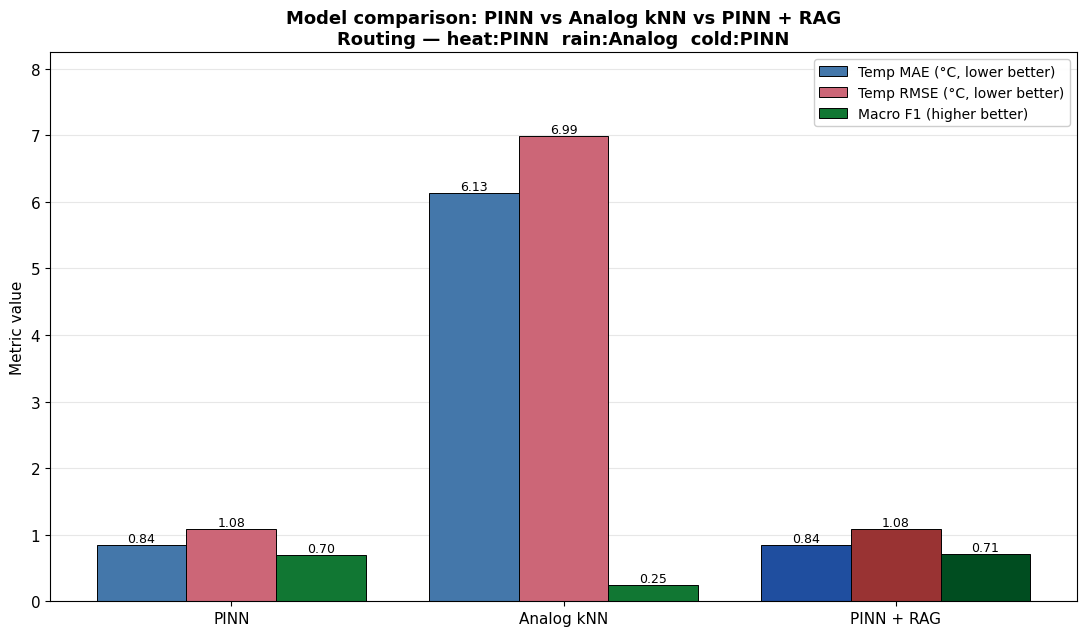

In [10]:


import os
import json
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from sklearn.metrics import mean_absolute_error, f1_score

OUTPUT_DIR = globals().get('OUTPUT_DIR', '/kaggle/working')
NPZ_PATH   = f'{OUTPUT_DIR}/analog_forecast_predictions.npz'
JSON_PATH  = f'{OUTPUT_DIR}/analog_forecast_trace_2025.json'


assert 'pe_all' in dir(), (
    "pe_all not in memory — run the 2025 evaluation cell first. "
    "pe_all is the (N, 3) array of PINN per-class probabilities."
)
assert 'thr' in dir(), "thr (per-class PINN thresholds) not in memory."

pe_all = np.asarray(pe_all, dtype=np.float32)
thr    = np.asarray(thr,    dtype=np.float32)
print(f"PINN classification head: pe_all shape={pe_all.shape}, "
      f"thresholds={thr.tolist()}")


assert os.path.exists(NPZ_PATH),  f"Missing {NPZ_PATH} — run the RAG cell first."
assert os.path.exists(JSON_PATH), f"Missing {JSON_PATH} — run the RAG cell first."

ana = np.load(NPZ_PATH)
with open(JSON_PATH) as f:
    trace = json.load(f)

pinn_temp   = ana['pinn_temp']
pinn_prcp   = ana['pinn_prcp']
analog_temp = ana['analog_temp']
analog_prcp = ana['analog_prcp']
truth_temp  = ana['truth_temp']
truth_prcp  = ana['truth_prcp']
truth_heat  = ana['truth_heat'].astype(int)
truth_rain  = ana['truth_rain'].astype(int)
truth_cold  = ana['truth_cold'].astype(int)

N = len(pinn_temp)
assert len(pe_all) == N, (
    f"pe_all has {len(pe_all)} rows but the eval set has {N}. "
    "Either the 2025 eval cell or the RAG cell was re-run with different N — "
    "re-run them both to align."
)

print(f"\nLoaded {N} samples. "
      f"PINN regression thresholds (used only for *analog* regression "
      f"comparison): heat>{thr[0]:.2f}, rain>{thr[1]:.2f}, cold<{-thr[2]:.2f}")

per_sample = trace['per_sample']
assert len(per_sample) == N
p_heat = np.array([float(s['analog']['p_heatwave'])   for s in per_sample], dtype=np.float32)
p_rain = np.array([float(s['analog']['p_heavy_rain']) for s in per_sample], dtype=np.float32)
p_cold = np.array([float(s['analog']['p_cold_wave'])  for s in per_sample], dtype=np.float32)

pinn_class_heat = (pe_all[:, 0] > thr[0]).astype(int)
pinn_class_rain = (pe_all[:, 1] > thr[1]).astype(int)
pinn_class_cold = (pe_all[:, 2] > thr[2]).astype(int)

pinn_f1_h = f1_score(truth_heat, pinn_class_heat, zero_division=0)
pinn_f1_r = f1_score(truth_rain, pinn_class_rain, zero_division=0)
pinn_f1_c = f1_score(truth_cold, pinn_class_cold, zero_division=0)
print(f"\nPINN classification (from trained head + tuned thresholds):")
print(f"  F1 heat = {pinn_f1_h:.3f}")
print(f"  F1 rain = {pinn_f1_r:.3f}")
print(f"  F1 cold = {pinn_f1_c:.3f}")
print(f"  F1 macro = {(pinn_f1_h + pinn_f1_r + pinn_f1_c)/3:.3f}")


def best_thr(probs, truth, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    best_t, best_f1 = 0.5, -1.0
    for t in grid:
        pred = (probs > t).astype(int)
        f1 = f1_score(truth, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t, best_f1

t_h, f1_h_a = best_thr(p_heat, truth_heat)
t_r, f1_r_a = best_thr(p_rain, truth_rain)
t_c, f1_c_a = best_thr(p_cold, truth_cold)
print(f"\nAnalog classification (tuned probability thresholds):")
print(f"  heat: thr={t_h:.2f}  F1={f1_h_a:.3f}")
print(f"  rain: thr={t_r:.2f}  F1={f1_r_a:.3f}")
print(f"  cold: thr={t_c:.2f}  F1={f1_c_a:.3f}")

anlg_class_heat = (p_heat > t_h).astype(int)
anlg_class_rain = (p_rain > t_r).astype(int)
anlg_class_cold = (p_cold > t_c).astype(int)

route_heat = 'PINN' if pinn_f1_h >= f1_h_a else 'Analog'
route_rain = 'PINN' if pinn_f1_r >= f1_r_a else 'Analog'
route_cold = 'PINN' if pinn_f1_c >= f1_c_a else 'Analog'

hyb_class_heat = pinn_class_heat if route_heat == 'PINN' else anlg_class_heat
hyb_class_rain = pinn_class_rain if route_rain == 'PINN' else anlg_class_rain
hyb_class_cold = pinn_class_cold if route_cold == 'PINN' else anlg_class_cold
hybrid_temp = pinn_temp.copy()
hybrid_prcp = pinn_prcp.copy()

def score_row(name, pt, pp, ch, cr, cc):
    pt = np.asarray(pt, dtype=np.float32); pp = np.asarray(pp, dtype=np.float32)
    mae_t  = mean_absolute_error(truth_temp, pt)
    rmse_t = sqrt(((truth_temp - pt) ** 2).mean())
    mae_p  = mean_absolute_error(truth_prcp, pp)
    f1_h   = f1_score(truth_heat, ch, zero_division=0)
    f1_r   = f1_score(truth_rain, cr, zero_division=0)
    f1_c   = f1_score(truth_cold, cc, zero_division=0)
    f1_m   = (f1_h + f1_r + f1_c) / 3
    print(f"{name:<18} {mae_t:>7.3f} {rmse_t:>7.3f} {mae_p:>7.3f} "
          f"{f1_h:>7.3f} {f1_r:>7.3f} {f1_c:>7.3f} {f1_m:>8.3f}")
    return mae_t, rmse_t, mae_p, f1_h, f1_r, f1_c, f1_m

print(f"\n{'─'*80}")
print(f"{'Model':<18} {'MAE-T':>7} {'RMSE-T':>7} {'MAE-P':>7} "
      f"{'F1heat':>7} {'F1rain':>7} {'F1cold':>7} {'F1macro':>8}")
print(f"{'─'*80}")
m_pinn = score_row('PINN',  pinn_temp, pinn_prcp,
                   pinn_class_heat, pinn_class_rain, pinn_class_cold)
m_anlg = score_row('Analog kNN', analog_temp, analog_prcp,
                   anlg_class_heat, anlg_class_rain, anlg_class_cold)
m_hyb  = score_row('PINN + RAG', hybrid_temp, hybrid_prcp,
                   hyb_class_heat, hyb_class_rain, hyb_class_cold)
print(f"{'─'*80}")
print(f"Routing (best-F1-per-class): heat→{route_heat}  rain→{route_rain}  cold→{route_cold}")
gain = m_hyb[6] - m_pinn[6]
print(f"\nHybrid F1 macro gain over PINN: {gain:+.3f}  ({gain/m_pinn[6]*100:+.1f}%)")


np.savez(
    NPZ_PATH,
    eval_idx    = ana['eval_idx'],
    pinn_temp   = pinn_temp,
    pinn_prcp   = pinn_prcp,
    analog_temp = analog_temp,
    analog_prcp = analog_prcp,
    hybrid_temp = hybrid_temp,
    hybrid_prcp = hybrid_prcp,
    truth_temp  = truth_temp,
    truth_prcp  = truth_prcp,
    truth_heat  = truth_heat,
    truth_rain  = truth_rain,
    truth_cold  = truth_cold,
    thr_kernel  = thr,
    pe_all          = pe_all,
    pinn_class_heat = pinn_class_heat,
    pinn_class_rain = pinn_class_rain,
    pinn_class_cold = pinn_class_cold,
    anlg_class_heat = anlg_class_heat,
    anlg_class_rain = anlg_class_rain,
    anlg_class_cold = anlg_class_cold,
    hyb_class_heat  = hyb_class_heat,
    hyb_class_rain  = hyb_class_rain,
    hyb_class_cold  = hyb_class_cold,
    p_heat = p_heat, p_rain = p_rain, p_cold = p_cold,
    thr_p_heat = np.float32(t_h),
    thr_p_rain = np.float32(t_r),
    thr_p_cold = np.float32(t_c),
)
print(f"Saved: {NPZ_PATH}")


plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'legend.fontsize': 10})
fig, ax = plt.subplots(figsize=(11, 6.5))

names = ['PINN', 'Analog kNN', 'PINN + RAG']
mae_vals  = [m_pinn[0], m_anlg[0], m_hyb[0]]
rmse_vals = [m_pinn[1], m_anlg[1], m_hyb[1]]
f1_vals   = [m_pinn[6], m_anlg[6], m_hyb[6]]

x = np.arange(len(names)); w = 0.27
c_mae  = ['#4477aa', '#4477aa', '#1f4e9f']
c_rmse = ['#cc6677', '#cc6677', '#993333']
c_f1   = ['#117733', '#117733', '#004d20']

b1 = ax.bar(x - w, mae_vals,  width=w, label='Temp MAE (°C, lower better)',
            color=c_mae,  edgecolor='black', linewidth=0.7)
b2 = ax.bar(x,     rmse_vals, width=w, label='Temp RMSE (°C, lower better)',
            color=c_rmse, edgecolor='black', linewidth=0.7)
b3 = ax.bar(x + w, f1_vals,   width=w, label='Macro F1 (higher better)',
            color=c_f1,   edgecolor='black', linewidth=0.7)

for bars in (b1, b2, b3):
    for r in bars:
        h = r.get_height()
        ax.annotate(f'{h:.2f}',
                    (r.get_x() + r.get_width()/2, h),
                    ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Metric value')
ax.set_title("Model comparison: PINN vs Analog kNN vs PINN + RAG\n"
             f"Routing — heat:{route_heat}  rain:{route_rain}  cold:{route_cold}",
             fontweight='bold')
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
ax.legend(loc='upper right', framealpha=0.95)
ymax = max(max(mae_vals), max(rmse_vals), max(f1_vals)) * 1.18
ax.set_ylim(0, ymax)

fig.tight_layout()
out_path = f'{OUTPUT_DIR}/model_comparison_v2.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"\nSaved: {out_path}")
plt.show()